# 02 - Exploratory Data Analysis

This notebook explores the Spotify chart dataset from the perspective of cross-border music diffusion. The downstream modeling objective is to predict which additional countries a song is likely to enter within 60 days of its first chart appearance, and to rank the most likely target markets. The notebook is organized to support three goals: understand the structure and quality of the data, identify patterns in how songs spread across countries, and validate which features carry signal for the prediction task.

**Dataset:** Spotify Daily Top 200 and Viral 50 charts across 62 countries (excluding Global and 7 low-coverage markets), recorded daily from January 2017 to December 2021. Approximately 26 million rows, each representing one song's chart entry in one country on one date.

**Modeling target:** For each song × target country pair, predict whether the song will enter that country's Top 200 chart within 60 days of its first global chart appearance. The binary label (`did_enter_within_60d`) is used both for classification evaluation and as the basis for a ranking model (XGBRanker) that surfaces the top 5 most likely target countries per song.

**Training dataset structure:** Each row in the modeling dataset represents one (track, target_country) pair at the song's first chart date (day 0). Instead of defining a single "origin country," the dataset encodes the song's full spatial footprint as 62 per-country rank columns — preserving where and how well the song is performing at observation time. Target-specific features (cultural distance, language match, artist prior success in that country) vary per row, while track-level features (audio characteristics, artist profile) remain constant across all target rows for the same song.

**Observation point:** For this first iteration, we use a single observation point per song — day 0 (the song's first global chart appearance).

**Technical note:** The dataset contains over 26 million rows and cannot be loaded into pandas memory. All analytical queries are executed through DuckDB, an in-process SQL engine that reads directly from partitioned Parquet files. Intermediate results are materialized as DuckDB views rather than pandas DataFrames wherever possible.

## Executive Summary

This notebook explores five years of Spotify daily chart data across 69 country-level markets (plus a Global aggregate) to understand how songs spread across borders and which features predict cross-border diffusion. After excluding 7 markets with >50% missing daily coverage, the downstream modeling dataset covers 62 countries. The core finding is that cross-border spread is rare (occurring for ~10–18% of songs depending on subgroup) but highly predictable from a small set of signals available at day 0 — the song's first global chart appearance.

The strongest predictors identified are debut spatial footprint (number and rank of countries charting at day 0), artist catalogue depth, and Viral 50 co-appearance (about a 1.8x spread rate difference when measured using day-0 information only). Audio features, cultural distance, language similarity, and continent proximity carry weak individual signal at the song level but are retained as supporting features for the pair-level modeling dataset.

The notebook is structured to move from data quality (Parts I–II), through diffusion mechanics (Part III), feature exploration (Parts IV–V), and correlation analysis (Part VI), concluding with modeling implications (Part VII).


# Table of Contents

## [Part 0 — Setup and Data Loading](#part-0--setup-and-data-loading)
- [0.1 Environment Setup and Dependencies](#01-environment-setup-and-dependencies)
- [0.2 Data Access via DuckDB](#02-data-access-via-duckdb)
- [0.3 Dataset Overview and Table Structure](#03-dataset-overview-and-table-structure)
- [0.4 Initial Dataset Dimensions and Coverage](#04-initial-dataset-dimensions-and-coverage)

## [Part I — Data Quality and Cleaning](#part-i--data-quality-and-cleaning)
- [1.1 Schema and Variable Types](#11-schema-and-variable-types)
- [1.2 Missing Values and Data Completeness](#12-missing-values-and-data-completeness)
- [1.3 Duplicate Records and Consistency Checks](#13-duplicate-records-and-consistency-checks)
- [1.4 Data Type Corrections and Parsing](#14-data-type-corrections-and-parsing)
- [1.5 Summary of Cleaning Decisions](#15-summary-of-cleaning-decisions)

## [Part II — Overview of Global Chart Dynamics](#part-ii--overview-of-global-chart-dynamics)
- [2.1 Distribution of Chart Entries Across Countries](#21-distribution-of-chart-entries-across-countries)
- [2.2 Total Countries Reached per Song](#22-total-countries-reached-per-song)
- [2.3 First Chart Appearance: Where Songs Start](#23-first-chart-appearance-where-songs-start)
- [2.4 Multi-Country Debuts vs Single-Country Debuts](#24-multi-country-debuts-vs-single-country-debuts)
- [2.5 Implications for Modeling and Business Perspective](#25-implications-for-modeling-and-business-perspective)

## [Part III — Diffusion of Songs Across Countries](#part-iii--diffusion-of-songs-across-countries)
- [3.1 Time Until Entry in Additional Countries](#31-time-until-entry-in-additional-countries)
- [3.2 Distribution of Cross-Border Spread Within 60 Days](#32-distribution-of-cross-border-spread-within-60-days)
- [3.3 Countries That Tend to Lead vs Follow](#33-countries-that-tend-to-lead-vs-follow)
- [3.4 Most Common Origin-to-Target Country Flows](#34-most-common-origin-to-target-country-flows)
- [3.5 Implications for Modeling and Business Perspective](#35-implications-for-modeling-and-business-perspective)

## [Part IV — Distribution of Feature Groups](#part-iv--distribution-of-feature-groups)
- [4.1 Distribution of Initial Chart Ranks](#41-distribution-of-initial-chart-ranks)
- [4.2 Distribution of Audio Features](#42-distribution-of-audio-features)
- [4.3 Artist Prior Chart Success](#43-artist-prior-chart-success)
- [4.4 Collaboration, Explicit Content, and Release Timing](#44-collaboration-explicit-content-and-release-timing)
- [4.5 Cultural Distance](#45-cultural-distance)
- [4.6 Language Similarity](#46-language-similarity)
- [4.7 Implications for Modeling and Business Perspective](#47-implications-for-modeling-and-business-perspective)

## [Part V — Bivariate Analysis: Features vs 60-Day Spread](#part-v--bivariate-analysis-features-vs-60-day-spread)
- [5.1 Initial Rank vs 60-Day Spread](#51-initial-rank-vs-60-day-spread)
- [5.2 Multi-Country Launch Patterns vs 60-Day Spread](#52-multi-country-launch-patterns-vs-60-day-spread)
- [5.3 Audio Features vs 60-Day Spread](#53-audio-features-vs-60-day-spread)
- [5.4 Artist Prior Reach vs 60-Day Spread](#54-artist-prior-reach-vs-60-day-spread)
- [5.5 Collaboration, Explicit Content, and Release Timing vs 60-Day Spread](#55-collaboration-explicit-content-and-release-timing-vs-60-day-spread)
- [5.6 Cultural Distance vs 60-Day Spread](#56-cultural-distance-vs-60-day-spread)
- [5.7 Same Continent vs 60-Day Spread](#57-same-continent-vs-60-day-spread)
- [5.8 Language Match vs 60-Day Spread](#58-language-match-vs-60-day-spread)
- [5.9 Viral 50 Presence vs 60-Day Spread](#59-viral-50-presence-vs-60-day-spread)
- [5.10 Implications for Modeling and Business Perspective](#510-implications-for-modeling-and-business-perspective)

## [Part VI — Correlation and Multicollinearity](#part-vi--correlation-and-multicollinearity)
- [6.1 Correlation Matrix — Audio Features](#61-correlation-matrix--audio-features)
- [6.2 Point-Biserial Correlation with 60-Day Spread Target](#62-point-biserial-correlation-with-60-day-spread-target)
- [6.3 VIF Analysis](#63-vif-analysis)

## [Part VII — Key Insights and Implications for Modeling](#part-vii--key-insights-and-implications-for-modeling)
- [7.1 Summary of Key Findings](#71-summary-of-key-findings)
- [7.2 Features Likely to Influence Cross-Border Diffusion](#72-features-likely-to-influence-cross-border-diffusion)
- [7.3 Limitations and Potential Sources of Bias](#73-limitations-and-potential-sources-of-bias)
- [7.4 Implications for the Modeling Approach](#74-implications-for-the-modeling-approach)

# Part 0 - Setup and Data Loading

This section initializes the Python environment, establishes file paths, connects to the cloud storage backend, and registers the full raw Spotify chart dataset as a DuckDB view. This notebook is pinned to `datasets/v1` so that the exploratory analysis always starts from the pre-cleaning source data rather than any downstream cleaned version. DuckDB reads the partitioned Parquet files directly from disk, avoiding memory constraints while keeping the raw dataset available for query-driven analysis. Once this section completes, the `spotify_full` view is available for all subsequent analyses. Throughout this document, we create additional views derived from the raw source, including `spotify_clean` and `local_top200`.


## 0.1 Environment Setup and Dependencies

In [1]:
# Import necessary libraries

from pathlib import Path
import os
import re
import json
import textwrap
import subprocess
from typing import Dict, List, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")


In [2]:
# Defining a helper function to execute SQL queries and return results as a DataFrame

def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).df()

# Reusable plotting helpers

def plot_bar(df, x, y, title, xlabel, ylabel, top_n=None, rotation=45, color="#4C72B0"):
    if top_n:
        df = df.head(top_n)
    fig, ax = plt.subplots()
    ax.bar(df[x].astype(str), df[y], color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_hist(series, bins, title, xlabel, color="#4C72B0"):
    fig, ax = plt.subplots()
    ax.hist(series.dropna(), bins=bins, color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()


def plot_line(df, x, y, title, xlabel, ylabel, color="#4C72B0"):
    fig, ax = plt.subplots()
    ax.plot(df[x], df[y], marker="o", color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

## 0.2 Data Access via DuckDB

The dataset is accessed through DuckDB, an in-process SQL engine that queries Parquet files directly without loading them into memory. Credentials for the Cloudflare R2 storage backend are parsed from `scripts/r2.env`, validated, and passed to a shell download script that fetches the partitioned Parquet files into the local `datasets/` directory. The download step is disabled by default (`RUN_DOWNLOAD = False`) and only needs to run once during initial setup. For reproducibility, this EDA notebook is pinned to the raw `v1` dataset even if other project workflows use newer dataset folders.


In [3]:
# Define paths and constants

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "Project_Information":
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "scripts").exists() and (candidate / "datasets").exists():
            NOTEBOOK_DIR = candidate / "Project_Information" if (candidate / "Project_Information").exists() else candidate
            break

REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "Project_Information" else NOTEBOOK_DIR
SCRIPTS_DIR = REPO_ROOT / "scripts"
DEFAULT_DATASET_VERSION = "v1"
DEFAULT_DOWNLOAD_ROOT = REPO_ROOT / "datasets" / DEFAULT_DATASET_VERSION
R2_ENV_PATH = SCRIPTS_DIR / "r2.env"
R2_ENV_EXAMPLE_PATH = SCRIPTS_DIR / "r2.env.example"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs" / "team_eda_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Scripts dir: {SCRIPTS_DIR}")
print(f"Default download root: {DEFAULT_DOWNLOAD_ROOT}")
print(f"R2 env file: {R2_ENV_PATH}")
print(f"Output dir: {OUTPUT_DIR}")


Repo root: /Users/michaelkania/Library/Mobile Documents/com~apple~CloudDocs/01_University/01_Master/01_Courses/03_T3/04_Machine Learning/01_Group Project/ML_Group_AB
Scripts dir: /Users/michaelkania/Library/Mobile Documents/com~apple~CloudDocs/01_University/01_Master/01_Courses/03_T3/04_Machine Learning/01_Group Project/ML_Group_AB/scripts
Default download root: /Users/michaelkania/Library/Mobile Documents/com~apple~CloudDocs/01_University/01_Master/01_Courses/03_T3/04_Machine Learning/01_Group Project/ML_Group_AB/datasets/v1
R2 env file: /Users/michaelkania/Library/Mobile Documents/com~apple~CloudDocs/01_University/01_Master/01_Courses/03_T3/04_Machine Learning/01_Group Project/ML_Group_AB/scripts/r2.env
Output dir: /Users/michaelkania/Library/Mobile Documents/com~apple~CloudDocs/01_University/01_Master/01_Courses/03_T3/04_Machine Learning/01_Group Project/ML_Group_AB/outputs/team_eda_baseline


In [4]:
# Required keys for R2 configuration

REQUIRED_R2_KEYS = [
    "R2_ENDPOINT",
    "R2_BUCKET",
    "AWS_ACCESS_KEY_ID",
    "AWS_SECRET_ACCESS_KEY",
    "DATASET_VERSION",
]


def _strip_balanced_quotes(value: str) -> str:
    if len(value) >= 2 and ((value[0] == '"' and value[-1] == '"') or (value[0] == "'" and value[-1] == "'")):
        return value[1:-1]
    return value


def parse_env_file(env_path: Path) -> Tuple[Dict[str, str], List[str]]:
    parsed: Dict[str, str] = {}
    errors: List[str] = []

    if not env_path.exists():
        errors.append(f"Missing env file: {env_path}")
        return parsed, errors

    for line_no, raw_line in enumerate(env_path.read_text(encoding="utf-8").splitlines(), start=1):
        line = raw_line.strip()
        if not line or line.startswith("#"):
            continue
        if "=" not in line:
            errors.append(f"Line {line_no}: missing '=' separator")
            continue

        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip()

        if not re.fullmatch(r"[A-Za-z_][A-Za-z0-9_]*", key):
            errors.append(f"Line {line_no}: invalid key '{key}'")
            continue

        dbl_quote_count = value.count('"')
        sgl_quote_count = value.count("'")
        if dbl_quote_count % 2 != 0 or sgl_quote_count % 2 != 0:
            errors.append(
                f"Line {line_no}: malformed quotes for key '{key}' -> {value!r}"
            )
            continue

        normalized = _strip_balanced_quotes(value).strip()

        if normalized.endswith('"') or normalized.endswith("'"):
            errors.append(
                f"Line {line_no}: value for '{key}' appears to have a trailing quote -> {value!r}"
            )

        parsed[key] = normalized

    missing = [k for k in REQUIRED_R2_KEYS if not parsed.get(k)]
    if missing:
        errors.append(f"Missing required keys: {missing}")

    return parsed, errors


r2_config, r2_config_errors = parse_env_file(R2_ENV_PATH)

if r2_config_errors:
    print("r2.env validation failed:")
    for err in r2_config_errors:
        print(f"  - {err}")
    if R2_ENV_EXAMPLE_PATH.exists():
        print(f"\nTemplate available at: {R2_ENV_EXAMPLE_PATH}")
else:
    print("r2.env validation passed")
    display(pd.DataFrame([r2_config]).T.rename(columns={0: "value"}))

r2.env validation passed


,value
R2_ENDPOINT,https://a96b93c5d97cddb48fc674255fb687c7.r2.cl...
R2_BUCKET,ml-group-ab-datasets
AWS_ACCESS_KEY_ID,fa162d7d8a7a374608e16c3858dfb6f6
AWS_SECRET_ACCESS_KEY,c810c10fdc699b06aa6d561f1d052387ec79771ea972db...
DATASET_VERSION,v2


In [5]:
# Build sanitized environment for subprocess execution

def build_sanitized_env(base_env: Dict[str, str], overrides: Dict[str, str] | None = None) -> Dict[str, str]:
    if r2_config_errors:
        raise ValueError("Cannot build environment: r2.env is invalid.")

    env = dict(os.environ)
    for key in REQUIRED_R2_KEYS:
        env[key] = str(base_env[key]).strip()

    if overrides:
        for k, v in overrides.items():
            if v is not None:
                env[k] = str(v)

    return env


def run_bash_script(script_path: Path, env: Dict[str, str], cwd: Path, timeout: int = 3600) -> subprocess.CompletedProcess:
    if not script_path.exists():
        raise FileNotFoundError(f"Missing script: {script_path}")

    cmd = ["bash", str(script_path)]
    result = subprocess.run(
        cmd,
        cwd=str(cwd),
        env=env,
        capture_output=True,
        text=True,
        timeout=timeout,
    )

    print("--- stdout ---")
    print(result.stdout[-4000:] if result.stdout else "<empty>")
    print("--- stderr ---")
    print(result.stderr[-4000:] if result.stderr else "<empty>")
    print(f"Exit code: {result.returncode}")

    if result.returncode != 0:
        raise RuntimeError(
            "Download script failed. Check stdout/stderr above. "
            "For permission-related preflight errors, try SKIP_R2_PREFLIGHT=1."
        )

    return result

print("Shell helper ready")

Shell helper ready


In [6]:
# Pin the EDA notebook to the raw dataset version

DOWNLOAD_SCRIPT = SCRIPTS_DIR / "download_from_r2.sh"
EDA_DATASET_VERSION = "v1"
DOWNLOAD_ROOT = REPO_ROOT / "datasets" / EDA_DATASET_VERSION

RUN_DOWNLOAD = False  # modify to True to refresh the raw dataset locally

print(f"Configured EDA dataset version: {EDA_DATASET_VERSION}")
print(f"Active DOWNLOAD_ROOT: {DOWNLOAD_ROOT}")
print("Note: r2.env DATASET_VERSION is ignored in this notebook to keep EDA on raw v1.")

if RUN_DOWNLOAD:
    env_default = build_sanitized_env(
        r2_config,
        overrides={
            "DATASET_VERSION": EDA_DATASET_VERSION,
            "DOWNLOAD_ROOT": str(DOWNLOAD_ROOT),
        },
    )
    run_bash_script(DOWNLOAD_SCRIPT, env=env_default, cwd=REPO_ROOT)
else:
    print("Skipped default run. Set RUN_DOWNLOAD=True to execute.")


Configured EDA dataset version: v1
Active DOWNLOAD_ROOT: /Users/michaelkania/Library/Mobile Documents/com~apple~CloudDocs/01_University/01_Master/01_Courses/03_T3/04_Machine Learning/01_Group Project/ML_Group_AB/datasets/v1
Note: r2.env DATASET_VERSION is ignored in this notebook to keep EDA on raw v1.
Skipped default run. Set RUN_DOWNLOAD=True to execute.


In [7]:
# Validate dataset presence, prepare DuckDB connection and register the raw dataset

DOWNLOAD_ROOT = REPO_ROOT / "datasets" / "v1"
active_download_root = DOWNLOAD_ROOT
full_root = active_download_root / "full"
if not full_root.exists():
    raise FileNotFoundError(f"Full dataset folder not found: {full_root}")

parquet_files = sorted(full_root.rglob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found under: {full_root}")

print(f"Active download root: {active_download_root}")
print(f"Total parquet files in full dataset: {len(parquet_files)}")

try:
    import duckdb
except ImportError as exc:
    raise ImportError(
        "duckdb is required for SQL-based EDA. Install it with: pip install duckdb"
    ) from exc

con = duckdb.connect(database=":memory:")
parquet_glob = (full_root / "year=*" / "*.parquet").as_posix()

con.execute(
    f"""
    CREATE OR REPLACE VIEW spotify_full AS
    SELECT *
    FROM read_parquet('{parquet_glob}', hive_partitioning = true);
    """
)


Active download root: /Users/michaelkania/Library/Mobile Documents/com~apple~CloudDocs/01_University/01_Master/01_Courses/03_T3/04_Machine Learning/01_Group Project/ML_Group_AB/datasets/v1
Total parquet files in full dataset: 24


## 0.3 Dataset Overview and Table Structure

In [8]:
# List available tables

available_objects = q("""
SELECT 
    table_schema,
    table_name,
    table_type
FROM information_schema.tables
WHERE table_schema NOT IN ('information_schema', 'pg_catalog')
ORDER BY table_schema, table_name
""")

available_objects


,table_schema,table_name,table_type
0,main,spotify_full,VIEW


In [9]:
# Set the name of the main table or view used throughout the notebook

MAIN_TABLE = "spotify_full"

In [10]:
# Inspect the schema of the main table

schema_df = q(f"""
DESCRIBE {MAIN_TABLE}
""")

schema_df


,column_name,column_type,null,key,default,extra
0,title,VARCHAR,YES,None,None,None
1,rank,VARCHAR,YES,None,None,None
2,date,VARCHAR,YES,None,None,None
3,artist,VARCHAR,YES,None,None,None
4,url,VARCHAR,YES,None,None,None
5,region,VARCHAR,YES,None,None,None
6,chart,VARCHAR,YES,None,None,None
7,trend,VARCHAR,YES,None,None,None
8,streams,VARCHAR,YES,None,None,None
9,track_id,VARCHAR,YES,None,None,None


In [11]:
# Display a small sample of rows

sample_df = q(f"""
SELECT *
FROM {MAIN_TABLE}
LIMIT 10
""")

sample_df


,title,rank,date,artist,url,region,chart,trend,streams,track_id,...,country_major_religions,country_govt_type,country_driving_side,cultural_distance_mean,cultural_distance_median,cultural_distance_min,cultural_distance_max,cultural_distance_count,cultural_top5_targets,index
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,253019.0,6mICuAdrwEjh6Y6lroV2Kg,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
1,Vente Pa' Ca (feat. Maluma),2,2017-01-01,Ricky Martin,https://open.spotify.com/track/7DM4BPaS7uofFul...,Argentina,top200,MOVE_UP,223988.0,7DM4BPaS7uofFul3ywMe46,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
2,Reggaetón Lento (Bailemos),3,2017-01-01,CNCO,https://open.spotify.com/track/3AEZUABDXNtecAO...,Argentina,top200,MOVE_DOWN,210943.0,3AEZUABDXNtecAOSC1qTfo,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
3,Safari,4,2017-01-01,"J Balvin, Pharrell Williams, BIA, Sky",https://open.spotify.com/track/6rQSrBHf7HlZjtc...,Argentina,top200,SAME_POSITION,173865.0,6rQSrBHf7HlZjtcMZ4S4bO,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
4,Shaky Shaky,5,2017-01-01,Daddy Yankee,https://open.spotify.com/track/58IL315gMSTD37D...,Argentina,top200,MOVE_UP,153956.0,58IL315gMSTD37DOZPJ2hf,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
5,Traicionera,6,2017-01-01,Sebastian Yatra,https://open.spotify.com/track/5J1c3M4EldCfNxX...,Argentina,top200,MOVE_DOWN,151140.0,5J1c3M4EldCfNxXwrwt8mT,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
6,Cuando Se Pone a Bailar,7,2017-01-01,Rombai,https://open.spotify.com/track/1MpKZi1zTXpERKw...,Argentina,top200,MOVE_DOWN,148369.0,1MpKZi1zTXpERKwxmOu1PH,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
7,Otra vez (feat. J Balvin),8,2017-01-01,Zion & Lennox,https://open.spotify.com/track/3QwBODjSEzelZyV...,Argentina,top200,MOVE_DOWN,143004.0,3QwBODjSEzelZyVjxPOHdq,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
8,La Bicicleta,9,2017-01-01,"Carlos Vives, Shakira",https://open.spotify.com/track/0sXvAOmXgjR2QUq...,Argentina,top200,MOVE_UP,126389.0,0sXvAOmXgjR2QUqLK1MltU,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0
9,Dile Que Tu Me Quieres,10,2017-01-01,Ozuna,https://open.spotify.com/track/20ZAJdsKB5IGbGj...,Argentina,top200,MOVE_DOWN,112012.0,20ZAJdsKB5IGbGj4ilRt2o,...,Christianity,Republic,right,1.279542,1.1075,0.154,4.031,118,Malta|Greece|Italy|Luxembourg|Czech republic,3.0


**Findings**

The dataset `spotify_full` contains 26,174,269 observations and 46 variables, indicating a large-scale panel dataset covering daily chart observations across multiple countries.

From the schema inspection, most variables are stored as VARCHAR (37 columns), while numeric variables are limited (6 DOUBLE and 3 BIGINT columns). This suggests that several variables that conceptually represent numeric or temporal information (e.g., dates or categorical identifiers) are currently stored as strings and may require type conversion during the data cleaning phase.

The dataset includes several groups of variables:
- **Track metadata**: title, artist, album, release_date, explicit, duration_ms  
- **Chart information**: rank, streams, region, trend, date  
- **Audio features**: danceability, energy, valence, tempo, acousticness, speechiness, instrumentalness, liveness  
- **Country-level attributes**: continent, population, official language, driving side  
- **Cultural similarity metrics**: multiple cultural distance measures between countries  
- **Temporal variables**: observation_date, year_month, year  

Overall, the dataset appears to combine song-level characteristics, chart performance, and country-level contextual features, which provides a rich foundation for analyzing how songs spread across markets and for constructing the cross-border diffusion prediction dataset used later in the project.



## 0.4 Initial Dataset Dimensions and Coverage

In [12]:
# Dataset size

dataset_size_df = q(f"""
SELECT 
    COUNT(*) AS n_rows
FROM {MAIN_TABLE}
""")

dataset_size_df


,n_rows
0,26174269


In [13]:
# Number of columns

n_cols_df = q(f"""
SELECT COUNT(*) AS n_columns
FROM information_schema.columns
WHERE table_name = '{MAIN_TABLE}'
""")

n_cols_df


,n_columns
0,46


In [14]:
# Temporal coverage

date_coverage_df = q(f"""
SELECT
    MIN(TRY_CAST(date AS DATE)) AS min_date,
    MAX(TRY_CAST(date AS DATE)) AS max_date,
    COUNT(DISTINCT TRY_CAST(date AS DATE)) AS n_unique_dates
FROM {MAIN_TABLE}
""")

date_coverage_df


,min_date,max_date,n_unique_dates
0,2017-01-01,2021-12-31,1826


In [15]:
# Geographic coverage and unique tracks

coverage_df = q(f"""
SELECT
    COUNT(DISTINCT region) AS n_regions,
    COUNT(DISTINCT track_id) AS n_tracks
FROM {MAIN_TABLE}
""")

coverage_df


,n_regions,n_tracks
0,70,198077


In [16]:
# Observations by year

obs_by_year_df = q(f"""
WITH base AS (
    SELECT
        COALESCE(
            TRY_CAST(year AS INTEGER),
            EXTRACT(YEAR FROM TRY_CAST(date AS DATE))::INTEGER
        ) AS year_val
    FROM {MAIN_TABLE}
)
SELECT
    year_val AS year,
    COUNT(*) AS observations
FROM base
WHERE year_val IS NOT NULL
GROUP BY 1
ORDER BY 1
""")

obs_by_year_df


,year,observations
0,2017,4401837
1,2018,4863055
2,2019,5412686
3,2020,5793155
4,2021,5703536


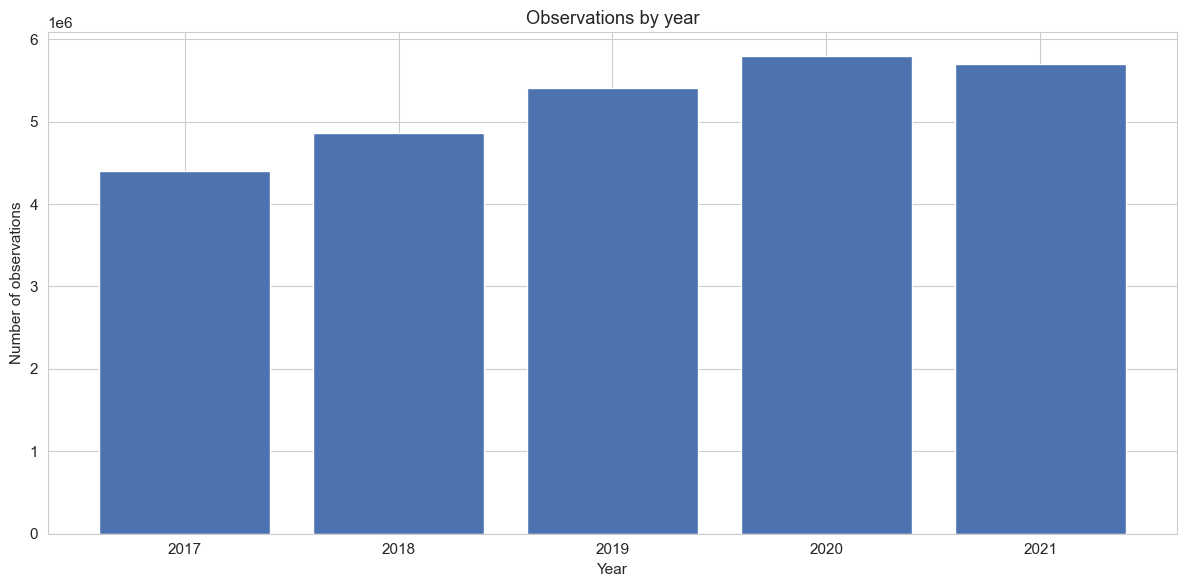

In [17]:
plot_bar(
    obs_by_year_df,
    x="year",
    y="observations",
    title="Observations by year",
    xlabel="Year",
    ylabel="Number of observations",
    rotation=0
)


In [18]:
# Observations by region

obs_by_region_df = q(f"""
SELECT
    region,
    COUNT(*) AS observations
FROM {MAIN_TABLE}
GROUP BY 1
ORDER BY observations DESC
""")

obs_by_region_df.head(15)


,region,observations
0,Argentina,455311
1,United States,455085
2,Austria,454596
3,Brazil,454441
4,Australia,453117
5,Canada,452296
6,Global,451804
7,United Kingdom,450732
8,Switzerland,449658
9,Malaysia,449354


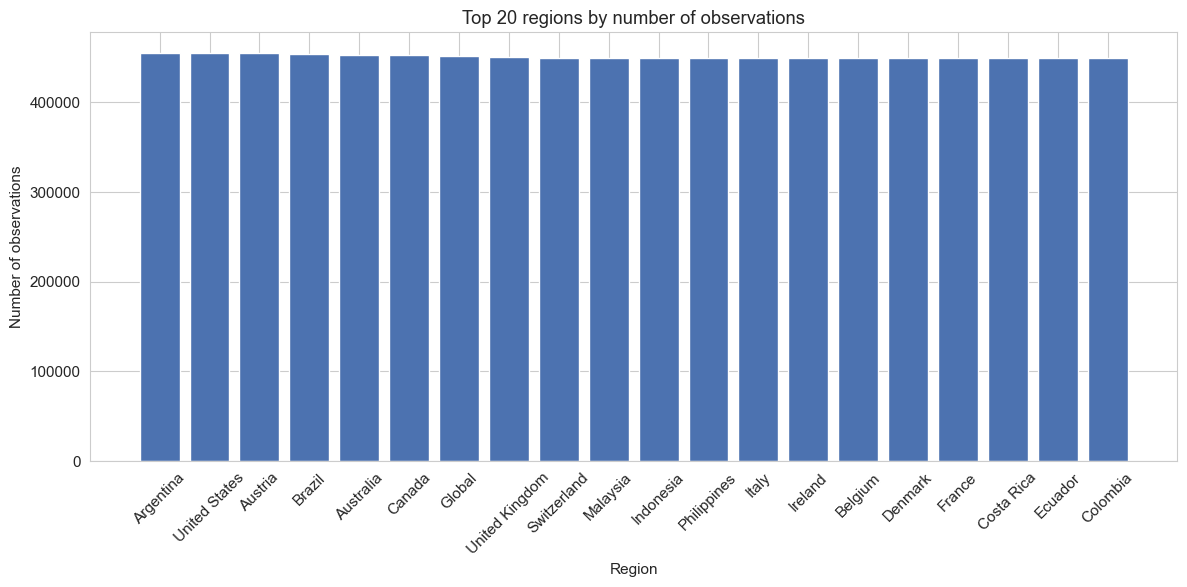

In [19]:
plot_bar(
    obs_by_region_df,
    x="region",
    y="observations",
    title="Top 20 regions by number of observations",
    xlabel="Region",
    ylabel="Number of observations",
    top_n=20
)


In [20]:
# Unique tracks by region

tracks_by_region_df = q(f"""
SELECT
    region,
    COUNT(DISTINCT track_id) AS unique_tracks
FROM {MAIN_TABLE}
GROUP BY 1
ORDER BY unique_tracks DESC
""")

tracks_by_region_df.head(15)


,region,unique_tracks
0,Switzerland,16608
1,Germany,14698
2,Finland,14645
3,Netherlands,14398
4,France,13960
5,Sweden,13798
6,Austria,13784
7,United States,13754
8,Taiwan,13745
9,Belgium,13302


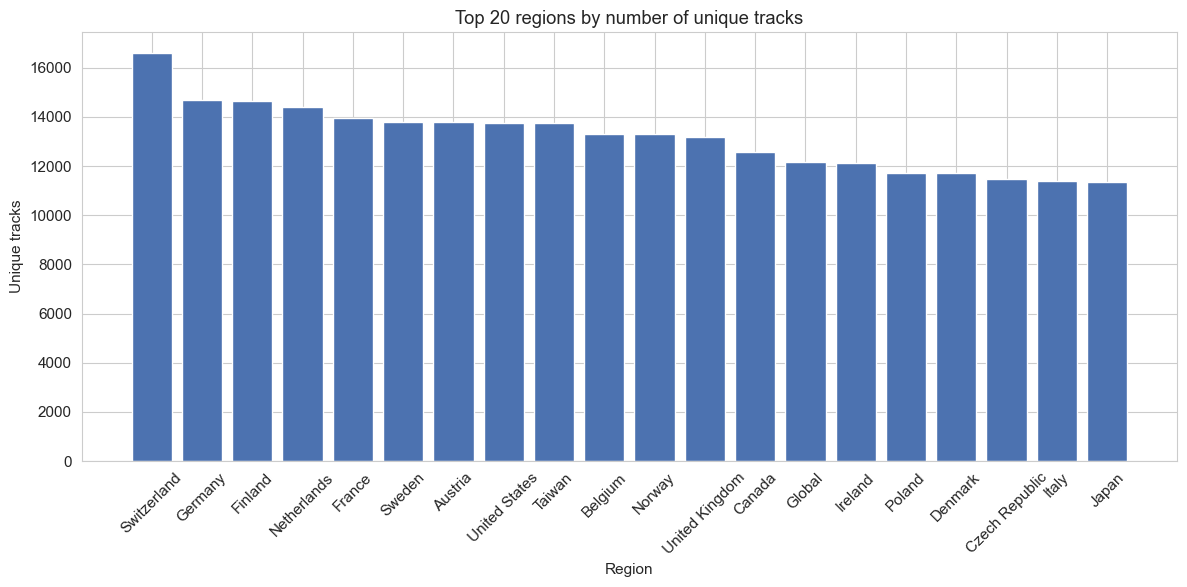

In [21]:
plot_bar(
    tracks_by_region_df,
    x="region",
    y="unique_tracks",
    title="Top 20 regions by number of unique tracks",
    xlabel="Region",
    ylabel="Unique tracks",
    top_n=20
)


In [22]:
# Chart composition

chart_mix_df = q(f"""
SELECT
    chart,
    COUNT(*) AS row_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_rows
FROM {MAIN_TABLE}
GROUP BY 1
ORDER BY row_count DESC
""")

chart_mix_df


,chart,row_count,pct_rows
0,top200,20321961,77.64
1,viral50,5852308,22.36


In [23]:
# Global vs local share

global_share_df = q(f"""
SELECT
    CASE WHEN LOWER(region) = 'global' THEN 'global' ELSE 'local' END AS scope,
    COUNT(*) AS row_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_rows
FROM {MAIN_TABLE}
GROUP BY 1
ORDER BY row_count DESC
""")

global_share_df


,scope,row_count,pct_rows
0,local,25722465,98.27
1,global,451804,1.73


In [24]:
# Chart composition by year

chart_mix_by_year_df = q(f"""
WITH base AS (
    SELECT
        COALESCE(
            TRY_CAST(year AS INTEGER),
            EXTRACT(YEAR FROM TRY_CAST(date AS DATE))::INTEGER
        ) AS year_val,
        chart
    FROM {MAIN_TABLE}
)
SELECT
    year_val AS year,
    chart,
    COUNT(*) AS row_count
FROM base
WHERE year_val IS NOT NULL
GROUP BY 1, 2
ORDER BY 1, 2
""")

chart_mix_by_year_df.head()


,year,chart,row_count
0,2017,top200,3386564
1,2017,viral50,1015273
2,2018,top200,3739327
3,2018,viral50,1123728
4,2019,top200,4210217


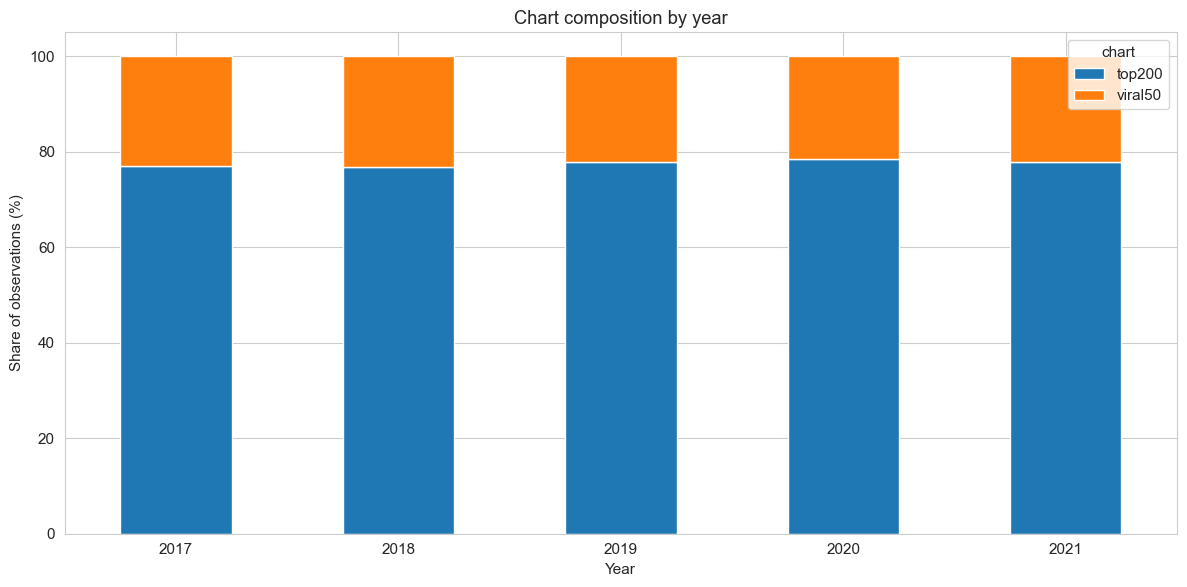

In [25]:
chart_mix_year_pivot = (
    chart_mix_by_year_df
    .pivot(index="year", columns="chart", values="row_count")
    .fillna(0)
    .sort_index()
)

chart_mix_year_share = chart_mix_year_pivot.div(chart_mix_year_pivot.sum(axis=1), axis=0) * 100

ax = chart_mix_year_share.plot(kind="bar", stacked=True)
ax.set_title("Chart composition by year")
ax.set_xlabel("Year")
ax.set_ylabel("Share of observations (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Findings**

- **Large-scale panel dataset**  
  The dataset contains 26,174,269 observations and 198,077 unique tracks, providing extensive daily chart coverage across countries and over time.

- **Broad temporal and geographic scope**  
  The data covers the period from 2017-01-01 to 2021-12-31 and includes 70 regions (69 country-level markets plus a Global aggregate), offering a strong basis for studying international diffusion patterns.

- **Coverage increases over time**  
  The number of observations rises from 4.4 million in 2017 to a peak of 5.8 million in 2020, before remaining at a similarly high level in 2021. This suggests broader or more complete chart coverage in later years.

- **Relatively balanced country coverage**  
  Most countries contribute a similar number of observations, generally around 360,000 rows, which indicates fairly consistent tracking across markets.

- **Substantial song variety in leading markets**  
  The most diverse markets — Switzerland, Germany, and Finland — each feature over 13,000 unique tracks, indicating that the dataset captures a wide range of songs beyond a narrow set of globally dominant titles.

- **Top 200 charts dominate the dataset**  
  Approximately 77.6 percent of all rows come from Top 200 charts, while 22.4 percent come from Viral 50 charts. This implies that the dataset is primarily driven by mainstream chart performance, with viral chart activity playing a smaller but still meaningful role.

- **The dataset is overwhelmingly local rather than global**  
  About 98.3 percent of observations come from local country-level charts, while only 1.7 percent come from the global chart. This is beneficial for the project, since the prediction task is centered on cross-country diffusion between national markets.

- **Chart composition is stable over time**  
  In every year, Top 200 observations substantially exceed Viral 50 observations, suggesting a relatively stable chart mix across the sample period.

# Part I — Data Quality and Cleaning

This section assesses the quality of the raw Spotify dataset before any analytical filtering is applied. The raw data (`spotify_full`) arrives as Parquet files with 46 columns stored almost entirely as VARCHAR — meaning numeric fields such as rank, streams, audio features, and dates require explicit type casting before they can be used in calculations. We inspect variable types, quantify missing values across feature groups, check for duplicate records, and document the type corrections applied to produce the cleaned `spotify_clean` view. The outcome of this section is a well-understood, consistently typed dataset ready for diffusion analysis in Part II onwards.

## 1.1 Schema and Variable Types

In [26]:
# Variable type distribution

dtype_summary_df = q(f"""
SELECT
    data_type,
    COUNT(*) AS n_columns
FROM information_schema.columns
WHERE table_name = '{MAIN_TABLE}'
GROUP BY 1
ORDER BY n_columns DESC, data_type
""")

dtype_summary_df


,data_type,n_columns
0,VARCHAR,37
1,DOUBLE,6
2,BIGINT,3


In [27]:
# List columns by type

cols_by_type_df = q(f"""
SELECT
    data_type,
    column_name
FROM information_schema.columns
WHERE table_name = '{MAIN_TABLE}'
ORDER BY data_type, column_name
""")

cols_by_type_df


,data_type,column_name
0,BIGINT,country_population
1,BIGINT,cultural_distance_count
2,BIGINT,year
3,DOUBLE,country_area
4,DOUBLE,cultural_distance_max
5,DOUBLE,cultural_distance_mean
6,DOUBLE,cultural_distance_median
7,DOUBLE,cultural_distance_min
8,DOUBLE,index
9,VARCHAR,af_acousticness


**Findings**

- **Predominantly string-typed schema**  
  Of the 46 columns in the raw dataset, 37 are stored as VARCHAR, 6 as DOUBLE, and 3 as BIGINT. This means that key numeric fields, including `rank`, `streams`, `duration_ms`, `explicit`, all 12 audio features, and all date columns, are stored as strings and require explicit casting before any quantitative analysis.

- **Type corrections are necessary before modeling**  
  Audio features such as `af_danceability` and `af_energy` arrive as VARCHAR despite containing continuous numeric values. Similarly, `rank` and `streams` are stored as strings. All of these are cast to their correct types in the `spotify_clean` view created in section 1.4.
- **Auxiliary columns require implicit casting in queries**  
  Country-level enrichment columns (`cultural_distance_mean`, `cultural_distance_min`, `country_population`, etc.) are also stored as VARCHAR in the raw dataset. DuckDB implicitly casts these to numeric types when used in aggregation functions (AVG, MIN, etc.), so queries in this notebook work correctly. Explicit type casting is applied in the cleaning notebook (`03_data_cleaning.ipynb`) for the exported v2 dataset.


## 1.2 Missing Values and Data Completeness

In [28]:
# Missing values by column
# This uses a dynamically generated SQL statement to count nulls and blank strings.

columns = q(f"""
SELECT column_name, data_type
FROM information_schema.columns
WHERE table_name = '{MAIN_TABLE}'
ORDER BY ordinal_position
""")

missing_exprs = []
for _, row in columns.iterrows():
    col = row["column_name"]
    dtype = row["data_type"]
    if dtype == "VARCHAR":
        expr = f"SUM(CASE WHEN {col} IS NULL OR TRIM({col}) = '' THEN 1 ELSE 0 END) AS {col}"
    else:
        expr = f"SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS {col}"
    missing_exprs.append(expr)

missing_sql = f"SELECT {', '.join(missing_exprs)} FROM {MAIN_TABLE}"
missing_wide = q(missing_sql)

missing_df = (
    missing_wide.T
    .reset_index()
    .rename(columns={"index": "column_name", 0: "missing_count"})
    .merge(columns, on="column_name", how="left")
)

total_rows = int(dataset_size_df.loc[0, "n_rows"])
missing_df["missing_pct"] = missing_df["missing_count"] / total_rows * 100
missing_df = missing_df.sort_values(["missing_count", "column_name"], ascending=[False, True])

missing_df.head(20)


,column_name,missing_count,data_type,missing_pct
8,streams,5852308.0,VARCHAR,22.359012
43,cultural_distance_count,5065443.0,BIGINT,19.352758
42,cultural_distance_max,5065443.0,DOUBLE,19.352758
39,cultural_distance_mean,5065443.0,DOUBLE,19.352758
40,cultural_distance_median,5065443.0,DOUBLE,19.352758
41,cultural_distance_min,5065443.0,DOUBLE,19.352758
44,cultural_top5_targets,5065443.0,VARCHAR,19.352758
45,index,5065443.0,DOUBLE,19.352758
34,country_area,899814.0,DOUBLE,3.437781
32,country_continent,899814.0,VARCHAR,3.437781


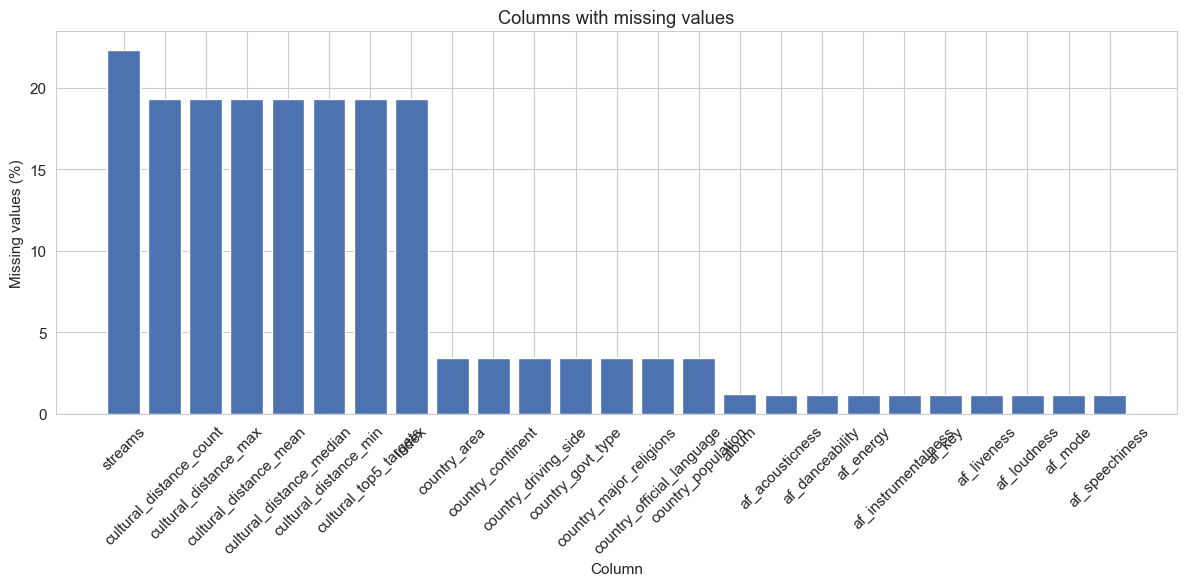

In [29]:
plot_bar(
    missing_df.query("missing_count > 0"),
    x="column_name",
    y="missing_pct",
    title="Columns with missing values",
    xlabel="Column",
    ylabel="Missing values (%)",
    top_n=25
)


In [30]:
# Missingness by feature group

feature_groups = {
    "audio_features": [
        "af_danceability", "af_energy", "af_valence", "af_tempo",
        "af_acousticness", "af_speechiness", "af_instrumentalness", "af_liveness",
        "af_key", "af_loudness", "af_mode", "af_time_signature"
    ],
    "track_metadata": [
        "title", "artist", "album", "release_date", "explicit", "duration_ms",
        "track_id"
    ],
    "chart_fields": [
        "date", "rank", "streams", "region", "chart", "trend"
    ],
    "country_context": [
        "country_continent", "country_official_language", "country_population"
    ],
    "cultural_distance": [
        "cultural_distance_mean", "cultural_distance_median",
        "cultural_distance_min", "cultural_distance_max",
        "cultural_distance_count", "cultural_top5_targets"
    ]
}

group_rows = []
for group_name, cols in feature_groups.items():
    subset = missing_df[missing_df["column_name"].isin(cols)]
    if len(subset) == 0:
        continue
    group_rows.append({
        "feature_group": group_name,
        "n_columns": len(subset),
        "avg_missing_pct": subset["missing_pct"].mean(),
        "max_missing_pct": subset["missing_pct"].max()
    })

missing_group_df = pd.DataFrame(group_rows).sort_values("avg_missing_pct", ascending=False)
missing_group_df


,feature_group,n_columns,avg_missing_pct,max_missing_pct
4,cultural_distance,6,19.352758,19.352758
2,chart_fields,6,3.726502,22.359012
3,country_context,3,3.437781,3.437781
0,audio_features,12,1.162405,1.162405
1,track_metadata,7,0.840771,1.235668


In [31]:
# Missingness by chart type for all feature groups
# This checks whether missing values are concentrated in Top 200, Viral 50, or both

feature_groups = {
    "streams": ["streams"],
    "audio_features": [
        "af_danceability", "af_energy", "af_valence", "af_tempo",
        "af_acousticness", "af_speechiness", "af_instrumentalness", "af_liveness",
        "af_key", "af_loudness", "af_mode", "af_time_signature"
    ],
    "track_metadata": [
        "title", "artist", "album", "release_date", "duration_ms", "explicit", "track_id"
    ],
    "country_context": [
        "country_continent", "country_official_language", "country_population"
    ],
    "cultural_distance": [
        "cultural_distance_mean", "cultural_distance_median", 
        "cultural_distance_min", "cultural_distance_max"
    ]
}

results = []
for group_name, cols in feature_groups.items():
    for col in cols:
        try:
            row = q(f"""
                SELECT
                    '{group_name}' AS feature_group,
                    '{col}' AS column_name,
                    chart,
                    COUNT(*) AS n_rows,
                    SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS n_missing,
                    ROUND(100.0 * SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_missing
                FROM {MAIN_TABLE}
                GROUP BY 1, 2, 3
                ORDER BY 3
            """)
            results.append(row)
        except Exception as e:
            print(f"  Skipping {col}: {e}")

missing_by_chart_df = pd.concat(results, ignore_index=True)

# Show only columns that actually have missing values
has_missing = missing_by_chart_df[missing_by_chart_df['n_missing'] > 0]
print(f"Columns with missing values: {has_missing['column_name'].nunique()} of {missing_by_chart_df['column_name'].nunique()}")
has_missing.pivot_table(
    index=['feature_group', 'column_name'], 
    columns='chart', 
    values=['n_missing', 'pct_missing'],
    fill_value=0
)

Columns with missing values: 27 of 27


n_missing            pct_missing  \
chart                                           top200    viral50      top200   
feature_group     column_name                                                   
audio_features    af_acousticness               3040.0   301211.0        0.01   
                  af_danceability               3040.0   301211.0        0.01   
                  af_energy                     3040.0   301211.0        0.01   
                  af_instrumentalness           3040.0   301211.0        0.01   
                  af_key                        3040.0   301211.0        0.01   
                  af_liveness                   3040.0   301211.0        0.01   
                  af_loudness                   3040.0   301211.0        0.01   
                  af_mode                       3040.0   301211.0        0.01   
                  af_speechiness                3040.0   301211.0        0.01   
                  af_tempo                      3040.0   301211.0        0.01   
                  af_time_signature             3040.0   301211.0        0.01   
                  af_valence                    3040.0   301211.0        0.01   
country_context   country_continent           719458.0   180356.0        3.54   
                  country_official_language   719458.0   180356.0        3.54   
                  country_population          719458.0   180356.0        3.54   
cultural_distance cultural_distance_max      3879815.0  1185628.0       19.09   
                  cultural_distance_mean     3879815.0  1185628.0       19.09   
                  cultural_distance_median   3879815.0  1185628.0       19.09   
                  cultural_distance_min      3879815.0  1185628.0       19.09   
streams           streams                          0.0  5852308.0        0.00   
track_metadata    album                        18976.0   304451.0        0.09   
                  artist                           0.0       18.0        0.00   
                  duration_ms                   3040.0   301211.0        0.01   
                  explicit                      3040.0   301211.0        0.01   
                  release_date                  3040.0   301211.0        0.01   
                  title                            7.0        4.0        0.00   
                  track_id                      3040.0   301211.0        0.01   

                                                     
chart                                       viral50  
feature_group     column_name                        
audio_features    af_acousticness              5.15  
                  af_danceability              5.15  
                  af_energy                    5.15  
                  af_instrumentalness          5.15  
                  af_key                       5.15  
                  af_liveness                  5.15  
                  af_loudness                  5.15  
                  af_mode                      5.15  
                  af_speechiness               5.15  
                  af_tempo                     5.15  
                  af_time_signature            5.15  
                  af_valence                   5.15  
country_context   country_continent            3.08  
                  country_official_language    3.08  
                  country_population           3.08  
cultural_distance cultural_distance_max       20.26  
                  cultural_distance_mean      20.26  
                  cultural_distance_median    20.26  
                  cultural_distance_min       20.26  
streams           streams                    100.00  
track_metadata    album                        5.20  
                  artist                       0.00  
                  duration_ms                  5.15  
                  explicit                     5.15  
                  release_date                 5.15  
                  title                        0.00  
                  track_id                     5

In [32]:
# Check missing days per country relative to the full dataset window (2017-01-01 to 2021-12-31)
# Filtered inline to Top 200 local charts only
# Countries with many missing days likely joined Spotify charts partway through the period

missing_days_by_country_df = q(f"""
WITH date_bounds AS (
    SELECT
        MIN(TRY_CAST(date AS DATE)) AS min_date,
        MAX(TRY_CAST(date AS DATE)) AS max_date
    FROM {MAIN_TABLE}
    WHERE LOWER(region) <> 'global'
      AND LOWER(chart) = 'top200'
      AND TRY_CAST(rank AS INTEGER) BETWEEN 1 AND 200
),
country_activity AS (
    SELECT
        region,
        COUNT(DISTINCT TRY_CAST(date AS DATE)) AS active_days
    FROM {MAIN_TABLE}
    WHERE LOWER(region) <> 'global'
      AND LOWER(chart) = 'top200'
      AND TRY_CAST(rank AS INTEGER) BETWEEN 1 AND 200
      AND TRY_CAST(date AS DATE) IS NOT NULL
    GROUP BY 1
)
SELECT
    ca.region,
    db.min_date,
    db.max_date,
    DATEDIFF('day', db.min_date, db.max_date) + 1 AS expected_days,
    ca.active_days,
    DATEDIFF('day', db.min_date, db.max_date) + 1 - ca.active_days AS missing_days,
    ROUND(100.0 * (DATEDIFF('day', db.min_date, db.max_date) + 1 - ca.active_days)
        / (DATEDIFF('day', db.min_date, db.max_date) + 1), 2) AS pct_missing_days
FROM country_activity ca
CROSS JOIN date_bounds db
ORDER BY missing_days DESC
""")

missing_days_by_country_df.head(20)

,region,min_date,max_date,expected_days,active_days,missing_days,pct_missing_days
0,Luxembourg,2017-01-01,2021-12-31,1826,297,1529,83.73
1,South Korea,2017-01-01,2021-12-31,1826,302,1524,83.46
2,Russia,2017-01-01,2021-12-31,1826,504,1322,72.40
3,Ukraine,2017-01-01,2021-12-31,1826,504,1322,72.40
4,Egypt,2017-01-01,2021-12-31,1826,787,1039,56.90
5,Morocco,2017-01-01,2021-12-31,1826,866,960,52.57
6,Saudi Arabia,2017-01-01,2021-12-31,1826,912,914,50.05
7,United Arab Emirates,2017-01-01,2021-12-31,1826,932,894,48.96
8,India,2017-01-01,2021-12-31,1826,1008,818,44.80
9,Nicaragua,2017-01-01,2021-12-31,1826,1100,726,39.76


In [33]:
# Check missing days per country per chart type relative to the full dataset window
# This helps identify whether coverage gaps are specific to Top 200, Viral 50, or both

missing_days_by_country_chart_df = q(f"""
WITH date_bounds AS (
    SELECT
        MIN(TRY_CAST(date AS DATE)) AS min_date,
        MAX(TRY_CAST(date AS DATE)) AS max_date
    FROM {MAIN_TABLE}
    WHERE LOWER(region) <> 'global'
      AND TRY_CAST(date AS DATE) IS NOT NULL
),
country_chart_activity AS (
    SELECT
        region,
        chart,
        COUNT(DISTINCT TRY_CAST(date AS DATE)) AS active_days
    FROM {MAIN_TABLE}
    WHERE LOWER(region) <> 'global'
      AND TRY_CAST(date AS DATE) IS NOT NULL
    GROUP BY 1, 2
)
SELECT
    ca.region,
    ca.chart,
    db.min_date,
    db.max_date,
    DATEDIFF('day', db.min_date, db.max_date) + 1 AS expected_days,
    ca.active_days,
    DATEDIFF('day', db.min_date, db.max_date) + 1 - ca.active_days AS missing_days,
    ROUND(100.0 * (DATEDIFF('day', db.min_date, db.max_date) + 1 - ca.active_days)
        / (DATEDIFF('day', db.min_date, db.max_date) + 1), 2) AS pct_missing_days
FROM country_chart_activity ca
CROSS JOIN date_bounds db
ORDER BY missing_days DESC
""")

missing_days_by_country_chart_df.head(30)

,region,chart,min_date,max_date,expected_days,active_days,missing_days,pct_missing_days
0,Luxembourg,top200,2017-01-01,2021-12-31,1826,297,1529,83.73
1,South Korea,top200,2017-01-01,2021-12-31,1826,302,1524,83.46
2,South Korea,viral50,2017-01-01,2021-12-31,1826,334,1492,81.71
3,Russia,top200,2017-01-01,2021-12-31,1826,504,1322,72.40
4,Ukraine,top200,2017-01-01,2021-12-31,1826,504,1322,72.40
5,Russia,viral50,2017-01-01,2021-12-31,1826,522,1304,71.41
6,Ukraine,viral50,2017-01-01,2021-12-31,1826,536,1290,70.65
7,Egypt,top200,2017-01-01,2021-12-31,1826,787,1039,56.90
8,Morocco,top200,2017-01-01,2021-12-31,1826,866,960,52.57
9,Saudi Arabia,top200,2017-01-01,2021-12-31,1826,912,914,50.05


In [34]:
# Check whether audio feature missingness is concentrated in specific countries or time periods
# af_danceability is used as a proxy for all audio features since they share identical missingness

audio_missing_by_country_df = q(f"""
SELECT
    region,
    COUNT(*) AS n_rows,
    SUM(CASE WHEN af_danceability IS NULL OR TRIM(af_danceability) = '' THEN 1 ELSE 0 END) AS missing_audio,
    ROUND(100.0 * SUM(CASE WHEN af_danceability IS NULL OR TRIM(af_danceability) = '' THEN 1 ELSE 0 END) 
        / COUNT(*), 2) AS pct_missing_audio
FROM {MAIN_TABLE}
WHERE LOWER(region) <> 'global'
GROUP BY 1
ORDER BY missing_audio DESC
""")

audio_missing_by_country_df.head(20)

,region,n_rows,missing_audio,pct_missing_audio
0,Japan,447108,9954.0,2.23
1,Taiwan,446683,8849.0,1.98
2,India,253036,8327.0,3.29
3,United Kingdom,450732,7434.0,1.65
4,United States,455085,7266.0,1.60
5,New Zealand,449252,7236.0,1.61
6,Turkey,449107,7169.0,1.60
7,Russia,126837,7164.0,5.65
8,Germany,448192,7101.0,1.58
9,Ireland,449340,6772.0,1.51


In [35]:
# Check audio feature missingness by year to identify whether gaps are time-concentrated

audio_missing_by_year_df = q(f"""
SELECT
    COALESCE(
        TRY_CAST(year AS INTEGER),
        EXTRACT(YEAR FROM TRY_CAST(date AS DATE))::INTEGER
    ) AS year,
    COUNT(*) AS n_rows,
    SUM(CASE WHEN af_danceability IS NULL OR TRIM(af_danceability) = '' THEN 1 ELSE 0 END) AS missing_audio,
    ROUND(100.0 * SUM(CASE WHEN af_danceability IS NULL OR TRIM(af_danceability) = '' THEN 1 ELSE 0 END) 
        / COUNT(*), 2) AS pct_missing_audio
FROM {MAIN_TABLE}
WHERE LOWER(region) <> 'global'
GROUP BY 1
ORDER BY 1
""")

audio_missing_by_year_df

,year,n_rows,missing_audio,pct_missing_audio
0,2017,4312451,62400.0,1.45
1,2018,4771910,747.0,0.02
2,2019,5321713,44.0,0.00
3,2020,5701665,0.0,0.00
4,2021,5614726,238734.0,4.25


**Findings**

- **Streams missingness is entirely structural**  
  The `streams` column has 5,852,308 missing values (22.4% of all rows), corresponding exactly to the Viral 50 share of the dataset. The chart-level breakdown confirms that Top 200 rows have no missing streams whatsoever; the gap is exclusive to Viral 50, where stream counts are not reported. This does not pose a modeling issue since Viral 50 presence is captured separately as an engineered binary flag for Top 200 songs.

- **Cultural distance columns are missing for ~19% of rows**  
  All six cultural distance columns (`cultural_distance_mean`, `_median`, `_min`, `_max`, `_count`, `cultural_top5_targets`) share the same missingness of 5,065,443 rows (19.4%). This reflects countries for which Hofstede index data was unavailable at merge time. Rows with missing cultural distance are excluded from analyses that depend on this feature.

- **Country context columns are missing for ~3.4% of rows**  
  Seven country-level columns (`country_continent`, `country_official_language`, `country_population`, etc.) share an identical missing count of 899,814 rows (3.4%), indicating a consistent join gap for a specific subset of regions in the reference dataset.

- **Raw Top 200 audio missingness exists, but it is extremely small**  
  The chart-level breakdown shows 3,040 missing Top 200 rows for every audio feature, equivalent to roughly 0.01% of Top 200 observations. This means the raw dataset is not perfectly complete even within the modeling-relevant chart scope, but the issue is negligible in magnitude compared with the structural Viral 50 gaps.

- **The Top 200 audio gaps are fully co-located with defective track records**  
  The same 3,040 Top 200 rows that are missing audio features are also missing `track_id`, `duration_ms`, `explicit`, and `release_date`. This indicates the problem is not isolated audio missingness but a small set of incomplete source records.

- **A subset of countries have severely incomplete daily coverage**  
  The missing days analysis reveals that Luxembourg (83.7%), South Korea (83.5%), Russia (72.4%), Ukraine (72.4%), Egypt (56.9%), Morocco (52.6%) and Saudi Arabia (50.1%) are missing a large share of the 1,826-day window across both Top 200 and Viral 50 charts. These gaps are consistent across chart types, confirming they reflect late or partial adoption of Spotify charting rather than isolated data errors. These countries will be excluded during feature engineering to prevent corrupted diffusion labels (threshold >50% missingness).

- **Cleaning removes the affected Top 200 audio rows before modeling**  
  Because the Top 200 audio-missing rows are exactly the rows with missing `track_id`, they are removed during the cleaning step that drops null `track_id` observations. After that filter, the cleaned modeling base no longer carries substantive audio missingness.

- **No audio imputation is needed in feature engineering**  
  Because the Top 200 audio-missing rows are exactly the rows with missing `track_id`, dropping null `track_id` rows during cleaning resolves audio missingness entirely. The feature engineering pipeline does not apply median imputation or any other audio-feature correction.


## 1.3 Duplicate Records and Consistency Checks

In [37]:
# Check for exact duplicate rows across all columns

all_columns = columns["column_name"].tolist()
group_cols = ", ".join(all_columns)

duplicate_count_df = q(f"""
WITH row_groups AS (
    SELECT
        {group_cols},
        COUNT(*) AS n_rows
    FROM {MAIN_TABLE}
    GROUP BY {group_cols}
)
SELECT
    SUM(CASE WHEN n_rows > 1 THEN n_rows - 1 ELSE 0 END) AS duplicate_rows
FROM row_groups
""")

duplicate_count_df


,duplicate_rows
0,755.0


In [36]:
# Check whether a track appears multiple times in the same chart-country-date-rank combination

consistency_df = q(f"""
SELECT
    track_id,
    region,
    chart,
    TRY_CAST(date AS DATE) AS obs_date,
    TRY_CAST(rank AS INTEGER) AS rank_val,
    COUNT(*) AS n_rows
FROM {MAIN_TABLE}
GROUP BY 1, 2, 3, 4, 5
HAVING COUNT(*) > 1
ORDER BY n_rows DESC
LIMIT 20
""")

consistency_df


,track_id,region,chart,obs_date,rank_val,n_rows
0,5I25m3L32KCpo7WNdBSNL3,Ireland,viral50,2017-09-05,43,2
1,7klo2CCxxPuu63NEx5GIfF,Spain,viral50,2017-09-06,42,2
2,1btqr8GaNAwcGKuaTRphEZ,Luxembourg,viral50,2017-09-09,29,2
3,5pP3sLkAVZ03hyJ6SbsprC,Indonesia,viral50,2017-09-10,31,2
4,3al2hpm92xE0pBalqWQHdD,New Zealand,viral50,2017-09-13,17,2
5,3al2hpm92xE0pBalqWQHdD,Australia,viral50,2017-09-14,33,2
6,3al2hpm92xE0pBalqWQHdD,Denmark,viral50,2017-09-24,37,2
7,3al2hpm92xE0pBalqWQHdD,New Zealand,viral50,2017-09-27,32,2
8,3al2hpm92xE0pBalqWQHdD,United States,viral50,2017-09-29,35,2
9,4GI5TTxNW5w0SYOEpOQWTG,Latvia,viral50,2018-08-13,47,2


**Findings**

- **755 exact duplicate rows detected**  
  A small number of fully identical rows (755) exist in the raw dataset, representing less than 0.003% of all observations. All duplicates have a count of exactly 2, meaning no record appears more than twice.

- **Duplicates span both chart types**  
  The consistency check shows that duplicated (track, region, chart, date, rank) combinations appear in both Viral 50 and Top 200 charts, so they cannot be attributed to a single structural cause. They are likely the result of minor ingestion errors in the source data.

- **Impact on modeling is negligible**  
  Given the volume (755 out of 26 million rows), duplicates pose no meaningful risk to any downstream analysis. They are dropped in the cleaning step as a precaution.

## 1.4 Data Type Corrections and Parsing

In [37]:
# Create a cleaned analytical view with parsed types

q(f"""
CREATE OR REPLACE VIEW spotify_clean AS
SELECT
    title,
    artist,
    album,
    url,
    region,
    chart,
    trend,
    track_id,
    available_markets,
    source_country_norm,
    country_continent,
    country_official_language,
    country_major_religions,
    country_govt_type,
    country_driving_side,
    cultural_top5_targets,

    TRY_CAST(rank AS INTEGER) AS rank,
    TRY_CAST(streams AS BIGINT) AS streams,
    TRY_CAST(popularity AS DOUBLE) AS popularity,
    TRY_CAST(duration_ms AS BIGINT) AS duration_ms,
    CASE 
        WHEN LOWER(explicit) = 'true' THEN 1 
        WHEN LOWER(explicit) = 'false' THEN 0 
        ELSE NULL 
    END AS explicit,

    TRY_CAST(release_date AS DATE) AS release_date,
    TRY_CAST(date AS DATE) AS raw_date,
    TRY_CAST(observation_date AS DATE) AS observation_date,
    year_month,
    COALESCE(
        TRY_CAST(year AS INTEGER),
        EXTRACT(YEAR FROM TRY_CAST(observation_date AS DATE))::INTEGER,
        EXTRACT(YEAR FROM TRY_CAST(date AS DATE))::INTEGER
    ) AS year,

    TRY_CAST(af_danceability AS DOUBLE) AS af_danceability,
    TRY_CAST(af_energy AS DOUBLE) AS af_energy,
    TRY_CAST(af_key AS DOUBLE) AS af_key,
    TRY_CAST(af_loudness AS DOUBLE) AS af_loudness,
    TRY_CAST(af_mode AS DOUBLE) AS af_mode,
    TRY_CAST(af_speechiness AS DOUBLE) AS af_speechiness,
    TRY_CAST(af_acousticness AS DOUBLE) AS af_acousticness,
    TRY_CAST(af_instrumentalness AS DOUBLE) AS af_instrumentalness,
    TRY_CAST(af_liveness AS DOUBLE) AS af_liveness,
    TRY_CAST(af_valence AS DOUBLE) AS af_valence,
    TRY_CAST(af_tempo AS DOUBLE) AS af_tempo,
    TRY_CAST(af_time_signature AS DOUBLE) AS af_time_signature,

    TRY_CAST(country_population AS DOUBLE) AS country_population,
    TRY_CAST(country_area AS DOUBLE) AS country_area,

    TRY_CAST(cultural_distance_mean AS DOUBLE) AS cultural_distance_mean,
    TRY_CAST(cultural_distance_median AS DOUBLE) AS cultural_distance_median,
    TRY_CAST(cultural_distance_min AS DOUBLE) AS cultural_distance_min,
    TRY_CAST(cultural_distance_max AS DOUBLE) AS cultural_distance_max,
    TRY_CAST(cultural_distance_count AS DOUBLE) AS cultural_distance_count,

    "index" AS original_index
FROM {MAIN_TABLE}
""")

,Count


In [38]:
# Validate the cleaned view

spotify_clean_schema_df = q("""
DESCRIBE spotify_clean
""")

spotify_clean_schema_df


,column_name,column_type,null,key,default,extra
0,title,VARCHAR,YES,None,None,None
1,artist,VARCHAR,YES,None,None,None
2,album,VARCHAR,YES,None,None,None
3,url,VARCHAR,YES,None,None,None
4,region,VARCHAR,YES,None,None,None
5,chart,VARCHAR,YES,None,None,None
6,trend,VARCHAR,YES,None,None,None
7,track_id,VARCHAR,YES,None,None,None
8,available_markets,VARCHAR,YES,None,None,None
9,source_country_norm,VARCHAR,YES,None,None,None


**Findings**

- **All numeric fields are correctly typed in `spotify_clean`**  
  The cleaned view resolves the raw schema's type issues: `rank` and `explicit` are cast to INTEGER; `streams` and `duration_ms` to BIGINT; `popularity` and all 12 audio features (`af_danceability`, `af_energy`, `af_key`, `af_loudness`, `af_mode`, `af_speechiness`, `af_acousticness`, `af_instrumentalness`, `af_liveness`, `af_valence`, `af_tempo`, `af_time_signature`) to DOUBLE; and `release_date`, `raw_date`, and `observation_date` to DATE.

- **Year is derived robustly**  
  The `year` column is computed via a COALESCE fallback, first from the raw `year` field, then extracted from `observation_date`, then from `date` ensuring no observation loses its year assignment due to a single missing field.

- **Enrichment columns are fully retained**  
  All country-level enrichment columns (continent, official language, cultural distance indices, population, area) are carried through unchanged, keeping the full feature set available for downstream analysis.

- **46 columns retained, original index preserved**  
  The cleaned view maintains the same 46 columns as the raw dataset, with the original `index` field renamed to `original_index` to avoid conflicts with SQL reserved keywords.
- **`year_month` remains VARCHAR**  
  The `year_month` column is a pre-computed string (e.g. "2020-03") and is passed through as VARCHAR. The `year` column is derived via COALESCE and stored as INTEGER.


## 1.5 Summary of Cleaning Decisions

The following main cleaning decisions should be applied before feature engineering and modeling

- **Drop exact duplicates** - 755 fully identical rows are removed, representing less than 0.003% of all observations.
- **Cast numeric and date fields** - `rank`, `streams`, `duration_ms`, `explicit`, `popularity`, all 12 audio features, and all date columns are converted from VARCHAR to their correct types in `spotify_clean`.
- **Exclude Global region** - rows where `region = 'Global'` are filtered out, as the modeling task focuses on country-level diffusion.
- **Filter to Top 200 charts only** - Viral 50 rows are excluded from the `local_top200` analytical view used in all diffusion analyses, since the prediction target is defined on Top 200 chart entries.
- **Exclude `popularity` from modeling** - although retained in `spotify_clean`, `popularity` is dropped as a feature because Spotify updates it algorithmically based on recent streams, making it a source of target leakage.
- **Drop rows with missing `track_id`** - the small set of Top 200 rows with missing audio features is fully co-located with rows missing `track_id` and related metadata. Removing null `track_id` rows therefore resolves the residual Top 200 audio gaps as part of the core cleaning pipeline.
- **Exclude countries with severe coverage gaps** - countries missing more than 50% of the 1,826-day window (Luxembourg, South Korea, Russia, Ukraine, Egypt, Morocco, Saudi Arabia) are excluded during feature engineering to prevent corrupted diffusion labels.
- **Retain all 12 audio features for modeling without imputation** — all 12 audio features (`af_danceability`, `af_energy`, `af_valence`, `af_tempo`, `af_acousticness`, `af_speechiness`, `af_instrumentalness`, `af_liveness`, `af_key`, `af_loudness`, `af_mode`, `af_time_signature`) are carried forward to the modeling dataset. After dropping null `track_id` rows during cleaning, audio missingness is fully resolved and no imputation is applied in feature engineering.
- **Retain missing cultural distance rows for non-cultural analyses** - rows with missing Hofstede-based features are kept in the main dataset but excluded only where cultural distance is specifically required as a feature.
- **Exclude raw `streams` from song-level modeling** - Viral 50 rows have no stream counts (structural missingness affecting 22.4% of rows), making song-level stream features unreliable. However, market-level stream aggregates (e.g. trailing 30-day average daily streams per country) will be computed during feature engineering as target country characteristics, using Top 200 data only.


# Part II — Overview of Global Chart Dynamics

This section characterises how songs distribute across countries in the Top 200 charts, how many markets a typical song reaches over its lifetime, and where songs tend to first appear. All analyses in this section use the `local_top200` view, which filters to non-global Top 200 entries with valid dates, track IDs, and ranks between 1 and 200. The findings here establish the baseline picture of chart activity that motivates the diffusion analysis in Part III.

## 2.1 Distribution of Chart Entries Across Countries

In [39]:
# Focus the diffusion analysis on local Top 200 charts.
# Global rows are excluded because the modeling task concerns country-level diffusion.

q("""
CREATE OR REPLACE VIEW local_top200 AS
SELECT *
FROM spotify_clean
WHERE LOWER(region) <> 'global'
  AND LOWER(chart) = 'top200'
  AND observation_date IS NOT NULL
  AND track_id IS NOT NULL
  AND rank BETWEEN 1 AND 200
""")


,Count


In [40]:
entries_by_country_df = q("""
SELECT
    region,
    COUNT(*) AS observations
FROM local_top200
GROUP BY 1
ORDER BY observations DESC
""")

entries_by_country_df.describe()


,observations
count,68.000000
mean,293482.161765
std,98402.085857
min,8957.000000
25%,246705.000000
50%,357567.500000
75%,358345.500000
max,364503.000000


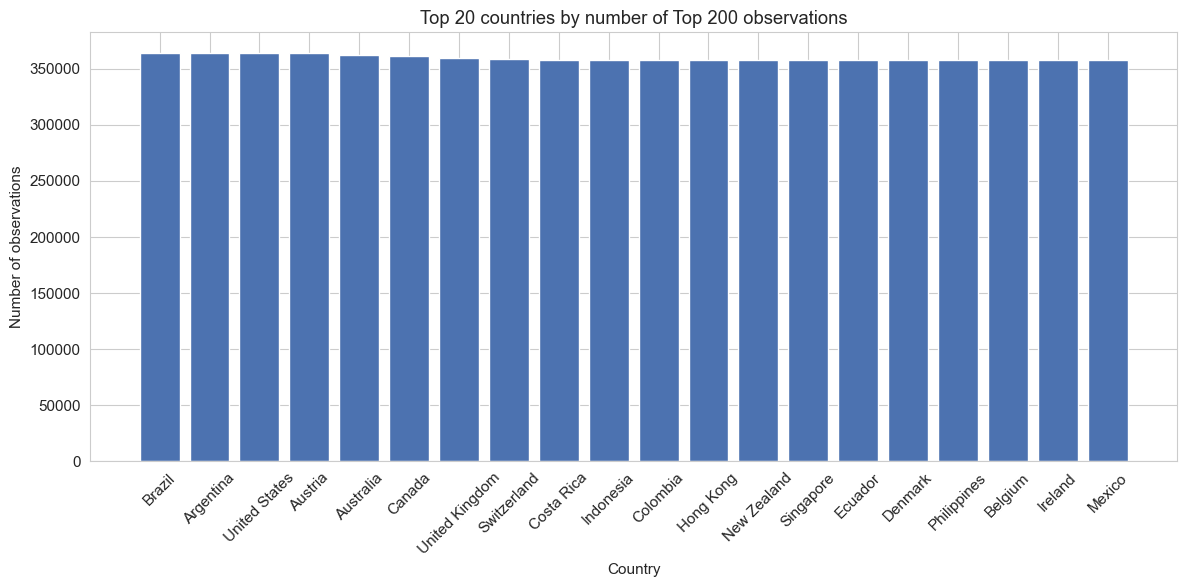

In [41]:
plot_bar(
    entries_by_country_df,
    x="region",
    y="observations",
    title="Top 20 countries by number of Top 200 observations",
    xlabel="Country",
    ylabel="Number of observations",
    top_n=20
)


**Findings**

- **Coverage is uneven across countries**  
  While most countries contribute around 357,000–358,000 observations (median 357,568, 75th percentile 358,346), the distribution has a notable left tail — the minimum is just 8,957 observations and the 25th percentile sits at 246,705. This means a meaningful subset of markets have substantially fewer chart entries than the majority, likely reflecting countries that joined the Spotify charting system later in the dataset period.

- **The bulk of markets are consistently tracked**  
  Above the 25th percentile, the interquartile range is very tight (246,705 to 358,346), and the top end reaches 364,503. For the majority of countries the dataset provides dense, consistent daily coverage across the full five-year window.

- **No dominant market skew at the top**  
  Unlike many global datasets where one or two markets dominate, the upper end of the distribution shows no single country accounting for a disproportionate share of observations. Market size effects are unlikely to distort the modeling dataset.

## 2.2 Total Countries Reached per Song

In [42]:
song_country_reach_df = q("""
SELECT
    track_id,
    title,
    COUNT(DISTINCT region) AS n_countries_reached
FROM local_top200
GROUP BY 1, 2
ORDER BY n_countries_reached DESC
""")

song_country_reach_df.head()


,track_id,title,n_countries_reached
0,4fouWK6XVHhzl78KzQ1UjL,abcdefu,68
1,2Oycxb8QbPkpHTo8ZrmG0B,Prisoner (feat. Dua Lipa),68
2,4iJyoBOLtHqaGxP12qzhQI,Peaches (feat. Daniel Caesar & Giveon),68
3,7ju97lgwC2rKQ6wwsf9no9,Rain On Me (with Ariana Grande),68
4,3FeVmId7tL5YN8B7R3imoM,My Universe,68


In [43]:
song_country_reach_df["n_countries_reached"].describe()


count    117972.000000
mean          3.045562
std           7.297675
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          68.000000
Name: n_countries_reached, dtype: float64

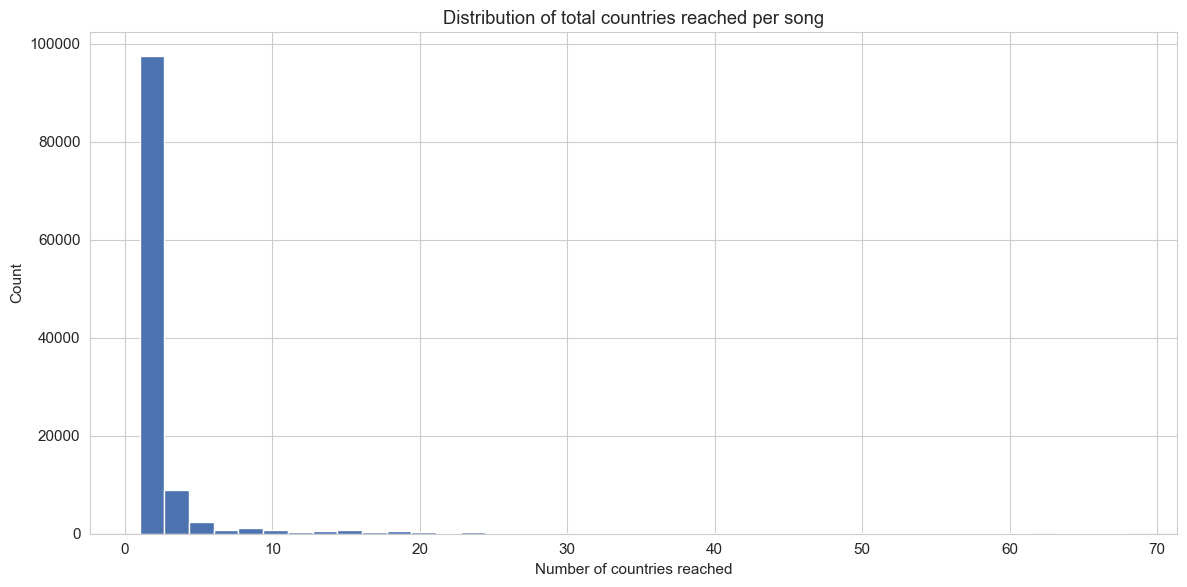

In [44]:
plot_hist(
    song_country_reach_df["n_countries_reached"],
    bins=40,
    title="Distribution of total countries reached per song",
    xlabel="Number of countries reached"
)


**Findings**

- **Most songs chart in only one country**  
  The median number of countries reached per song is 1, and the 75th percentile is just 2. This means cross-border diffusion is the exception rather than the rule — the majority of the 117,876 unique tracks never leave their home market.

- **A small number of songs reach near-global coverage**  
  The top songs reach up to 68 countries (out of 69 local markets in the raw data — some chart on the same day in multiple regions). The mean of 3.05 countries is pulled upward by these globally dominant tracks.

- **Heavy right skew has implications for modeling**  
  The distribution is extremely right-skewed. The modeling task — predicting which countries a song will enter — is therefore predicting a rare event for most songs, which justifies the class imbalance handling strategy (negative downsampling, class weighting) planned for the modeling phase.

## 2.3 First Chart Appearance: Where Songs Start

In [45]:
# First chart date of each song in each country

q("""
CREATE OR REPLACE VIEW song_country_first_entry AS
SELECT
    track_id,
    region,
    MIN(observation_date) AS first_entry_date
FROM local_top200
GROUP BY 1, 2
""")


,Count


In [46]:
# First global chart date per song

q("""
CREATE OR REPLACE VIEW song_first_global_entry AS
SELECT
    track_id,
    MIN(first_entry_date) AS first_global_entry_date
FROM song_country_first_entry
GROUP BY 1
""")


,Count


In [47]:
# Countries in which songs first appear

first_start_country_df = q("""
SELECT
    scfe.region,
    COUNT(*) AS n_song_origins
FROM song_country_first_entry scfe
JOIN song_first_global_entry sfge
  ON scfe.track_id = sfge.track_id
 AND scfe.first_entry_date = sfge.first_global_entry_date
GROUP BY 1
ORDER BY n_song_origins DESC
""")

print(first_start_country_df.head(20))
print(first_start_country_df.tail(20))


            region  n_song_origins
0          Germany            8332
1      Switzerland            8107
2           Sweden            7929
3    United States            7885
4           France            7833
5          Finland            7681
6      Netherlands            7575
7           Taiwan            7325
8   United Kingdom            7021
9          Austria            7019
10          Norway            6919
11           Italy            6172
12          Canada            6084
13         Denmark            5721
14          Poland            5607
15         Belgium            5558
16         Ireland            5280
17  Czech Republic            5149
18         Hungary            4989
19    South Africa            4478
                  region  n_song_origins
48            Costa Rica            2553
49               Estonia            2518
50                Russia            2339
51               Morocco            2301
52              Bulgaria            2253
53             Guat

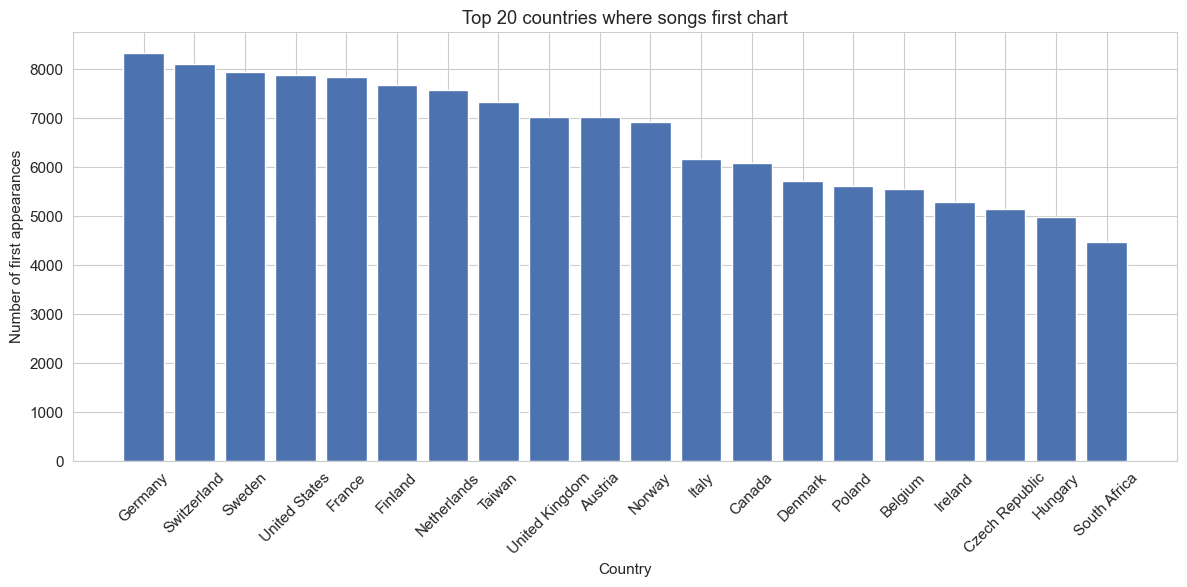

In [48]:
plot_bar(
    first_start_country_df,
    x="region",
    y="n_song_origins",
    title="Top 20 countries where songs first chart",
    xlabel="Country",
    ylabel="Number of first appearances",
    top_n=20
)


**Findings**

- **European markets dominate first chart appearances**  
  Germany (8,332), Switzerland (8,107), Sweden (7,929), and France (7,833) are the most common countries where songs first chart globally. This suggests Europe — particularly the DACH region and Nordics — acts as the primary launch market for a large share of charting songs.

- **The US ranks fourth, not first**  
  Despite being the world's largest music market, the United States (7,885) ranks fourth as a song origin country. This may reflect that many US-originated songs simultaneously debut in multiple markets, meaning their "first" country is ambiguous and distributed across several regions.

- **Origin country is a meaningful but ambiguous concept**  
  The spread of first appearances across many countries reinforces the design decision to avoid defining a single origin country in the modeling dataset, and instead encode the full spatial footprint via per-country rank columns.

## 2.4 Multi-Country Debuts vs Single-Country Debuts

In [49]:
multi_country_debut_df = q("""
WITH first_day_countries AS (
    SELECT
        scfe.track_id,
        COUNT(*) AS n_first_day_countries
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
     AND scfe.first_entry_date = sfge.first_global_entry_date
    GROUP BY 1
)
SELECT
    CASE 
        WHEN n_first_day_countries = 1 THEN 'single-country debut'
        ELSE 'multi-country debut'
    END AS debut_type,
    COUNT(*) AS n_songs
FROM first_day_countries
GROUP BY 1
ORDER BY n_songs DESC
""")

multi_country_debut_df


,debut_type,n_songs
0,single-country debut,94334
1,multi-country debut,23542


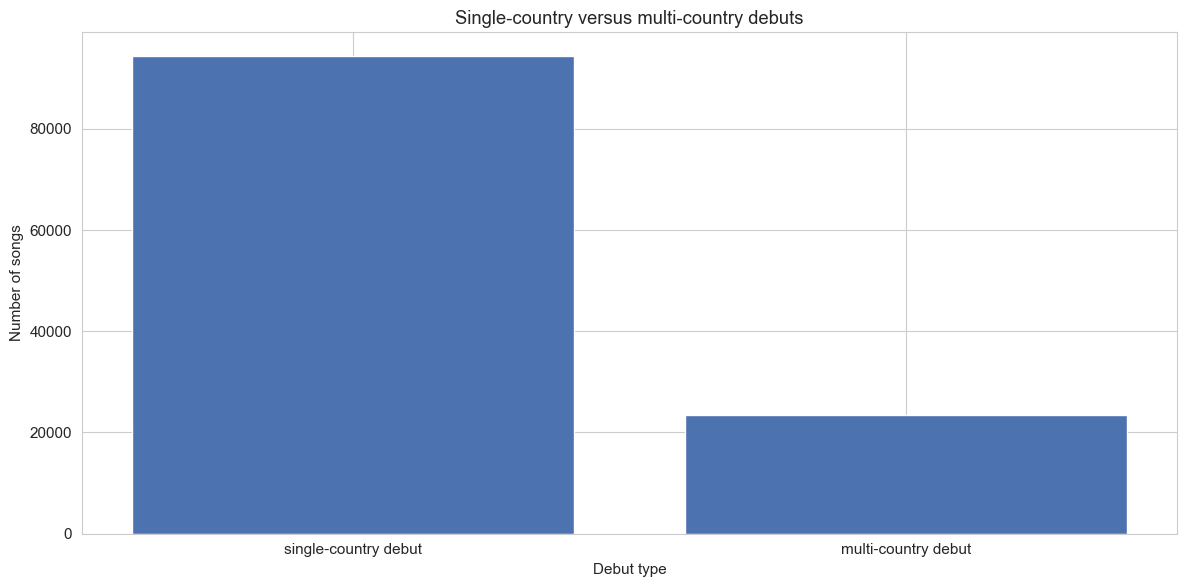

In [50]:
plot_bar(
    multi_country_debut_df,
    x="debut_type",
    y="n_songs",
    title="Single-country versus multi-country debuts",
    xlabel="Debut type",
    ylabel="Number of songs",
    rotation=0
)


In [51]:
# Among songs that debut in exactly one country, check whether they later chart in at least one additional country

single_debut_spread_df = q("""
WITH first_day_countries AS (
    SELECT
        scfe.track_id,
        COUNT(*) AS n_first_day_countries
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
     AND scfe.first_entry_date = sfge.first_global_entry_date
    GROUP BY 1
),
single_country_debuts AS (
    SELECT
        track_id
    FROM first_day_countries
    WHERE n_first_day_countries = 1
),
later_entries AS (
    SELECT
        scd.track_id,
        COUNT(DISTINCT scfe.region) AS n_additional_countries
    FROM single_country_debuts scd
    LEFT JOIN song_country_first_entry scfe
      ON scd.track_id = scfe.track_id
    LEFT JOIN song_first_global_entry sfge
      ON scd.track_id = sfge.track_id
    WHERE scfe.first_entry_date > sfge.first_global_entry_date
    GROUP BY scd.track_id
)
SELECT
    CASE
        WHEN n_additional_countries >= 1 THEN 'spread to other countries'
        ELSE 'stayed in debut country only'
    END AS spread_outcome,
    COUNT(*) AS n_songs
FROM later_entries
GROUP BY 1
ORDER BY n_songs DESC
""")

single_debut_spread_df

,spread_outcome,n_songs
0,spread to other countries,8133


In [52]:
# Among songs that debut in multiple countries, check whether they later chart in at least one additional country beyond their first-day footprint

multi_debut_spread_df = q("""
WITH first_day_countries AS (
    SELECT
        scfe.track_id,
        COUNT(*) AS n_first_day_countries
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
     AND scfe.first_entry_date = sfge.first_global_entry_date
    GROUP BY 1
),
multi_country_debuts AS (
    SELECT
        track_id
    FROM first_day_countries
    WHERE n_first_day_countries > 1
),
later_entries AS (
    SELECT
        mcd.track_id,
        COUNT(DISTINCT scfe.region) AS n_additional_countries
    FROM multi_country_debuts mcd
    LEFT JOIN song_country_first_entry scfe
      ON mcd.track_id = scfe.track_id
    LEFT JOIN song_first_global_entry sfge
      ON mcd.track_id = sfge.track_id
    WHERE scfe.first_entry_date > sfge.first_global_entry_date
    GROUP BY mcd.track_id
)
SELECT
    CASE
        WHEN n_additional_countries >= 1 THEN 'spread to more countries'
        ELSE 'stayed within first-day footprint'
    END AS spread_outcome,
    COUNT(*) AS n_songs
FROM later_entries
GROUP BY 1
ORDER BY n_songs DESC
""")

multi_debut_spread_df

,spread_outcome,n_songs
0,spread to more countries,7099


In [53]:
# For songs that debut in multiple countries, check how many countries they debut in on the first day to see if there's a relationship between initial multi-country exposure and later spread beyond the debut footprint

first_day_country_count_df = q("""
WITH first_day_countries AS (
    SELECT
        scfe.track_id,
        COUNT(*) AS n_first_day_countries
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
     AND scfe.first_entry_date = sfge.first_global_entry_date
    GROUP BY 1
)
SELECT
    n_first_day_countries,
    COUNT(*) AS n_songs
FROM first_day_countries
GROUP BY 1
ORDER BY 1
""")

first_day_country_count_df.head(30)


,n_first_day_countries,n_songs
0,1,94334
1,2,9001
2,3,5305
3,4,1793
4,5,991
5,6,634
6,7,526
7,8,380
8,9,370
9,10,298


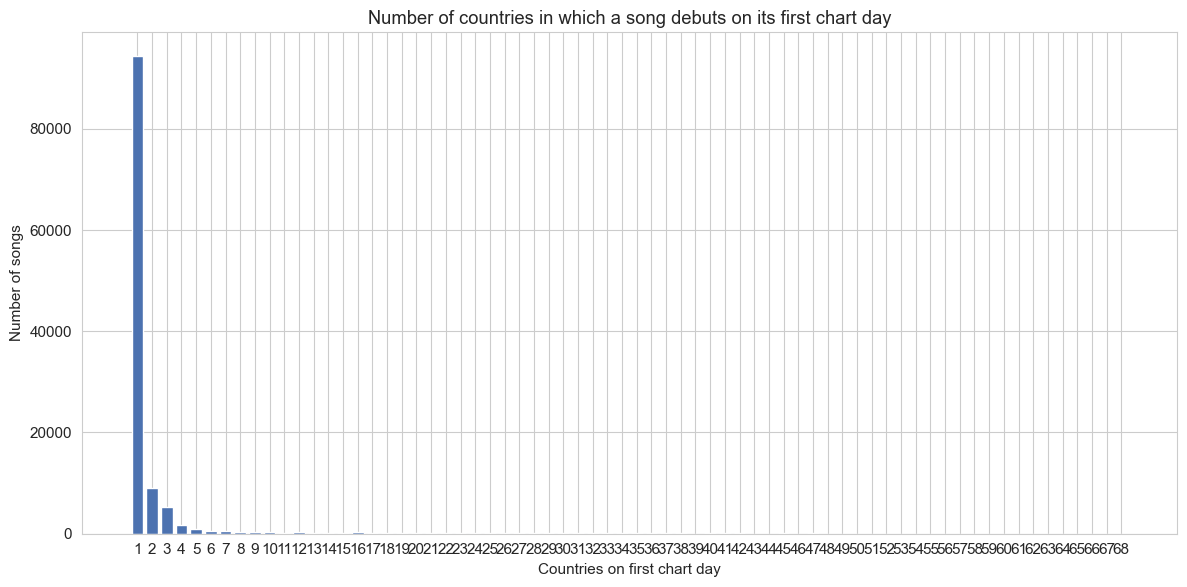

In [54]:
plot_bar(
    first_day_country_count_df,
    x="n_first_day_countries",
    y="n_songs",
    title="Number of countries in which a song debuts on its first chart day",
    xlabel="Countries on first chart day",
    ylabel="Number of songs",
    rotation=0
)


**Findings**

- **Single-country debuts are the norm**  
  94,334 songs (80%) debut in exactly one country, while 23,542 (20%) debut simultaneously in two or more markets on their first chart day. Among multi-country debuts, the distribution drops sharply after 2 countries (9,001 songs) and 3 countries (5,305 songs), with very few songs debuting in more than 10 markets simultaneously.

- **Cross-border spread is rare overall**  
  Of the 94,334 single-country debuts, only 8,133 (8.6%) ever spread to at least one additional country. Of the 23,542 multi-country debuts, 7,099 (30.2%) spread further. Songs that launch across multiple markets from day one are roughly 3.5x more likely to continue spreading than those that start in a single market.

- **Debut breadth is a key modeling feature**  
  The number of countries charting at day 0 — encoded in the per-country rank columns (62 in the final modeling dataset) — directly captures this momentum signal and is expected to be among the most predictive features in the model.

## 2.5 Implications for Modeling and Business Perspective

**Modeling implications**

- **Cross-border spread is a rare event.** Only 8.6% of single-country debuts and 30.2% of multi-country debuts ever spread further. This confirms the class imbalance problem anticipated in the modeling design — the vast majority of (song, target_country) pairs will be negative examples, justifying negative downsampling to a ~5:1 ratio and the use of recall-focused evaluation metrics.

- **Day 0 footprint is the strongest early signal.** Songs debuting in multiple countries simultaneously are 3.5x more likely to spread further. The 62 per-country rank columns in the modeling dataset, which encode the full spatial footprint at day 0, are therefore expected to be the most predictive feature group in the model.

- **Diffusion is front-loaded.** The majority of cross-border spread occurs within the first few days of a song's global debut, as shown in detail in section 3.2. This supports the use of a 60-day prediction window — long enough to capture the vast majority of diffusion events, but not so long as to include noise from songs that chart incidentally months later.

- **Origin country is not a meaningful single variable.** With 80% of songs debuting in one country but spread distributed across many launch markets, defining a single origin is both ambiguous and lossy. The per-country rank column approach captures this complexity correctly.

**Business implications**

- **The tool addresses a real and time-sensitive decision.** Labels and distributors must decide within days of a song's debut whether to invest in international promotion. The window for action is narrow — the cost of waiting too long is missing the momentum entirely.

- **Not all markets are equal targets.** The concentration of first chart appearances in European markets (Germany, Switzerland, Sweden, France) suggests these act as leading indicators for broader international diffusion. A prediction tool that surfaces likely target markets — rather than just a binary yes/no — directly informs where to allocate promotional budget.

- **False negatives are more costly than false positives.** Missing a potential international hit means a lost revenue opportunity; incorrectly flagging a song as likely to spread results only in a wasted promotional budget. This asymmetry justifies optimizing for recall over precision, which is reflected in the choice of evaluation metrics.

# Part III — Diffusion of Songs Across Countries

This section examines the mechanics of cross-border diffusion, how quickly songs spread to new markets, how many countries they reach within the prediction window, and which countries tend to lead or follow in the diffusion process. All analyses build on the `song_country_first_entry` and `song_first_global_entry` views established in Part II. The findings here directly inform the design of the target variable and the expected difficulty of the prediction task.

## 3.1 Time Until Entry in Additional Countries

In [55]:
# Days between the first global chart date and the first chart entry in each country

days_to_country_df = q("""
SELECT
    scfe.track_id,
    scfe.region,
    DATEDIFF('day', sfge.first_global_entry_date, scfe.first_entry_date) AS days_to_entry
FROM song_country_first_entry scfe
JOIN song_first_global_entry sfge
  ON scfe.track_id = sfge.track_id
WHERE scfe.first_entry_date > sfge.first_global_entry_date
""")

days_to_country_df.head()


,track_id,region,days_to_entry
0,776AftMmFFAWUIEAb3lHhw,Hungary,65
1,4a9RlnJ0v1T7HgLtps1HvI,Iceland,2
2,4qu63nuBpdn0qHUHuObEj1,Ireland,7
3,07MDkzWARZaLEdKxo6yArG,Latvia,8
4,0VVa11kcXBGm99NgSiF8Rx,Latvia,1


In [56]:
days_to_country_df["days_to_entry"].describe()


count    89844.000000
mean       101.574429
std        241.432366
min          1.000000
25%          1.000000
50%         12.000000
75%         60.000000
max       1825.000000
Name: days_to_entry, dtype: float64

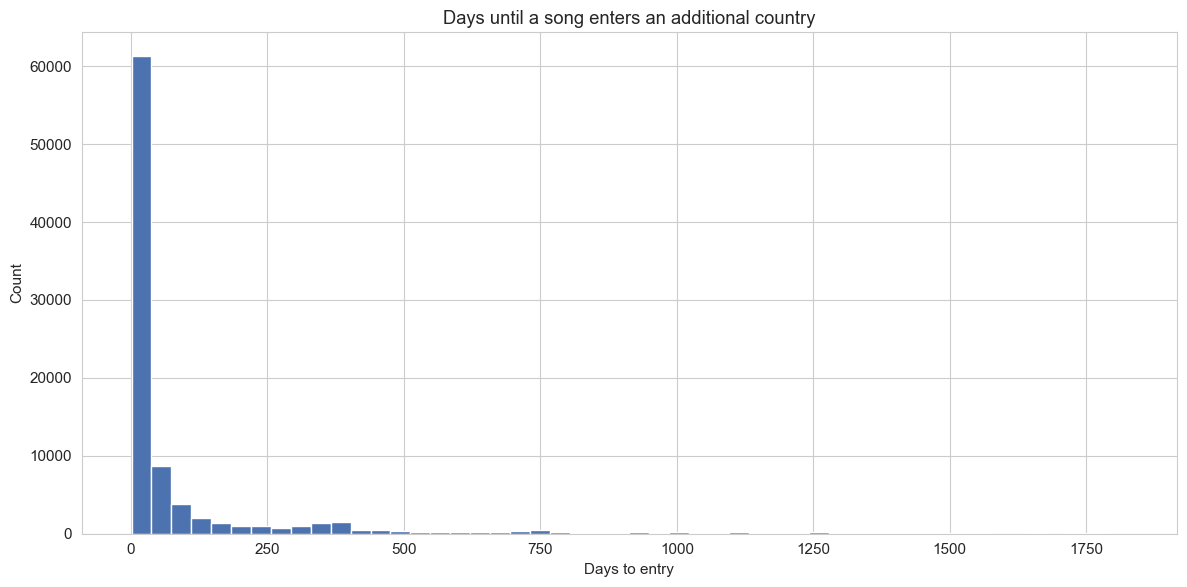

In [57]:
plot_hist(
    days_to_country_df["days_to_entry"],
    bins=50,
    title="Days until a song enters an additional country",
    xlabel="Days to entry"
)


**Findings**

- **Diffusion is heavily right-skewed**  
  The mean time to entry in an additional country is 101.6 days, but the median is just 12 days and the 25th percentile is 1 day. This extreme right skew is driven by a long tail of songs that chart sporadically in new markets many months after their initial appearance, pulling the mean far above the typical case.

- **The 75th percentile is 60 days**  
  Three quarters of all cross-border entries happen within 60 days of a song's first global chart appearance. This directly motivates the choice of a 60-day prediction window for the target variable — it captures the large majority of meaningful diffusion events while excluding the noisy long tail.

- **Immediate diffusion is common**  
  The 25th percentile of 1 day confirms that a large share of cross-border entries happen on the very same day as a song's global debut, consistent with the multi-country launch patterns identified in Part II.

## 3.2 Distribution of Cross-Border Spread Within 60 Days

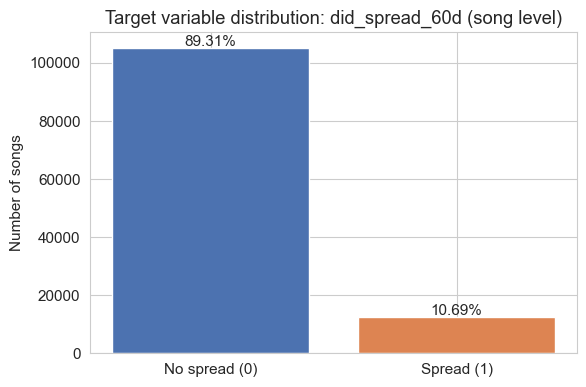

,did_spread_60d,n_songs,pct
0,0,105280,89.31
1,1,12596,10.69


In [58]:
# Target variable distribution: did the song spread to at least one additional country within 60 days?

target_dist_df = q("""
WITH spread AS (
    SELECT
        sfge.track_id,
        CASE
            WHEN COUNT(DISTINCT CASE
                WHEN scfe.first_entry_date > sfge.first_global_entry_date
                 AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
                THEN scfe.region
            END) > 0 THEN 1 ELSE 0
        END AS did_spread_60d
    FROM song_first_global_entry sfge
    LEFT JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
    GROUP BY 1
)
SELECT
    did_spread_60d,
    COUNT(*) AS n_songs,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM spread
GROUP BY 1
ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["No spread (0)", "Spread (1)"],
    target_dist_df["n_songs"],
    color=["#4C72B0", "#DD8452"]
)
for bar, pct in zip(bars, target_dist_df["pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f"{pct}%", ha="center", fontsize=11)
ax.set_title("Target variable distribution: did_spread_60d (song level)")
ax.set_ylabel("Number of songs")
plt.tight_layout()
plt.show()

target_dist_df

In [59]:
# Rough estimate of pair-level class balance on the raw local_top200 scope
# Each song generates one row per candidate target country it is NOT already charting in at day 0
# The raw scope includes 69 local markets; the actual modeling dataset will use 62 after exclusions

N_LOCAL_MARKETS = 69  # local markets in raw v1 (excluding Global)

pair_balance_df = q(f"""
WITH first_day_footprint AS (
    SELECT
        sfge.track_id,
        COUNT(DISTINCT scfe.region) AS n_charting_at_day0
    FROM song_first_global_entry sfge
    JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
     AND scfe.first_entry_date = sfge.first_global_entry_date
    GROUP BY 1
),
spread_counts AS (
    SELECT
        sfge.track_id,
        COUNT(DISTINCT CASE
            WHEN scfe.first_entry_date > sfge.first_global_entry_date
             AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
            THEN scfe.region
        END) AS n_positive_targets
    FROM song_first_global_entry sfge
    LEFT JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
    GROUP BY 1
)
SELECT
    SUM({N_LOCAL_MARKETS} - LEAST(ff.n_charting_at_day0, {N_LOCAL_MARKETS})) AS est_total_pairs,
    SUM(sc.n_positive_targets) AS est_positive_pairs,
    ROUND(100.0 * SUM(sc.n_positive_targets)
        / NULLIF(SUM({N_LOCAL_MARKETS} - LEAST(ff.n_charting_at_day0, {N_LOCAL_MARKETS})), 0), 2) AS est_positive_rate_pct
FROM first_day_footprint ff
JOIN spread_counts sc ON ff.track_id = sc.track_id
""")

pair_balance_df


,est_total_pairs,est_positive_pairs,est_positive_rate_pct
0,7864281.0,67400.0,0.86


In [60]:
spread_60d_df = q("""
WITH base AS (
    SELECT
        sfge.track_id,
        COUNT(DISTINCT CASE 
            WHEN scfe.first_entry_date > sfge.first_global_entry_date
             AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
            THEN scfe.region
        END) AS additional_countries_60d
    FROM song_first_global_entry sfge
    LEFT JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
    GROUP BY 1
)
SELECT
    additional_countries_60d,
    COUNT(*) AS n_songs
FROM base
GROUP BY 1
ORDER BY 1
""")

spread_60d_df.head(20)


,additional_countries_60d,n_songs
0,0,105280
1,1,5474
2,2,2045
3,3,1043
4,4,651
5,5,477
6,6,353
7,7,290
8,8,248
9,9,189


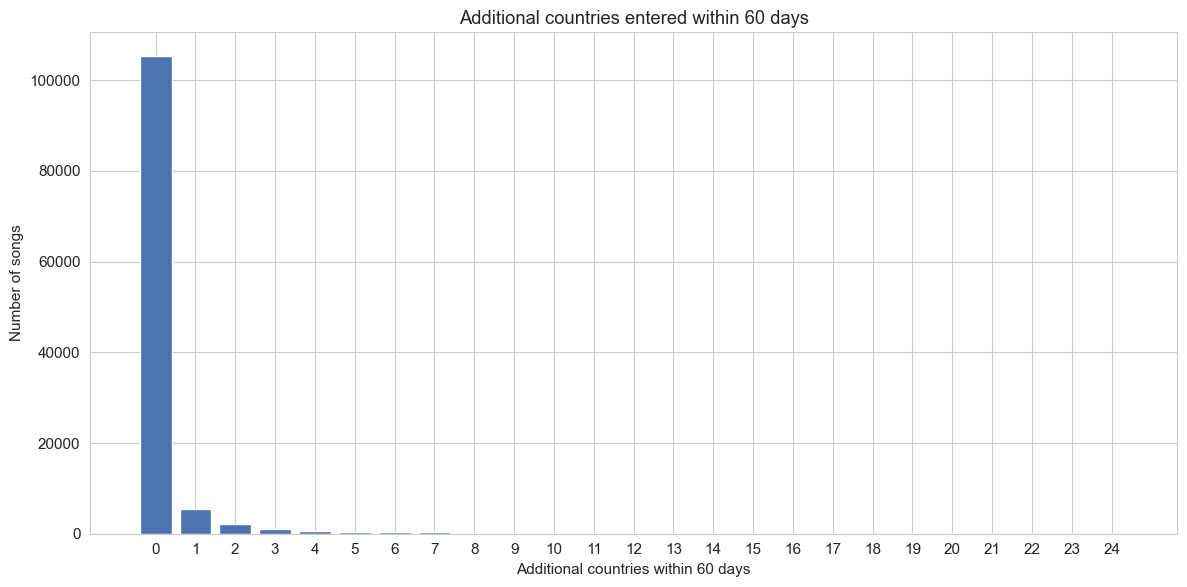

In [61]:
plot_bar(
    spread_60d_df,
    x="additional_countries_60d",
    y="n_songs",
    title="Additional countries entered within 60 days",
    xlabel="Additional countries within 60 days",
    ylabel="Number of songs",
    rotation=0,
    top_n=25
)


In [62]:
# For songs that debut in multiple countries and later spread further, measure how many days it takes until the first additional country entry and add a cumulative count and cumulative percentage

multi_debut_days_to_spread_df = q("""
WITH first_day_countries AS (
    SELECT
        scfe.track_id,
        COUNT(*) AS n_first_day_countries
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
     AND scfe.first_entry_date = sfge.first_global_entry_date
    GROUP BY 1
),
multi_country_debuts AS (
    SELECT
        track_id
    FROM first_day_countries
    WHERE n_first_day_countries > 1
),
first_additional_entry AS (
    SELECT
        mcd.track_id,
        MIN(scfe.first_entry_date) AS first_additional_entry_date
    FROM multi_country_debuts mcd
    JOIN song_country_first_entry scfe
      ON mcd.track_id = scfe.track_id
    JOIN song_first_global_entry sfge
      ON mcd.track_id = sfge.track_id
    WHERE scfe.first_entry_date > sfge.first_global_entry_date
    GROUP BY mcd.track_id
),
daily_counts AS (
    SELECT
        DATEDIFF('day', sfge.first_global_entry_date, fae.first_additional_entry_date) AS days_to_first_additional_country,
        COUNT(*) AS n_songs
    FROM first_additional_entry fae
    JOIN song_first_global_entry sfge
      ON fae.track_id = sfge.track_id
    GROUP BY 1
)
SELECT
    days_to_first_additional_country,
    n_songs,
    SUM(n_songs) OVER (
        ORDER BY days_to_first_additional_country
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cumulative_songs,
    ROUND(
        100.0 * SUM(n_songs) OVER (
            ORDER BY days_to_first_additional_country
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) / SUM(n_songs) OVER (),
        2
    ) AS cumulative_pct
FROM daily_counts
ORDER BY days_to_first_additional_country
""")

multi_debut_days_to_spread_df.head(30)

,days_to_first_additional_country,n_songs,cumulative_songs,cumulative_pct
0,1,3183,3183.0,44.84
1,2,594,3777.0,53.20
2,3,633,4410.0,62.12
3,4,338,4748.0,66.88
4,5,218,4966.0,69.95
5,6,179,5145.0,72.47
6,7,202,5347.0,75.32
7,8,81,5428.0,76.46
8,9,41,5469.0,77.04
9,10,48,5517.0,77.72


In [63]:
# For songs that debut in one country and later spread, measure how many days it takes until the first additional country entry

single_debut_days_to_spread_df = q("""
WITH first_day_countries AS (
    SELECT
        scfe.track_id,
        COUNT(*) AS n_first_day_countries
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
     AND scfe.first_entry_date = sfge.first_global_entry_date
    GROUP BY 1
),
single_country_debuts AS (
    SELECT
        track_id
    FROM first_day_countries
    WHERE n_first_day_countries = 1
),
first_additional_entry AS (
    SELECT
        scd.track_id,
        MIN(scfe.first_entry_date) AS first_additional_entry_date
    FROM single_country_debuts scd
    JOIN song_country_first_entry scfe
      ON scd.track_id = scfe.track_id
    JOIN song_first_global_entry sfge
      ON scd.track_id = sfge.track_id
    WHERE scfe.first_entry_date > sfge.first_global_entry_date
    GROUP BY scd.track_id
),
daily_counts AS (
    SELECT
        DATEDIFF('day', sfge.first_global_entry_date, fae.first_additional_entry_date) AS days_to_first_additional_country,
        COUNT(*) AS n_songs
    FROM first_additional_entry fae
    JOIN song_first_global_entry sfge
      ON fae.track_id = sfge.track_id
    GROUP BY 1
)
SELECT
    days_to_first_additional_country,
    n_songs,
    SUM(n_songs) OVER (
        ORDER BY days_to_first_additional_country
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cumulative_songs,
    ROUND(
        100.0 * SUM(n_songs) OVER (
            ORDER BY days_to_first_additional_country
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) / SUM(n_songs) OVER (),
        2
    ) AS cumulative_pct
FROM daily_counts
ORDER BY days_to_first_additional_country
""")

single_debut_days_to_spread_df.head(30)

,days_to_first_additional_country,n_songs,cumulative_songs,cumulative_pct
0,1,2190,2190.0,26.93
1,2,541,2731.0,33.58
2,3,408,3139.0,38.60
3,4,268,3407.0,41.89
4,5,196,3603.0,44.30
5,6,203,3806.0,46.80
6,7,232,4038.0,49.65
7,8,124,4162.0,51.17
8,9,85,4247.0,52.22
9,10,96,4343.0,53.40


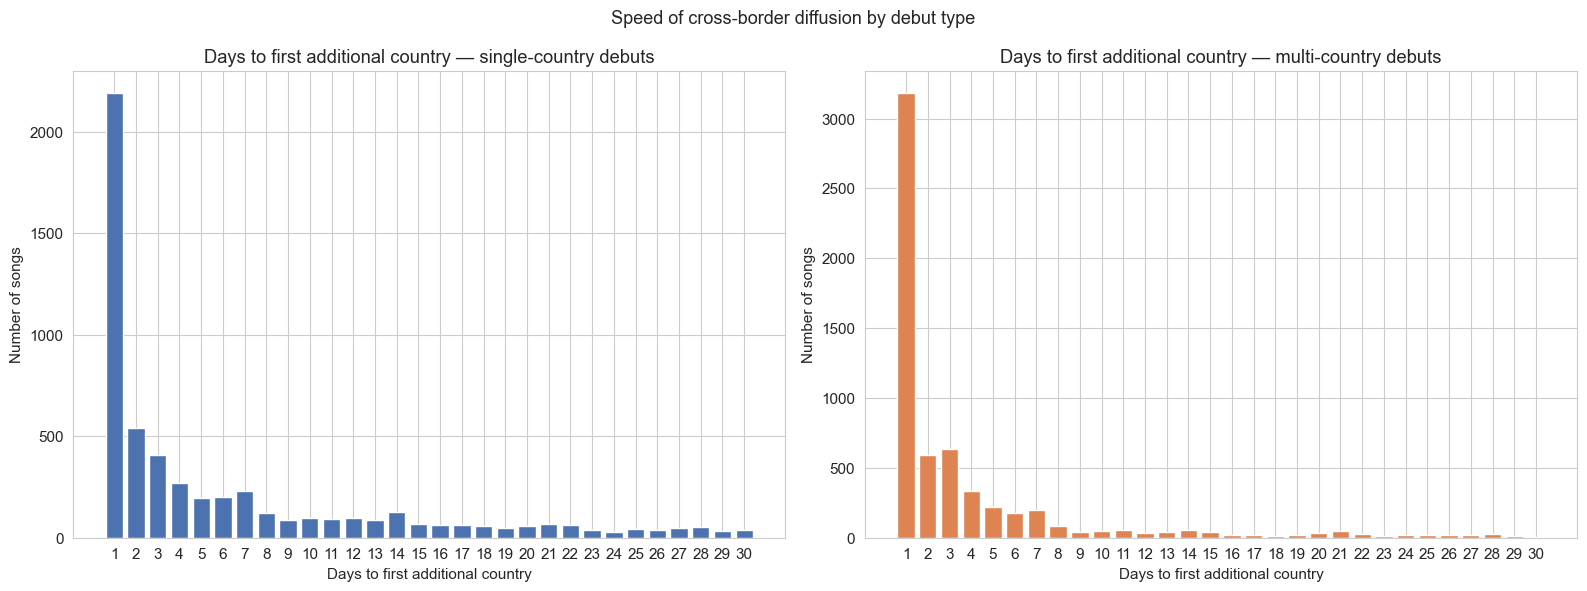

In [64]:
# Visualize the speed of cross-border diffusion by debut type, measured as days between first global chart entry and first additional country entry (if any)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Single-country debuts
axes[0].bar(
    single_debut_days_to_spread_df["days_to_first_additional_country"].head(30).astype(str),
    single_debut_days_to_spread_df["n_songs"].head(30),
    color="#4C72B0"
)
axes[0].set_title("Days to first additional country — single-country debuts")
axes[0].set_xlabel("Days to first additional country")
axes[0].set_ylabel("Number of songs")
axes[0].tick_params(axis="x", rotation=0)

# Multi-country debuts
axes[1].bar(
    multi_debut_days_to_spread_df["days_to_first_additional_country"].head(30).astype(str),
    multi_debut_days_to_spread_df["n_songs"].head(30),
    color="#DD8452"
)
axes[1].set_title("Days to first additional country — multi-country debuts")
axes[1].set_xlabel("Days to first additional country")
axes[1].set_ylabel("Number of songs")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Speed of cross-border diffusion by debut type", fontsize=13)
plt.tight_layout()
plt.show()

**Findings**

- **The song-level target is heavily imbalanced.** Roughly 90% of songs do not spread to any additional country within 60 days, confirming
  that cross-border diffusion is a rare-event classification problem even before expanding to the pair level.

- **At the pair level, the positive rate drops further.** With an estimated positive rate around 1.04% across all (song, target_country) pairs (estimated on the full 69-market raw scope; the final 62-country modeling dataset will differ slightly), the raw-scope pair dataset will have extreme class imbalance. This confirms the need for negative downsampling to approximately 5:1 and class weighting during model training. Evaluation metrics must prioritise recall and AUC-ROC over accuracy.

- **Most songs that spread reach only one or two additional countries within 60 days**  
  Of the 117,876 unique songs, 106,256 (90.1%) enter zero additional countries within 60 days of their global debut. Among those that do spread, the most common outcome is entering just 1 additional country (5,107 songs), with counts dropping sharply for each additional market. Truly global diffusion within 60 days is reserved for a tiny elite of tracks.

- **Single-country debuts spread slowly when they spread at all**  
  For single-country debuts that do spread, only 26.9% reach a new country on day 1, and just 49.7% have done so within the first 7 days. The distribution is notably flat after day 1, with spread trickling in gradually across the full 30-day window shown. By day 30, only 68.3% of spreading single-country debuts have reached at least one new market.

- **Multi-country debuts spread faster and more completely**  
  For multi-country debuts that spread further, diffusion is far more immediate — 44.8% reach an additional country on day 1, and 75.3% within 7 days. By day 30, 85.4% have entered at least one new market. The contrast with single-country debuts is stark: broad initial footprint not only predicts whether a song will spread, but also how quickly.

- **The day 1 spike is the dominant pattern for multi-country debuts**  
  The side-by-side plots make clear that multi-country debut diffusion is heavily concentrated on day 1 (3,183 songs), dropping sharply to 594 on day 2 and 633 on day 3. Single-country debuts show a similar but less pronounced day 1 spike (2,190 songs), with a slower and more gradual tail. This asymmetry reinforces the value of the per-country rank columns as a momentum signal at day 0.





## 3.3 Countries That Tend to Lead vs Follow

In [65]:
lead_follow_df = q("""
WITH country_stats AS (
    SELECT
        scfe.region,
        COUNT(*) AS total_first_entries,
        SUM(CASE WHEN scfe.first_entry_date = sfge.first_global_entry_date THEN 1 ELSE 0 END) AS first_day_entries
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
    GROUP BY 1
)
SELECT
    region,
    total_first_entries,
    first_day_entries,
    ROUND(100.0 * first_day_entries / NULLIF(total_first_entries, 0), 2) AS first_day_entry_share_pct
FROM country_stats
ORDER BY first_day_entry_share_pct DESC, total_first_entries DESC
""")

print(lead_follow_df.head(20))
print(lead_follow_df.tail(20))


            region  total_first_entries  first_day_entries  \
0           France                 8924             7833.0   
1           Brazil                 4788             4182.0   
2           Turkey                 4583             3954.0   
3            Italy                 7175             6172.0   
4    United States                 9244             7885.0   
5          Germany                 9870             8332.0   
6          Finland                 9136             7681.0   
7           Sweden                 9435             7929.0   
8      Netherlands                 9047             7575.0   
9           Russia                 2815             2339.0   
10         Morocco                 2783             2301.0   
11          Norway                 8418             6919.0   
12           India                 2493             2037.0   
13         Denmark                 7054             5721.0   
14  United Kingdom                 8695             7021.0   
15      

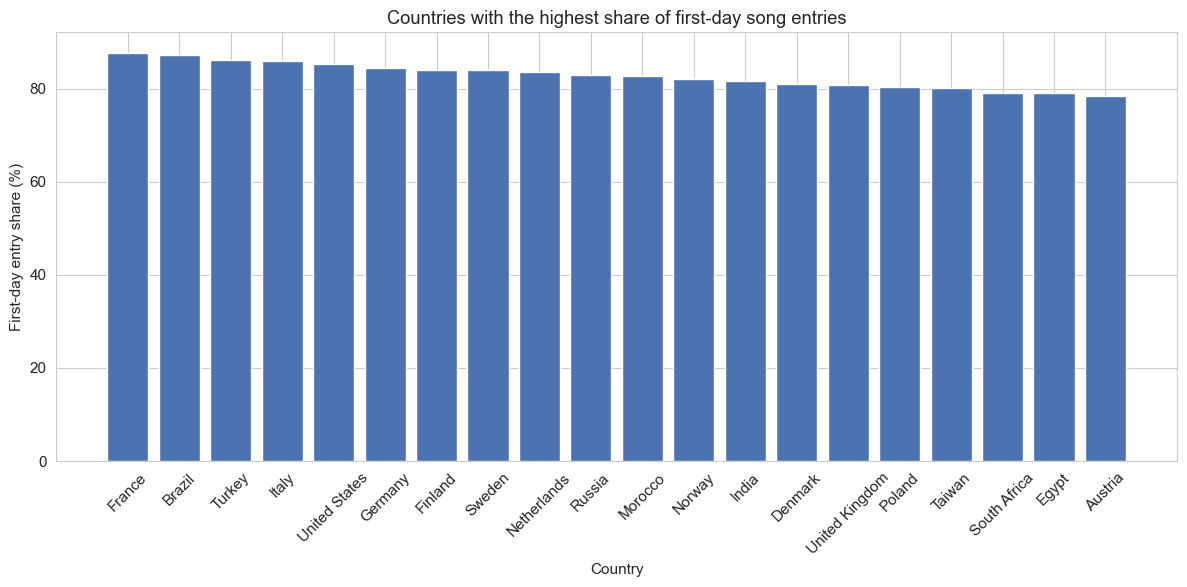

In [66]:
plot_bar(
    lead_follow_df,
    x="region",
    y="first_day_entry_share_pct",
    title="Countries with the highest share of first-day song entries",
    xlabel="Country",
    ylabel="First-day entry share (%)",
    top_n=20
)


**Findings**

- **Most countries are primarily same-day entrants**  
  The top countries by first-day entry share — France (87.8%), Brazil (87.3%), Turkey (86.3%), Italy (86.0%), and the United States (85.3%) — chart on the same day as the global debut for the vast majority of songs they ever feature. This means these markets tend to co-launch with songs rather than receiving them as diffusion targets.

- **A clear group of follower markets exists**  
  At the bottom of the distribution, Luxembourg (39.9%), UAE (57.5%), El Salvador (59.0%), and Paraguay (55.1%) have substantially lower first-day entry shares, meaning a larger proportion of their chart entries come days or weeks after a song's global debut. These markets are more likely to appear as genuine diffusion targets.

- **The lead/follow distinction supports the modeling design**  
  Countries with high first-day entry shares are more likely to appear as origin countries in the per-country rank columns at day 0. Countries with lower first-day shares are more likely to be valid target countries — markets the model needs to predict entry into. This structural asymmetry is implicitly captured by the feature engineering approach.

## 3.4 Most Common Origin-to-Target Country Flows

In [67]:
origin_target_flow_df = q("""
WITH origins AS (
    SELECT
        scfe.track_id,
        scfe.region AS origin_country
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
     AND scfe.first_entry_date = sfge.first_global_entry_date
),
targets AS (
    SELECT
        scfe.track_id,
        scfe.region AS target_country
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
    WHERE scfe.first_entry_date > sfge.first_global_entry_date
      AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 30 DAY
)
SELECT
    o.origin_country,
    t.target_country,
    COUNT(DISTINCT o.track_id) AS n_tracks
FROM origins o
JOIN targets t
  ON o.track_id = t.track_id
WHERE o.origin_country <> t.target_country
GROUP BY 1, 2
ORDER BY n_tracks DESC
LIMIT 30
""")

origin_target_flow_df


,origin_country,target_country,n_tracks
0,United States,New Zealand,528
1,United States,Australia,522
2,United States,Hong Kong,441
3,United States,Canada,431
4,Canada,Australia,416
5,Norway,Philippines,413
6,United States,Taiwan,413
7,United States,Philippines,412
8,United States,Singapore,412
9,Canada,New Zealand,409


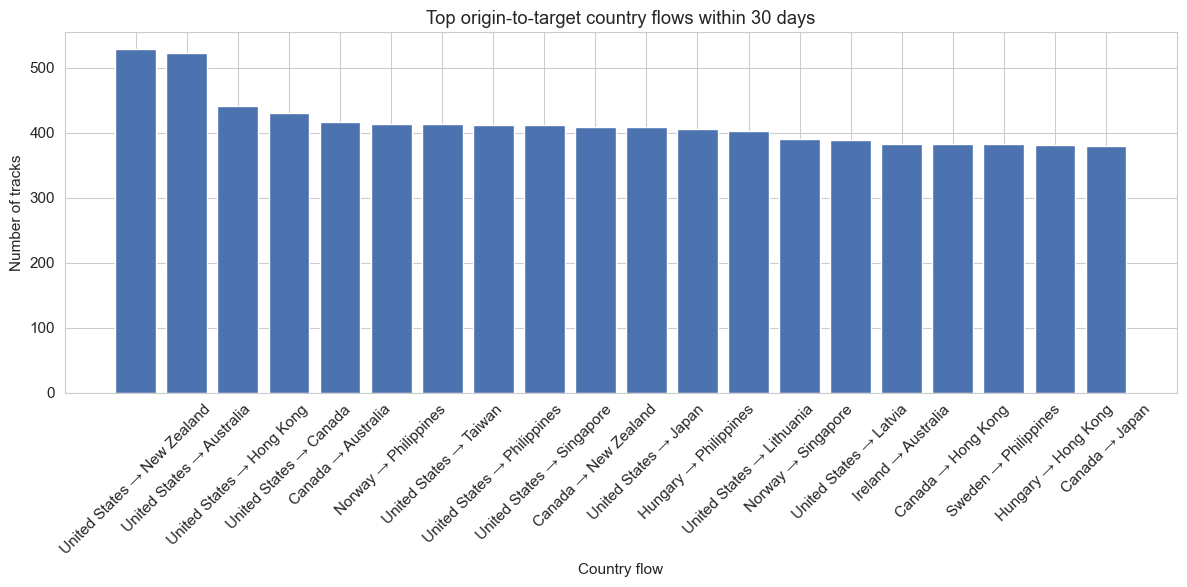

In [68]:
top_flow_labels = origin_target_flow_df["origin_country"] + " → " + origin_target_flow_df["target_country"]
flow_plot_df = origin_target_flow_df.copy()
flow_plot_df["flow"] = top_flow_labels

plot_bar(
    flow_plot_df,
    x="flow",
    y="n_tracks",
    title="Top origin-to-target country flows within 30 days",
    xlabel="Country flow",
    ylabel="Number of tracks",
    top_n=20
)


**Findings**

- **The United States is the dominant origin market**  
  US-origin flows appear 9 times in the top 30 pairs, with New Zealand (528 tracks), Australia (522), Hong Kong (441), Canada (431), and Taiwan (413) as the most common US targets. This reflects the global reach of US-produced music and the English-language connectivity between these markets.

- **Smaller European markets punch above their weight as origins**  
  Norway, Hungary, Ireland, Sweden, and Canada appear repeatedly as origin countries despite their smaller populations. This likely reflects the high density of locally-produced tracks that debut in these markets before spreading to Asian markets — particularly the Philippines, Singapore, Hong Kong, and Japan.

- **Asian markets appear almost exclusively as targets**  
  The Philippines, Singapore, Hong Kong, Japan, and Taiwan appear frequently as target countries but rarely as origins in the top flows. This suggests these markets tend to receive diffusion rather than initiate it, and are important target countries for the prediction task.

- **Geographic and cultural proximity does not fully explain flows**  
  The strong Norway→Philippines and Hungary→Philippines flows are not geographically or linguistically obvious, suggesting that platform-driven recommendation dynamics and artist-specific fanbase geography play a role beyond simple cultural distance.

## 3.5 Implications for Modeling and Business Perspective

**Modeling implications**

- **The 60-day window captures the bulk of diffusion.** The 75th percentile of days to entry is 60 days, and the cumulative spread curves in section 3.2 confirm that the large majority of cross-border entries that will ever happen occur within this window. Beyond 60 days, remaining entries are increasingly sparse and likely reflect incidental charting rather than genuine diffusion momentum.

- **Day 1 is disproportionately important.** Both single and multi-country debut songs show a sharp spike in cross-border entries on day 1, followed by a rapid drop-off. This front-loading means that the day 0 snapshot — the observation point used in the model — is taken at exactly the right moment: just before the most consequential diffusion decisions play out.

- **Lead and follower market structure is learnable.** The consistent pattern of certain countries (France, Brazil, Turkey) appearing as same-day co-launchers while others (Luxembourg, UAE, Latin American markets) follow later suggests that target-country identity carries systematic signal. The `target_country` categorical feature and the per-country rank columns together encode this structure.

- **Origin-to-target flows are not random.** The concentration of specific country pairs (US→New Zealand, Norway→Philippines, Hungary→Philippines) in the top flows suggests that artist-specific fanbase geography and platform recommendation dynamics create predictable diffusion corridors. These corridors are partially captured by the cultural distance and language features, but may also require the model to learn country-pair interactions directly from the rank columns.

**Business implications**

- **Speed of action matters.** Given that 44.8% of multi-country debut diffusion happens on day 1, labels that wait even a few days to assess international potential are already late for the fastest-moving songs. The tool is designed to flag potential at day 0 — the earliest possible moment.

- **Follower markets are the actionable targets.** Countries with low first-day entry shares (UAE, Luxembourg, Latin American markets) represent markets where a song has not yet charted but could — these are precisely the target countries the model is designed to score. Leading markets are typically already covered by the song's organic launch.

- **Known diffusion corridors can guide budget allocation.** The strong US→Anglophone and Nordic→Asian flows identified in section 3.4 suggest that promotional spend can be prioritized along established corridors when a new song debuts strongly in an origin market. The model quantifies this intuition at the individual song level.

# Part IV — Distribution of Feature Groups

This section examines the marginal distribution of each planned feature group: chart ranks at debut, audio characteristics, artist history, collaboration and release timing, cultural distance, and language similarity. The goal is to understand the shape, range, and completeness of each feature before testing it against the spread outcome in Part V. All analyses use song-level or track-level aggregations to avoid inflating counts with repeated daily chart rows.

## 4.1 Distribution of Initial Chart Ranks

In [69]:
# Rank on the song's first global chart day in each origin country

initial_ranks_df = q("""
SELECT
    TRY_CAST(l.rank AS INTEGER) AS initial_rank
FROM local_top200 l
JOIN song_first_global_entry sfge
  ON l.track_id = sfge.track_id
 AND l.observation_date = sfge.first_global_entry_date
WHERE TRY_CAST(l.rank AS INTEGER) BETWEEN 1 AND 200
""")


In [70]:
initial_ranks_df["initial_rank"].describe()


count    269183.000000
mean         97.931704
std          59.172083
min           1.000000
25%          48.000000
50%          94.000000
75%         150.000000
max         200.000000
Name: initial_rank, dtype: float64

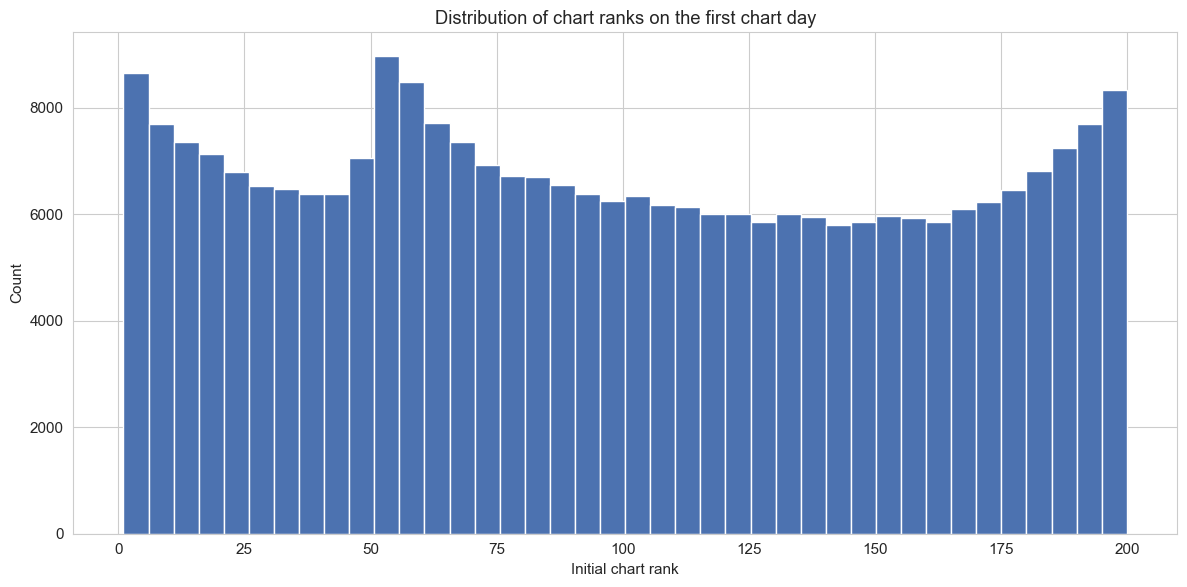

In [71]:
plot_hist(
    initial_ranks_df["initial_rank"],
    bins=40,
    title="Distribution of chart ranks on the first chart day",
    xlabel="Initial chart rank"
)


In [72]:
# Share of first-day chart entries that debut in positions 1 to 5

initial_rank_top5_df = q("""
SELECT
    CASE
        WHEN TRY_CAST(l.rank AS INTEGER) BETWEEN 1 AND 5 THEN 'rank 1-5'
        ELSE 'rank 6-200'
    END AS rank_group,
    COUNT(*) AS n_entries,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_entries
FROM local_top200 l
JOIN song_first_global_entry sfge
  ON l.track_id = sfge.track_id
 AND l.observation_date = sfge.first_global_entry_date
WHERE TRY_CAST(l.rank AS INTEGER) BETWEEN 1 AND 200
GROUP BY 1
ORDER BY n_entries DESC
""")

initial_rank_top5_df

,rank_group,n_entries,pct_entries
0,rank 6-200,260534,96.79
1,rank 1-5,8649,3.21


**Findings**

- **Initial ranks are approximately uniformly distributed**  
  The distribution of chart ranks at day 0 is close to uniform across positions 1–200, with a mean of 97.9 and a median of 94. This is expected, each country's Top 200 has exactly 200 slots, so ranks are bounded and roughly evenly filled across the range on any given day.

- **Very few songs debut at the very top**  
  Only 3.2% of first-day chart entries (8,649 out of 269,183) debut in positions 1–5. Debuting in the top 5 on the first chart day is therefore a meaningful signal of exceptional momentum and is expected to correlate with subsequent cross-border spread.

- **The rank feature encodes both presence and strength**  
  In the modeling dataset, rank columns take value 0 if a country is not charting at day 0, and 1–200 otherwise. This dual encoding — presence/absence plus rank strength — means the feature captures both the geographic footprint and the competitive position within each market simultaneously.

## 4.2 Distribution of Audio Features

In [73]:
# Creating a summary dataset with average audio feature values across all local Top 200 chart entries
# Includes all 12 audio features available in the dataset.
# The first 8 are the core continuous features, while key, loudness, mode,
# and time_signature are included as additional retained audio features.

audio_feature_cols_8 = [
    "af_danceability", "af_energy", "af_valence", "af_tempo",
    "af_acousticness", "af_speechiness", "af_instrumentalness", "af_liveness"
]

audio_feature_cols_extra = [
    "af_key", "af_loudness", "af_mode", "af_time_signature"
]

audio_feature_cols_all = audio_feature_cols_8 + audio_feature_cols_extra

audio_summary_df = q("""
SELECT
    AVG(af_danceability) AS af_danceability,
    AVG(af_energy) AS af_energy,
    AVG(af_valence) AS af_valence,
    AVG(af_tempo) AS af_tempo,
    AVG(af_acousticness) AS af_acousticness,
    AVG(af_speechiness) AS af_speechiness,
    AVG(af_instrumentalness) AS af_instrumentalness,
    AVG(af_liveness) AS af_liveness,
    AVG(af_key) AS af_key,
    AVG(af_loudness) AS af_loudness,
    AVG(af_mode) AS af_mode,
    AVG(af_time_signature) AS af_time_signature
FROM local_top200
""")

audio_summary_df


,af_danceability,af_energy,af_valence,af_tempo,af_acousticness,af_speechiness,af_instrumentalness,af_liveness,af_key,af_loudness,af_mode,af_time_signature
0,0.686441,0.645291,0.525679,121.085674,0.256644,0.108095,0.00815,0.167806,5.334998,-6.130353,0.574586,3.97039


In [74]:
# Create a track-level dataset with audio feature values for each track.
# Uses MIN() as a simple dedup — audio features are constant per track.

track_audio_df = q("""
SELECT
    track_id,
    MIN(af_danceability) AS af_danceability,
    MIN(af_energy) AS af_energy,
    MIN(af_valence) AS af_valence,
    MIN(af_tempo) AS af_tempo,
    MIN(af_acousticness) AS af_acousticness,
    MIN(af_speechiness) AS af_speechiness,
    MIN(af_instrumentalness) AS af_instrumentalness,
    MIN(af_liveness) AS af_liveness,
    MIN(af_key) AS af_key,
    MIN(af_loudness) AS af_loudness,
    MIN(af_mode) AS af_mode,
    MIN(af_time_signature) AS af_time_signature
FROM local_top200
GROUP BY track_id
""")

track_audio_df.head()


,track_id,af_danceability,af_energy,af_valence,af_tempo,af_acousticness,af_speechiness,af_instrumentalness,af_liveness,af_key,af_loudness,af_mode,af_time_signature
0,0DRKnh0BloxJHyhXkfbiX8,0.554,0.640,0.641,160.009,0.34100,0.1870,0.000000,0.1080,0.0,-7.587,1.0,4.0
1,1gQqtmfp9sWORxjuNMrB5k,0.393,0.760,0.295,162.090,0.00404,0.0278,0.000000,0.1230,9.0,-4.672,1.0,4.0
2,7vGuf3Y35N4wmASOKLUVVU,0.520,0.761,0.286,141.971,0.25600,0.0853,0.000005,0.1700,4.0,-3.093,1.0,4.0
3,1KT0xdIjm7t053xByACrrg,0.512,0.532,0.283,81.353,0.12600,0.0266,0.000000,0.1030,6.0,-6.821,1.0,4.0
4,7FyHSAzfTFu88aDOpOIVtH,0.676,0.516,0.465,145.911,0.80000,0.0361,0.000000,0.0902,0.0,-7.574,1.0,4.0


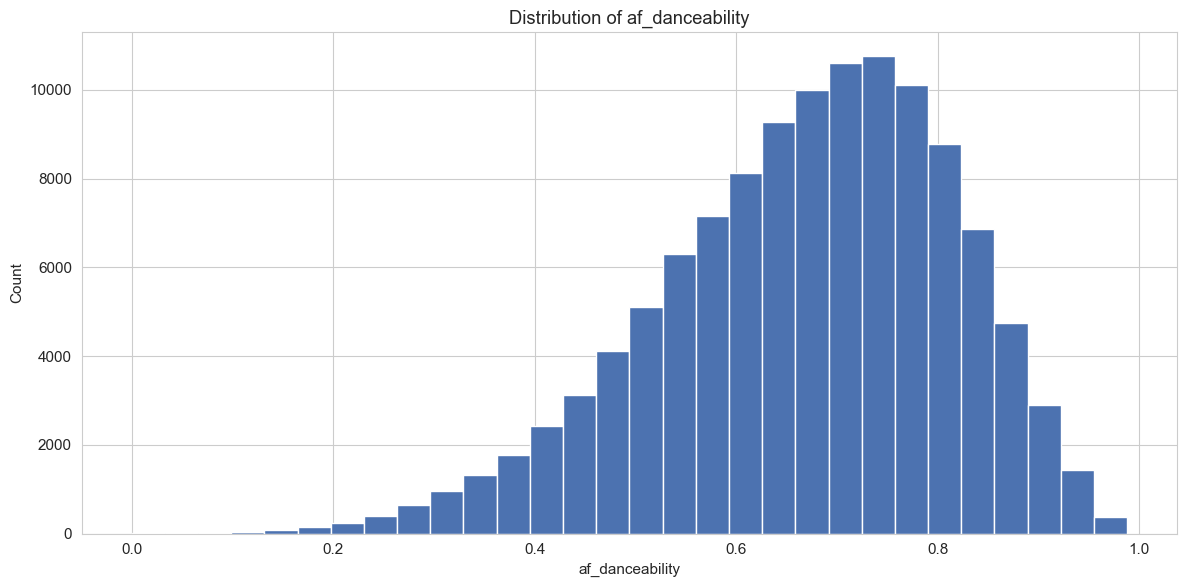

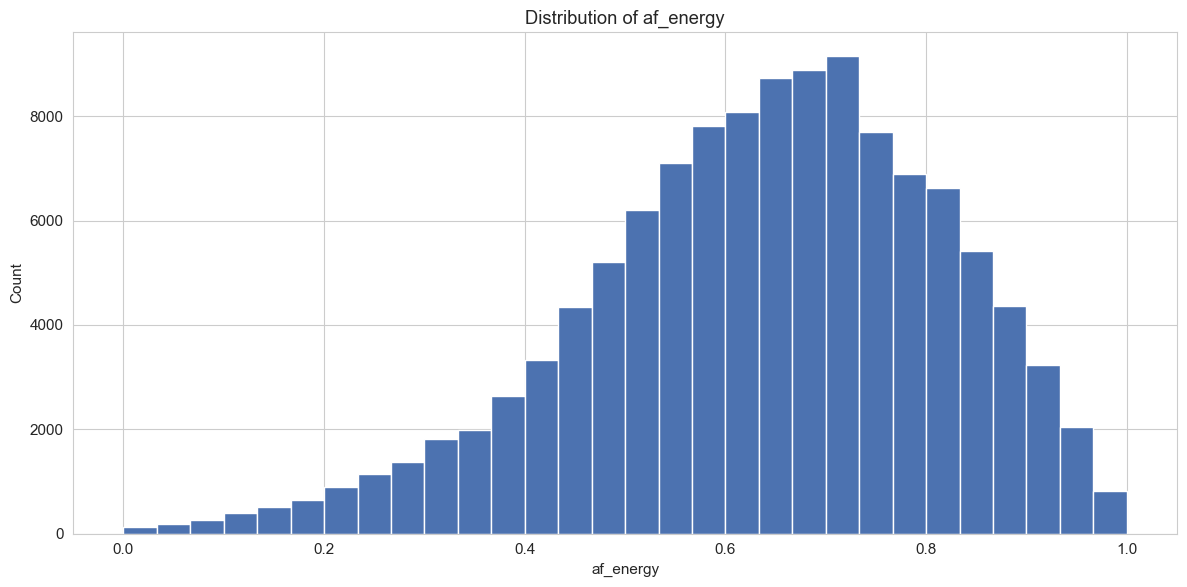

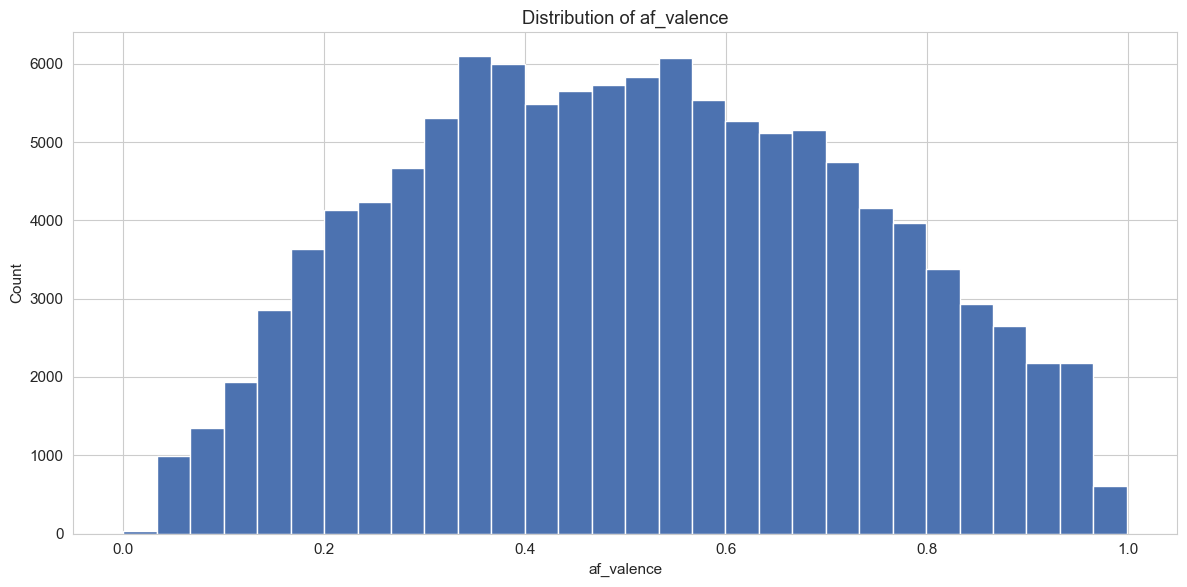

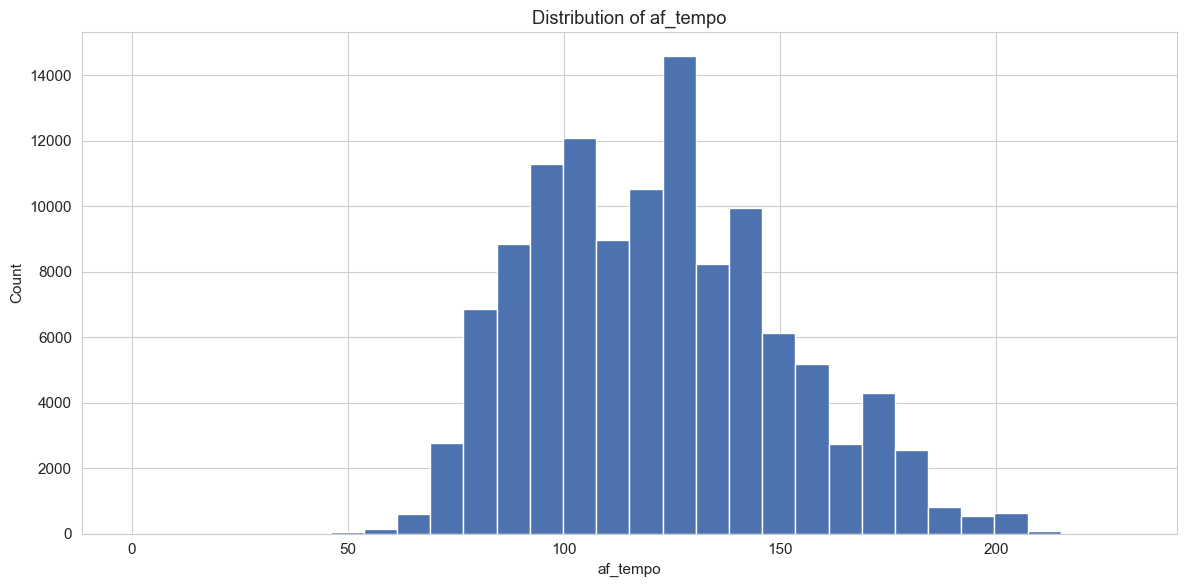

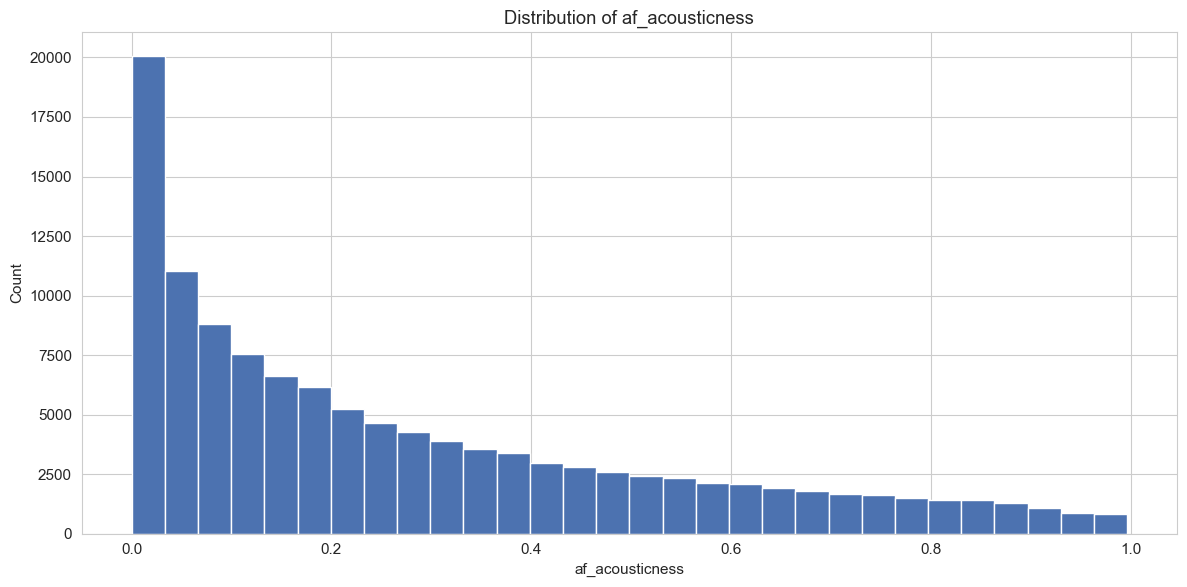

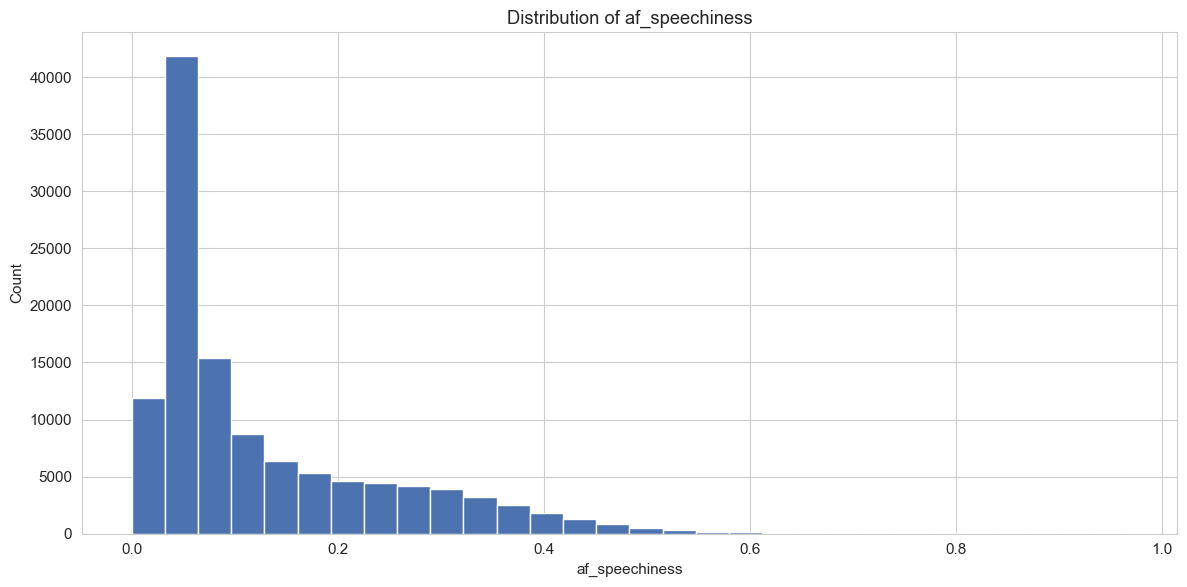

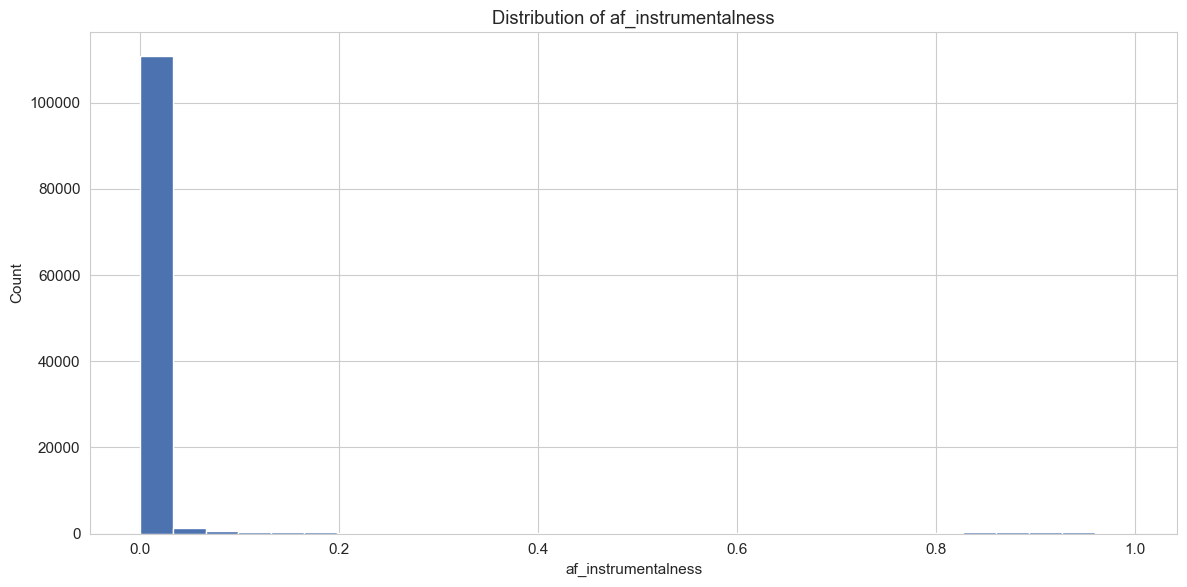

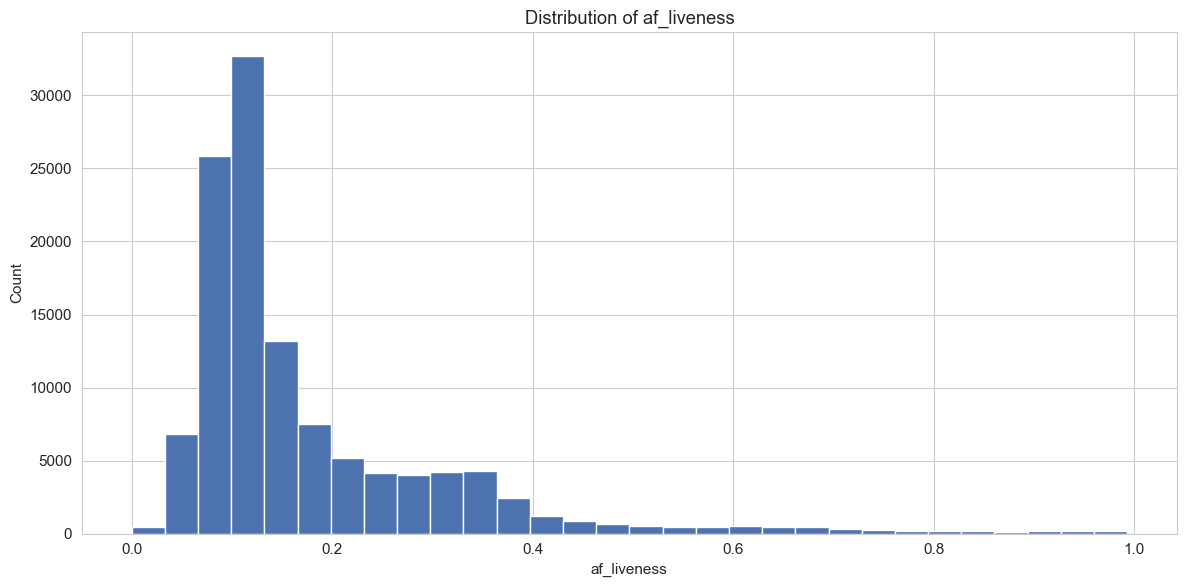

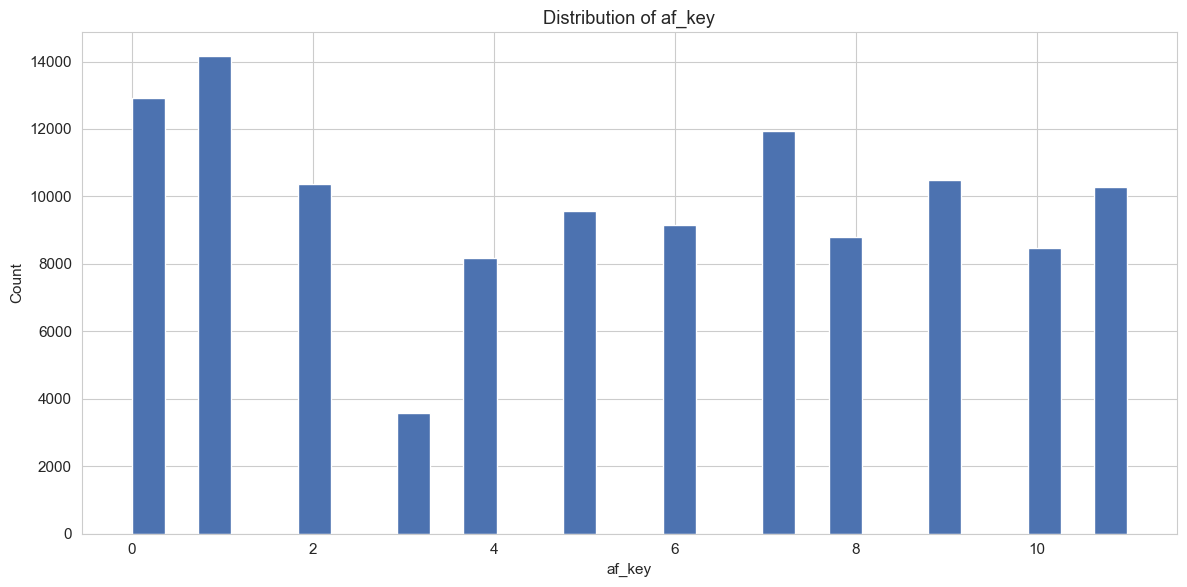

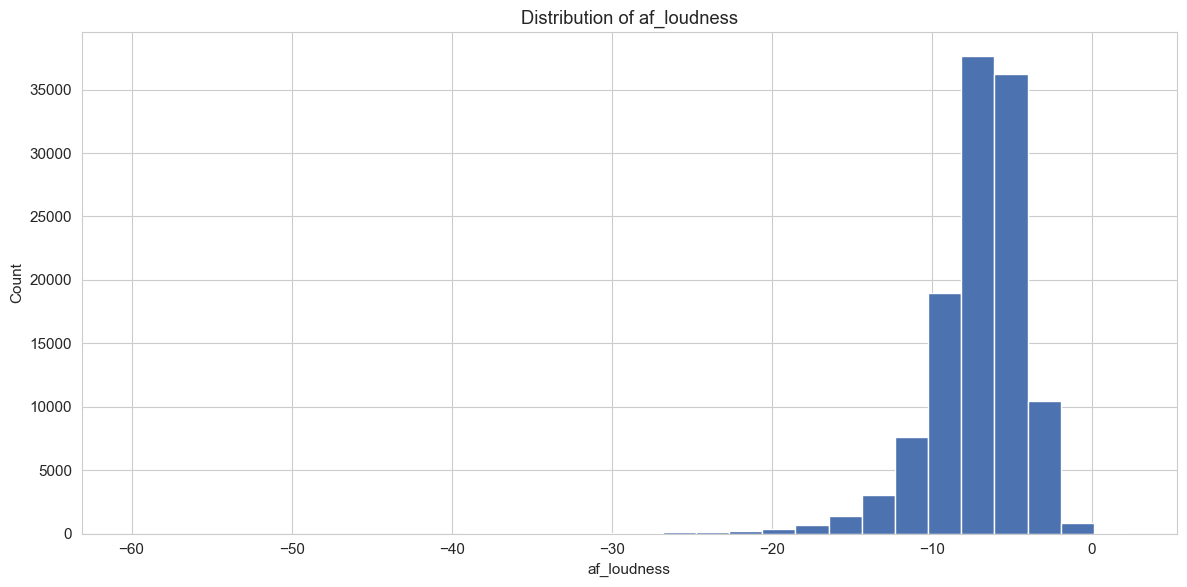

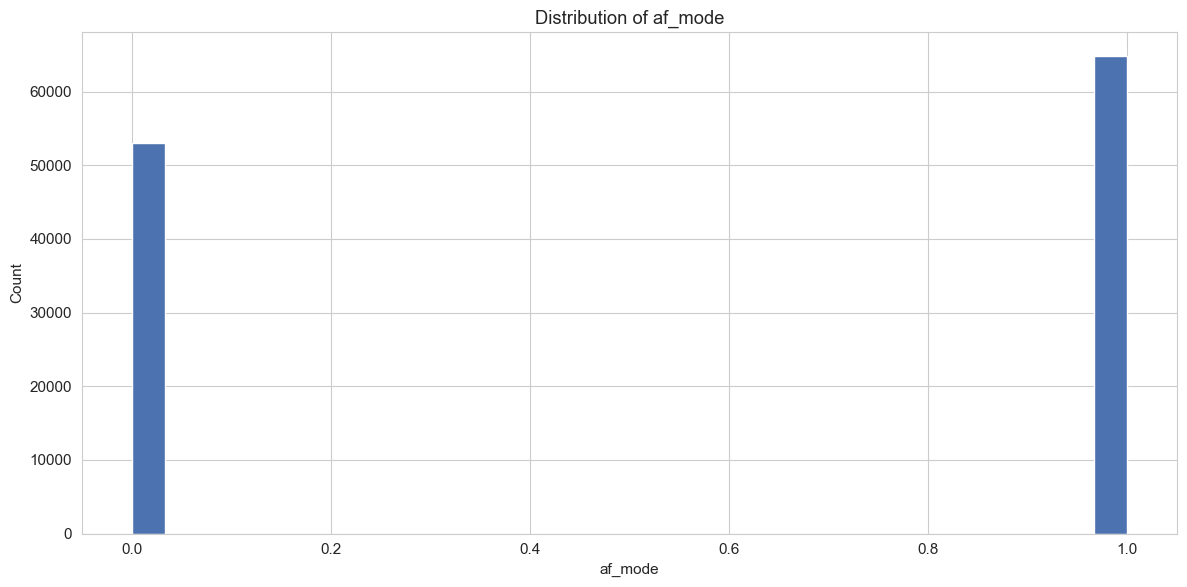

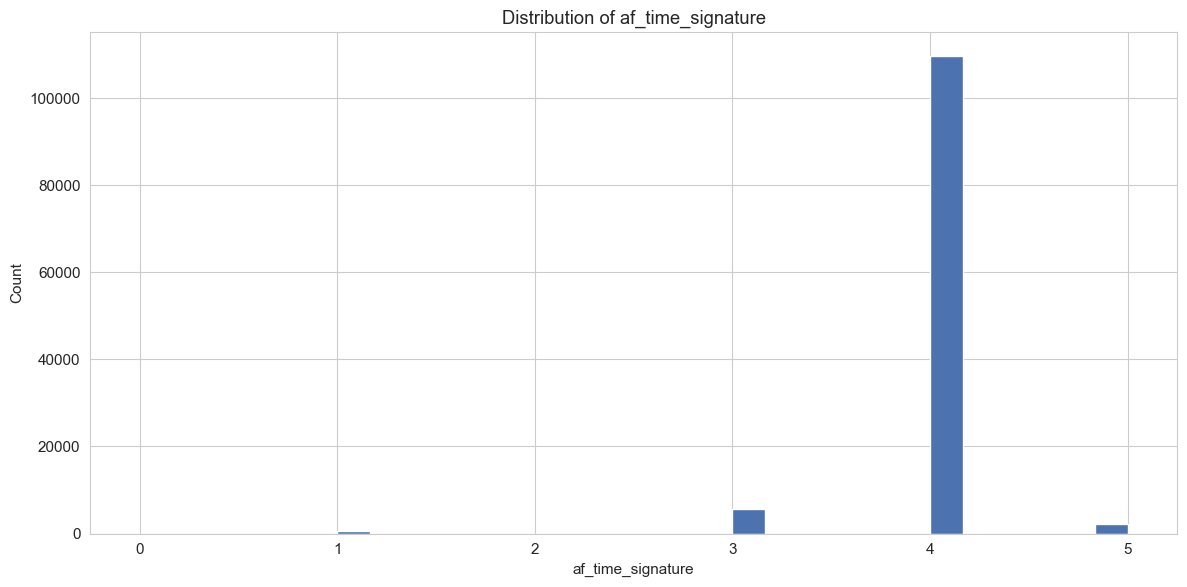

In [75]:
# Visualize the distribution of all 12 audio features across tracks.
# The first 8 are the core continuous features.
# The last 4 (key, loudness, mode, time_signature) are additional retained
# audio features with known limitations that the model will evaluate directly.

for col in audio_feature_cols_all:
    plot_hist(
        track_audio_df[col].dropna(),
        bins=30,
        title=f"Distribution of {col}",
        xlabel=col
    )


**Findings**

- **Danceability and energy are left-skewed toward high values**  
  Both `af_danceability` and `af_energy` show bell-shaped distributions centered around 0.65–0.75, with very few tracks below 0.2. Charting songs are overwhelmingly energetic and danceable, reflecting the dominance of pop, urban, and electronic genres in global charts.

- **Valence is approximately normally distributed**  
  `af_valence` is the most symmetric of all audio features, with a broad distribution centered around 0.35–0.55 and a gentle taper on both ends. Charting songs span the full emotional spectrum from sad/dark to happy/upbeat, with no strong skew in either direction.

- **Tempo clusters around 80–140 BPM**  
  The `af_tempo` distribution is roughly unimodal with a sharp peak around 120 BPM and secondary concentrations around 90–100 and 140–150 BPM, reflecting the prevalence of pop and hip-hop tempos. A moderate right tail extends to 200+ BPM, likely capturing double-time BPM detection by Spotify's algorithm.

- **Acousticness is strongly right-skewed**  
  The vast majority of charting songs have very low acousticness (peak near 0.0), with a long exponentially declining tail. Charting music is predominantly produced and electronic rather than acoustic, though a meaningful minority of tracks have mid-to-high acousticness values.

- **Speechiness is heavily concentrated near zero**  
  `af_speechiness` peaks sharply between 0.03–0.07, with very few tracks exceeding 0.4. Almost all charting songs are primarily musical rather than spoken-word, though the tail captures rap and hip-hop tracks with higher speech content.

- **Instrumentalness is near-zero for virtually all tracks**  
  The `af_instrumentalness` distribution is an extreme spike at zero — over 100,000 tracks have values close to 0, with essentially no tracks above 0.1. Charting songs are almost exclusively vocal, making this feature effectively a near-constant.

- **Liveness is right-skewed with a peak around 0.1**  
  Most tracks score low on liveness (0.05–0.15), indicating they are studio recordings rather than live performances. The long right tail captures a small subset of live recordings that reached the charts.

- **Key is roughly uniformly distributed across 12 pitch classes**  
  `af_key` takes integer values from 0 (C) to 11 (B). The distribution is roughly uniform with a slight peak at 1 (C♯/D♭) and a notable dip at 3 (D♯/E♭). Since key is a categorical variable with no natural ordering — C is not "higher" or "lower" than G in a musically meaningful sense — it cannot be meaningfully interpreted by linear models as a continuous feature. Tree-based models can split on integer-encoded key values and will determine whether pitch class carries any signal for cross-border diffusion.

- **Loudness is tightly concentrated with a long left tail**  
  `af_loudness` (in dB) is heavily concentrated between -8 and -4 dB, with a sharp peak around -5 to -6 dB reflecting industry-standard loudness normalization. A long left tail extends to -60 dB, capturing quieter or more dynamic tracks. The narrow concentration of the bulk of the distribution means loudness has limited variance across typical charting songs, though the tail may carry some signal. Retained for modeling — tree-based models will assess whether loudness adds information beyond what energy already captures.

- **Mode is a binary variable with a majority-major split**  
  `af_mode` takes only two values: 1 (major) and 0 (minor). Approximately 55% of charting tracks are in major key and 45% in minor. As a binary feature, it captures a broad musical characteristic but is not expected to be a strong predictor of cross-border diffusion on its own. Retained for the model to evaluate.

- **Time signature is near-constant at 4/4**  
  `af_time_signature` is overwhelmingly 4 (4/4 time), with only small counts at 3 (3/4 or 6/8) and 5 (5/4), and negligible representation at 1 or 0. This near-zero variance makes it unlikely to be informative, but it is retained and the model will confirm.

- **Audio features are track-level constants — their signal is indirect**  
  Since audio features do not vary across (song, target_country) pairs, they can only contribute predictive signal if certain audio profiles systematically predict cross-border success regardless of target market. All 12 audio features are carried forward to the modeling dataset. Several (`af_instrumentalness`, `af_mode`, `af_time_signature`) have near-zero variance or categorical structure that limits their expected contribution, but tree-based models handle these gracefully and SHAP analysis will reveal whether any carry marginal signal in combination with other features.

## 4.3 Artist Prior Chart Success

**Note**: Only tracks whose first chart date is strictly before the current song's first chart date are counted, ensuring no future information enters the feature at day 0.

In [76]:
# Create one row per track with the artist and the song's first chart date

q("""
CREATE OR REPLACE VIEW track_first_artist_snapshot AS
SELECT
    track_id,
    artist,
    MIN(observation_date) AS first_chart_date
FROM local_top200
GROUP BY track_id, artist
""")

,Count


In [77]:
# Count how many distinct tracks the same artist charted with before the current track to analyze whether prior artist presence on the charts is associated with faster or wider diffusion of new songs, which could indicate a fanbase effect or increased promotional support for artists with established chart success

artist_prior_df = q("""
SELECT
    curr.track_id,
    curr.artist,
    COUNT(DISTINCT prev.track_id) AS artist_prior_tracks
FROM track_first_artist_snapshot curr
LEFT JOIN track_first_artist_snapshot prev
  ON curr.artist = prev.artist
 AND prev.first_chart_date < curr.first_chart_date
GROUP BY curr.track_id, curr.artist
""")

artist_prior_df.head()

,track_id,artist,artist_prior_tracks
0,4IU318wTQZRXcTRLd3JwAE,R-chord,7
1,6Ij25Zxb0QIOP9rb8vq0pb,Yasin,35
2,3rdfHQ7LIHPcbKMPOed63X,Rkomi,21
3,0ByK3Z3aBH8Qv8f36S1ZXf,Natnael,2
4,1UN5tnFYauSOF1X8aDjEo2,Wanakin,4


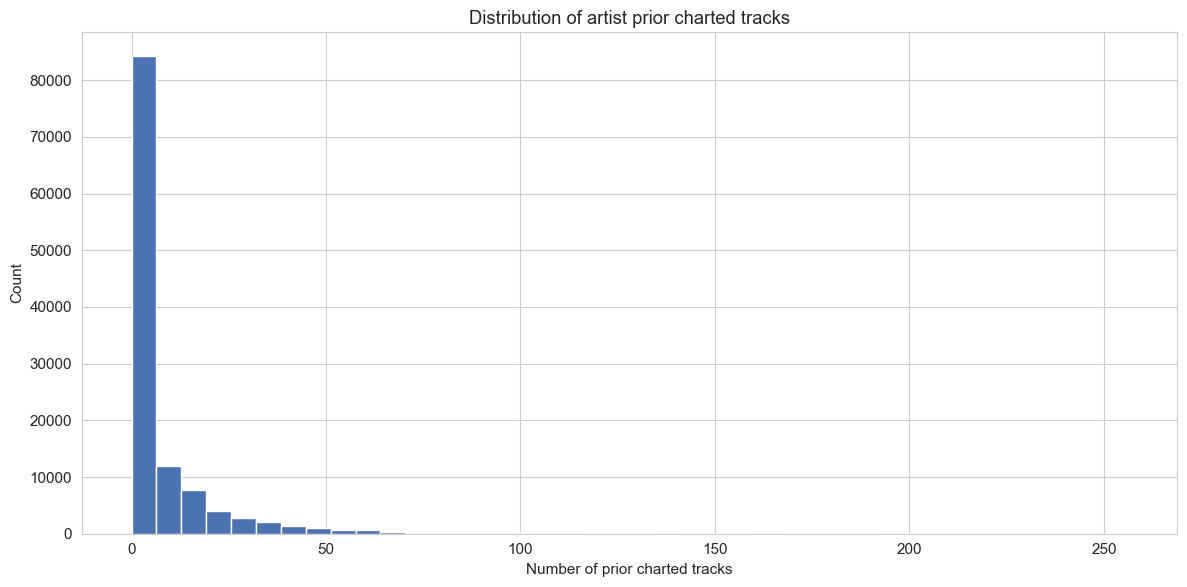

In [78]:
plot_hist(
    artist_prior_df["artist_prior_tracks"],
    bins=40,
    title="Distribution of artist prior charted tracks",
    xlabel="Number of prior charted tracks"
)

**Findings**

- **The distribution is extremely right-skewed**  
  The vast majority of tracks are released by artists with fewer than 10 prior charted tracks globally, with the mode at 0. The distribution drops sharply after 0 and has a very long tail extending beyond 250 prior tracks.

- **Most charting songs come from new or emerging artists**  
  The spike at 0 prior tracks (~85,000 songs) indicates that a large share of the dataset consists of artists making their first chart appearance, reflecting natural chart turnover.

- **Log transformation may be warranted**  
  Given the extreme skew, the raw prior track count may need to be log-transformed before being fed into logistic regression. Tree-based models can handle the skew directly.

## 4.4 Collaboration, Explicit Content, and Release Timing

In [79]:
# Create a dataset with one row per track that includes the track's audio features, the artist, the release date, the first chart date, and the 60-day spread

release_context_df = q("""
WITH first_track_dates AS (
    SELECT
        track_id,
        MIN(observation_date) AS first_chart_date
    FROM local_top200
    GROUP BY 1
),
first_track_rows AS (
    SELECT
        l.track_id,
        MIN(l.title) AS title,
        MIN(l.artist) AS artist,
        MIN(l.explicit) AS explicit,
        MIN(l.release_date) AS release_date,
        ftd.first_chart_date AS observation_date
    FROM local_top200 l
    JOIN first_track_dates ftd
      ON l.track_id = ftd.track_id
     AND l.observation_date = ftd.first_chart_date
    GROUP BY 1, 6
),
spread_60d AS (
    SELECT
        sfge.track_id,
        COUNT(DISTINCT CASE
            WHEN scfe.first_entry_date > sfge.first_global_entry_date
             AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
            THEN scfe.region
        END) AS additional_countries_60d
    FROM song_first_global_entry sfge
    LEFT JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
    GROUP BY 1
)
SELECT
    ftr.track_id,
    ftr.title,
    ftr.artist,
    ftr.explicit,
    ftr.release_date,
    ftr.observation_date,
    DATEDIFF('day', ftr.release_date, ftr.observation_date) AS days_since_release_at_first_chart,
    CASE
        WHEN LOWER(ftr.artist) LIKE '%feat.%'
          OR LOWER(ftr.artist) LIKE '% ft.%'
          OR LOWER(ftr.artist) LIKE '%&%'
          OR LOWER(ftr.artist) LIKE '%,%'
        THEN 1 ELSE 0
    END AS collaboration_flag,
    EXTRACT(DOW FROM ftr.release_date) AS release_day_of_week,
    s60.additional_countries_60d
FROM first_track_rows ftr
LEFT JOIN spread_60d s60
  ON ftr.track_id = s60.track_id
""")

release_context_df.head()

,track_id,title,artist,explicit,release_date,observation_date,days_since_release_at_first_chart,collaboration_flag,release_day_of_week,additional_countries_60d
0,1lsBTdE6MGsKeZCD6llNu7,Done for Me (feat. Kehlani),Charlie Puth,0,2018-05-11,2018-05-11,0,0,5,10
1,4vKqFdyIEKkbXdAdGESLJq,恋におちたら,Crystal Kay,0,2006-02-22,2019-03-12,4766,0,3,0
2,3mN2DtljBhnrIpc3Nu2pJ8,Déjate Querer,"Lalo Ebratt, Sebastian Yatra, Yera, Trapical M...",0,2019-02-28,2019-03-01,1,1,4,2
3,0lbhKycRyqkOMKZ6thzfU4,Mi Error - Remix,"Eladio Carrion, Zion & Lennox, Wisin & Yandel,...",0,2019-11-18,2019-11-18,0,1,1,12
4,3l6Dc2DvpzEXJxnRTX5JUd,Nocturna - Remix,"Nio Garcia, Bryant Myers, Lenny Tavárez, Miky ...",1,2020-02-28,2020-02-29,1,1,5,1


In [80]:
# Distribution of collaboration flag, explicit status and release timing

collab_dist_df = q("""
SELECT
    collaboration_flag,
    COUNT(*) AS n_tracks,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM release_context_df
GROUP BY 1
ORDER BY 1
""")

explicit_dist_df = q("""
SELECT
    CASE
        WHEN explicit = 1 THEN 'explicit'
        WHEN explicit = 0 THEN 'non-explicit'
        ELSE 'unknown'
    END AS explicit_label,
    COUNT(*) AS n_tracks,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM release_context_df
GROUP BY 1
ORDER BY 1
""")

release_dow_dist_df = q("""
SELECT
    release_day_of_week,
    COUNT(*) AS n_tracks,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM release_context_df
WHERE release_day_of_week IS NOT NULL
GROUP BY 1
ORDER BY 1
""")

display(collab_dist_df)
display(explicit_dist_df)
display(release_dow_dist_df)

,collaboration_flag,n_tracks,pct
0,0,85614,72.63
1,1,32262,27.37


,explicit_label,n_tracks,pct
0,explicit,36944,31.34
1,non-explicit,80932,68.66


,release_day_of_week,n_tracks,pct
0,0,3825,3.31
1,1,8783,7.61
2,2,8161,7.07
3,3,10696,9.26
4,4,15863,13.74
5,5,64243,55.63
6,6,3905,3.38


In [81]:
# Distribution of days since release at first chart appearance

print(release_context_df["days_since_release_at_first_chart"].describe())

count       115476.0
mean      529.318179
std      2016.055227
min          -1624.0
25%              0.0
50%              1.0
75%             21.0
max          44421.0
Name: days_since_release_at_first_chart, dtype: Float64


**Findings**

- **Most tracks are solo releases**  
  72.6% of tracks (85,614) are solo releases, while 27.4% (32,262) are collaborations featuring at least one additional artist. Collaborations are a meaningful minority but far from the norm.

- **Explicit content accounts for roughly a third of charting tracks**  
  31.3% of tracks (36,944) are marked explicit, while 68.7% (80,932) are non-explicit. This split is plausible given the dominance of pop and hip-hop in global charts.

- **Friday releases dominate overwhelmingly**  
  55.6% of all charting tracks (64,243) were released on a Friday (day 5), reflecting the music industry's standard global release day. No other day comes close — Thursday is second at 9.3% and Saturday third at 7.6%. Sunday (3.4%) and Monday (3.3%) are the least common release days.

- **Most songs chart very close to their release date**  
  The median days since release at first chart appearance is just 1 day, and the 25th percentile is 0 (same day). However the mean is 529 days and the max is 44,421 days, indicating a long right tail of catalogue tracks that chart long after their original release. The negative minimum (-1,624 days) suggests some release date data inconsistencies that should be handled during feature engineering.

## 4.5 Cultural Distance

In [82]:
# Explore the available cultural distance variables in the dataset

distance_cols = [
    "cultural_distance_mean",
    "cultural_distance_median",
    "cultural_distance_min",
    "cultural_distance_max",
    "cultural_distance_count"
]

distance_avgs_df = q("""
SELECT
    AVG(cultural_distance_mean) AS cultural_distance_mean,
    AVG(cultural_distance_median) AS cultural_distance_median,
    AVG(cultural_distance_min) AS cultural_distance_min,
    AVG(cultural_distance_max) AS cultural_distance_max,
    AVG(cultural_distance_count) AS cultural_distance_count
FROM local_top200
""")

distance_avgs_df

,cultural_distance_mean,cultural_distance_median,cultural_distance_min,cultural_distance_max,cultural_distance_count
0,1.968211,1.75626,0.124204,5.84491,118.0


In [83]:
# Distribution of cultural distance values across charting observations

distance_dist_df = q("""
SELECT
    MIN(cultural_distance_min) AS min_cultural_distance,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY cultural_distance_min) AS p25,
    PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY cultural_distance_min) AS median,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cultural_distance_min) AS p75,
    MAX(cultural_distance_min) AS max_cultural_distance,
    AVG(cultural_distance_min) AS avg_cultural_distance_min,
    STDDEV(cultural_distance_min) AS std_cultural_distance_min
FROM local_top200
WHERE cultural_distance_min IS NOT NULL
""")

display(distance_dist_df)

,min_cultural_distance,p25,median,p75,max_cultural_distance,avg_cultural_distance_min,std_cultural_distance_min
0,0.005,0.044,0.097,0.151,0.87,0.124204,0.129217


In [84]:
# Distribution of cultural distance min across countries

distance_by_country_df = q("""
SELECT DISTINCT
    region,
    AVG(cultural_distance_min) AS avg_min_distance,
    AVG(cultural_distance_mean) AS avg_mean_distance
FROM local_top200
WHERE cultural_distance_min IS NOT NULL
GROUP BY 1
ORDER BY avg_min_distance ASC
""")

display(distance_by_country_df.head(10))
display(distance_by_country_df.tail(10))
display(distance_by_country_df.describe())

,region,avg_min_distance,avg_mean_distance
0,Norway,0.005,3.413161
1,Iceland,0.005,3.400170
2,Romania,0.017,1.386525
3,Peru,0.026,1.212212
4,Indonesia,0.033,1.545390
5,Switzerland,0.033,2.435508
6,Germany,0.033,2.244204
7,Bulgaria,0.034,1.070449
8,Turkey,0.034,1.007898
9,Egypt,0.036,1.337915


,region,avg_min_distance,avg_mean_distance
45,Denmark,0.194,4.483559
46,Sweden,0.194,4.275703
47,Italy,0.203,1.505754
48,Luxembourg,0.206,1.369492
49,Philippines,0.216,1.873627
50,Malaysia,0.236,1.853915
51,Singapore,0.282,2.270627
52,Austria,0.386,3.761958
53,Israel,0.426,2.475152
54,Slovakia,0.870,3.826924


,avg_min_distance,avg_mean_distance
count,55.000000,55.000000
mean,0.123327,1.924303
std,0.134301,0.888700
min,0.005000,0.883881
25%,0.042500,1.344869
50%,0.092000,1.615661
75%,0.149500,2.258241
max,0.870000,4.483559


**Findings**

- **Cultural distance minimum is heavily right-skewed with a low median**  
  The median minimum cultural distance across charting observations is just 0.097, with a 25th percentile of 0.044 and a 75th percentile of 0.151. The maximum is 0.87, meaning even the most culturally isolated market in the dataset still has at least one reasonably proximate neighbour. The average of 0.124 and standard deviation of 0.129 confirm a right-skewed distribution concentrated at low values.

- **Iceland and Norway are the most culturally proximate markets**  
  Both have an average minimum cultural distance of just 0.005, meaning they always have at least one very close cultural neighbour charting simultaneously. Romania (0.017), Peru (0.026), and Germany and Switzerland (both 0.033) follow closely.

- **Slovakia and Israel are the most culturally isolated markets**  
  Slovakia has an average minimum cultural distance of 0.870 — by far the highest in the dataset — followed by Israel (0.426) and Austria (0.386). These markets tend to chart songs without culturally similar neighbours present, which may make cross-border diffusion harder to predict for them.

- **There is meaningful variance across markets**  
  The range from 0.005 (Iceland) to 0.870 (Slovakia) indicates that cultural distance carries genuine cross-market variation. This variance should translate into predictive signal at the pair level in the modeling dataset, where `cultural_dist_min` is computed per (song, target_country) pair.

## 4.6 Language Similarity

In [85]:
# Identify how many unique language groups exist across charting countries

language_groups_df = q("""
SELECT
    country_official_language,
    COUNT(DISTINCT region) AS n_countries
FROM local_top200
WHERE country_official_language IS NOT NULL
GROUP BY 1
ORDER BY n_countries DESC
""")

language_groups_df

,country_official_language,n_countries
0,Spanish,12
1,English,3
2,Arabic,3
3,Portuguese,2
4,German,2
5,"Guaraní, Spanish",2
6,"Afrikaans, English, Southern Ndebele, Northern...",1
7,"German, French, Luxembourgish",1
8,"English, Chinese",1
9,"French, Swiss German, Italian, Romansh",1


In [86]:
# Summary statistics for language coverage across charting markets

language_coverage_df = q("""
SELECT
    COUNT(DISTINCT region) AS total_markets,
    COUNT(DISTINCT CASE WHEN country_official_language IS NOT NULL THEN region END) AS markets_with_language,
    COUNT(DISTINCT country_official_language) AS unique_language_strings,
    SUM(CASE WHEN country_official_language IS NULL OR TRIM(country_official_language) = '' 
        THEN 1 ELSE 0 END) AS missing_rows,
    ROUND(100.0 * SUM(CASE WHEN country_official_language IS NULL OR TRIM(country_official_language) = '' 
        THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_missing
FROM local_top200
""")

display(language_coverage_df)

,total_markets,markets_with_language,unique_language_strings,missing_rows,pct_missing
0,68,67,49,357234.0,1.79


In [87]:
# How many markets share a language with at least one other market
# (exact string match — underestimates true overlap as noted)

language_sharing_df = q("""
WITH language_counts AS (
    SELECT
        country_official_language,
        COUNT(DISTINCT region) AS n_countries
    FROM local_top200
    WHERE country_official_language IS NOT NULL
    GROUP BY 1
)
SELECT
    CASE
        WHEN n_countries = 1 THEN 'unique to one country'
        WHEN n_countries BETWEEN 2 AND 5 THEN '2-5 countries'
        ELSE '6+ countries'
    END AS language_sharing_bucket,
    COUNT(*) AS n_language_strings,
    SUM(n_countries) AS n_markets_covered
FROM language_counts
GROUP BY 1
ORDER BY n_markets_covered DESC
""")

display(language_sharing_df)

,language_sharing_bucket,n_language_strings,n_markets_covered
0,unique to one country,43,43.0
1,2-5 countries,5,12.0
2,6+ countries,1,12.0


**Findings**

- **Language data is available for 67 of 69 local markets**  
  Only 1 market is missing language data entirely, and overall missingness is just 1.79% of rows (357,234 out of ~20M). Language coverage is therefore near-complete and reliable as a feature.

- **49 unique language strings across 67 markets**  
  The high number of unique strings (49 for 67 markets) reflects the complexity of multi-language countries — Belgium, Switzerland, Singapore, and others each have unique official language combinations that do not match any other country exactly.

- **Most language strings are unique to a single country**  
  43 of the 49 language strings (87.8%) map to exactly one country, covering 43 markets. Only 6 language strings are shared across multiple markets, covering 24 markets total.

- **The only large same-language group is Spanish**  
  The single "6+ countries" bucket covers 12 markets under the exact string "Spanish". The "2–5 countries" bucket covers 5 language strings across 12 markets (Arabic with 3, English with 3, Portuguese with 2, German with 2, and Guaraní+Spanish with 2).

- **Exact string matching severely underestimates true linguistic proximity**  
  With 43 out of 49 strings unique to one country, exact matching would classify most country pairs as linguistically unrelated even when they share a major language. This likely needs to be addressed via primary-language matching with LIKE overlap checks.


## 4.7 Implications for Modeling and Business Perspective

**Modeling implications**

- **Spatial features are expected to dominate.** Debut rank and first-day country footprint show the clearest relationships with subsequent spread across all feature groups. The 62 per-country rank columns (after excluding low-coverage markets), which encode both presence and rank strength simultaneously, are expected to be the most important feature group in the model.

- **Audio features are weak individual predictors but all 12 are retained.** The distributions confirm that charting songs are predominantly energetic, danceable, and vocal — but with limited variance across the full dataset. Several features (`af_instrumentalness`, `af_mode`, `af_time_signature`) have near-zero variance, and others (`af_key`) are categorical in nature. All 12 are carried forward to the modeling dataset — tree-based models handle low-variance and categorical features gracefully, and SHAP analysis will confirm which, if any, carry marginal signal in combination with stronger features.

- **Artist history adds a meaningful second layer.** The global prior chart count is extremely right-skewed with most artists having zero prior tracks, while a small elite has 250+. The extreme skew means log transformation should be considered for logistic regression, while tree-based models can handle the raw values directly.

- **Collaboration and release timing are structurally important features.** Friday releases account for 55.6% of all charting tracks, making release day a meaningful signal. Explicit content covers 31.3% of tracks — a large enough share to carry signal. Both features are cleanly available and correctly computed.

- **Language similarity requires better engineering before use.** With 43 of 49 language strings unique to a single country, exact string matching classifies most country pairs as linguistically unrelated even when they share a major language. Matching using LIKE overlap checks must be implemented in the feature engineering pipeline for this feature to be meaningful.

- **Cultural distance has sufficient variance to be informative at the pair level.** The minimum cultural distance ranges from 0.005 (Iceland, Norway) to 0.870 (Slovakia), confirming meaningful cross-market variation. The pair-level `cultural_dist_min` feature is expected to be more discriminating than the country-level aggregates examined here.

**Business implications**

- **Artist market entry strategy is directly actionable.** The country-specific prior presence breakdown shows that over a third of artist-country pairs involve an artist entering a market with no prior footprint. For labels, this is the highest-risk promotional investment — and the one where the model's prediction is most valuable.

- **Friday releases are the standard for a reason.** With 55.6% of charting tracks released on Friday, the industry's global release day convention is clearly visible in the data. Labels deviating from this pattern should be aware of the potential spread penalty.

- **Cultural isolation matters for market strategy.** Slovakia (0.870), Israel (0.426), and Austria (0.386) are the most culturally isolated markets in the dataset. Songs breaking into these markets are doing so without the benefit of cultural proximity — a signal that warrants higher confidence thresholds when the model flags these as likely targets.

# Part V — Bivariate Analysis: Features vs 60-Day Spread

This section tests each feature group directly against the binary 60-day spread outcome, whether a song entered at least one additional country within 60 days of its global debut. Unlike Part IV which examined marginal distributions, every analysis here is conditioned on the spread outcome to assess predictive signal. All analyses remain at the song level; pair-level evaluation will follow in the modeling notebook via SHAP analysis.

## 5.1 Initial Rank vs 60-Day Spread

In [88]:
# Compare the distribution of best initial rank for songs that spread vs did not spread
# within 60 days at the song level

rank_spread_bivariate_df = q("""
WITH best_initial_rank AS (
    SELECT
        l.track_id,
        MIN(l.rank) AS best_initial_rank
    FROM local_top200 l
    JOIN song_first_global_entry sfge
      ON l.track_id = sfge.track_id
     AND l.observation_date = sfge.first_global_entry_date
    GROUP BY 1
),
spread_60d AS (
    SELECT
        sfge.track_id,
        CASE
            WHEN COUNT(DISTINCT CASE
                WHEN scfe.first_entry_date > sfge.first_global_entry_date
                 AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
                THEN scfe.region
            END) > 0 THEN 1 ELSE 0
        END AS did_spread_60d
    FROM song_first_global_entry sfge
    LEFT JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
    GROUP BY 1
)
SELECT
    CASE
        WHEN best_initial_rank BETWEEN 1 AND 10 THEN '1-10'
        WHEN best_initial_rank BETWEEN 11 AND 25 THEN '11-25'
        WHEN best_initial_rank BETWEEN 26 AND 50 THEN '26-50'
        WHEN best_initial_rank BETWEEN 51 AND 100 THEN '51-100'
        ELSE '101-200'
    END AS rank_bucket,
    AVG(s.did_spread_60d) AS spread_rate,
    COUNT(*) AS n_tracks
FROM best_initial_rank r
JOIN spread_60d s
  ON r.track_id = s.track_id
GROUP BY 1
ORDER BY MIN(best_initial_rank)
""")

rank_spread_bivariate_df

,rank_bucket,spread_rate,n_tracks
0,1-10,0.181715,7033
1,11-25,0.121418,8409
2,26-50,0.124425,12168
3,51-100,0.098708,27485
4,101-200,0.096685,62781


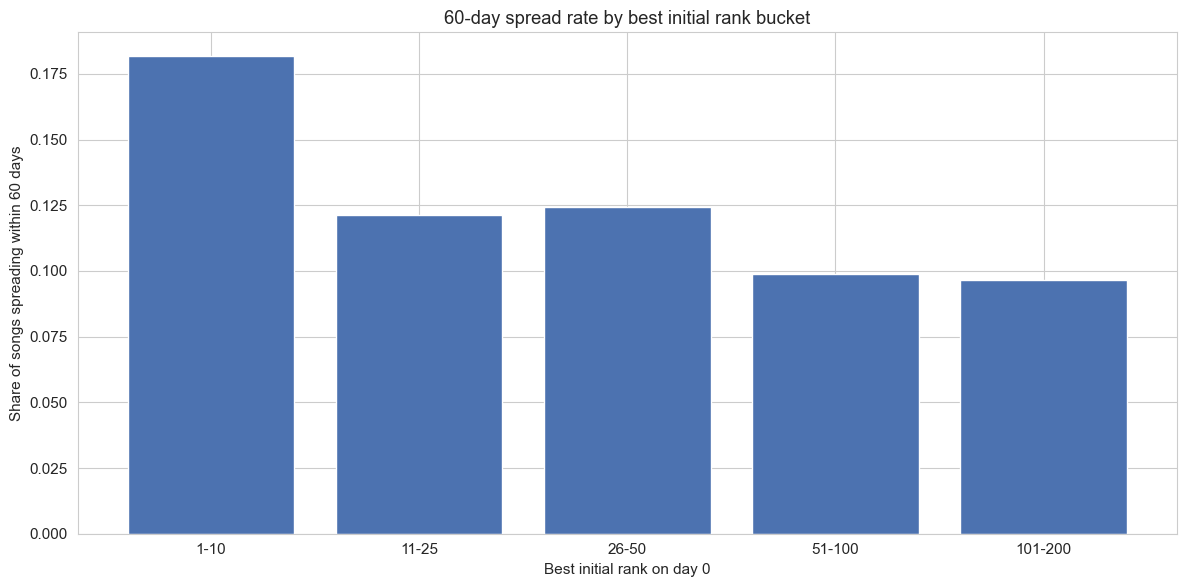

In [89]:
plot_bar(
    rank_spread_bivariate_df,
    x="rank_bucket",
    y="spread_rate",
    title="60-day spread rate by best initial rank bucket",
    xlabel="Best initial rank on day 0",
    ylabel="Share of songs spreading within 60 days",
    rotation=0
)

**Findings**

- **Higher initial rank is associated with a meaningfully higher spread rate**  
  Songs debuting in positions 1–10 spread to at least one additional country within 60 days at a rate of 18.2%, nearly double the rate of songs debuting in positions 101–200 (9.7%). The relationship is broadly monotonic, confirming that debut rank strength is a genuine predictor of cross-border diffusion.

- **The signal is concentrated in the top 50 positions**  
  The spread rate drops sharply from 18.2% (rank 1–10) to 12.1% (rank 11–25) and then plateaus — positions 51–100 (9.9%) and 101–200 (9.7%) are nearly indistinguishable. This suggests the rank feature's discriminating power is concentrated in the top 50 positions, with limited additional signal below rank 50.

- **The 11–25 and 26–50 buckets show a minor inversion**  
  Songs debuting in positions 26–50 (12.4%) marginally outperform those in positions 11–25 (12.1%). This is consistent with what was seen in section 4.2 and likely reflects sampling noise within rank buckets rather than a genuine non-linearity.

- **Initial rank is a confirmed feature for modeling**  
  The spread rate gap between the top and bottom rank buckets is large enough to be practically meaningful. Combined with the per-country rank columns which encode this signal across all 62 modeling markets simultaneously, rank strength at day 0 is confirmed as a key feature group.

## 5.2 Multi-Country Launch Patterns vs 60-Day Spread

In [90]:
# For songs that debut in multiple countries, check whether the number of countries they debut in on the first day is associated with how many additional countries they enter within 60 days, to see if there's a relationship between initial multi-country exposure and later spread beyond the debut footprint

launch_pattern_df = q("""
WITH first_day_stats AS (
    SELECT
        scfe.track_id,
        COUNT(*) AS n_first_day_countries
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
     AND scfe.first_entry_date = sfge.first_global_entry_date
    GROUP BY 1
),
spread_60d AS (
    SELECT
        sfge.track_id,
        COUNT(DISTINCT CASE
            WHEN scfe.first_entry_date > sfge.first_global_entry_date
             AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
            THEN scfe.region
        END) AS additional_countries_60d
    FROM song_first_global_entry sfge
    LEFT JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
    GROUP BY 1
)
SELECT
    fds.n_first_day_countries,
    AVG(s60.additional_countries_60d) AS avg_additional_countries_60d,
    COUNT(*) AS n_songs
FROM first_day_stats fds
JOIN spread_60d s60
  ON fds.track_id = s60.track_id
GROUP BY 1
ORDER BY 1
""")

launch_pattern_df.tail(15)


,n_first_day_countries,avg_additional_countries_60d,n_songs
53,54,1.615385,26
54,55,1.516129,31
55,56,1.400000,30
56,57,1.000000,36
57,58,2.000000,28
58,59,0.937500,16
59,60,1.823529,17
60,61,2.000000,16
61,62,1.421053,19
62,63,1.315789,19


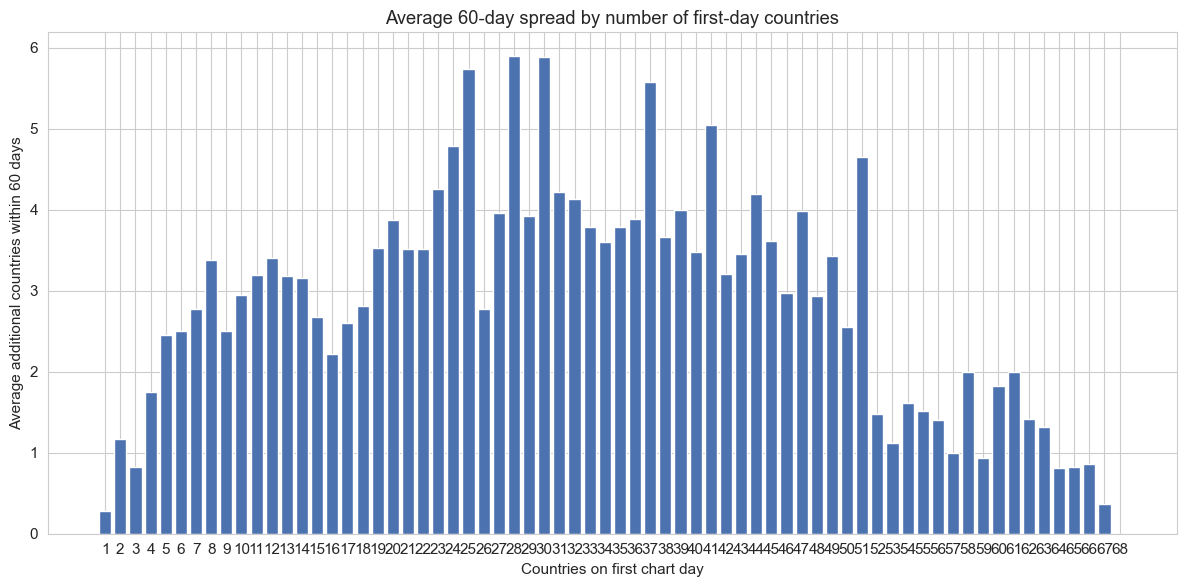

In [91]:
plot_bar(
    launch_pattern_df,
    x="n_first_day_countries",
    y="avg_additional_countries_60d",
    title="Average 60-day spread by number of first-day countries",
    xlabel="Countries on first chart day",
    ylabel="Average additional countries within 60 days",
    rotation=0
)


**Findings**

- **The relationship between debut footprint and spread is non-linear**  
  Rather than a simple monotonic increase, the plot reveals an inverted-U shape. Spread increases as first-day country count grows from 1 to roughly 25–30 countries, peaks there, and then gradually declines for songs debuting in 50+ markets simultaneously.

- **Songs debuting in 1 country spread the least**  
  Single-country debuts average close to 0 additional countries within 60 days, consistent with the finding in section 2.4 that only 8.6% of single-country debuts ever spread at all.

- **The sweet spot is a mid-range debut footprint**  
  Songs debuting in approximately 20–30 countries on day 0 show the highest average subsequent spread, reaching peaks of around 5–6 additional countries within 60 days. These songs have demonstrated broad initial appeal without already saturating the available market.

- **Near-global debuts have limited remaining room to spread**  
  Songs debuting in 60+ countries simultaneously show sharply declining average spread, approaching 0 for songs debuting in all 69 local markets. This is a ceiling effect — there are simply no remaining target countries to enter. This reinforces the importance of excluding already-charting countries from the target variable in the modeling dataset.


## 5.3 Audio Features vs 60-Day Spread

In [92]:
# Compare distribution of each audio feature for songs that spread vs did not spread
# within 60 days. Includes all 12 audio features for completeness.

audio_spread_df = q("""
WITH spread_60d AS (
    SELECT
        sfge.track_id,
        CASE
            WHEN COUNT(DISTINCT CASE
                WHEN scfe.first_entry_date > sfge.first_global_entry_date
                 AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
                THEN scfe.region
            END) > 0 THEN 1 ELSE 0
        END AS did_spread_60d
    FROM song_first_global_entry sfge
    LEFT JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
    GROUP BY 1
)
SELECT
    s.did_spread_60d,
    AVG(af_danceability) AS avg_danceability,
    AVG(af_energy) AS avg_energy,
    AVG(af_valence) AS avg_valence,
    AVG(af_tempo) AS avg_tempo,
    AVG(af_acousticness) AS avg_acousticness,
    AVG(af_speechiness) AS avg_speechiness,
    AVG(af_instrumentalness) AS avg_instrumentalness,
    AVG(af_liveness) AS avg_liveness,
    AVG(af_key) AS avg_key,
    AVG(af_loudness) AS avg_loudness,
    AVG(af_mode) AS avg_mode,
    AVG(af_time_signature) AS avg_time_signature,
    COUNT(*) AS n_tracks
FROM spread_60d s
JOIN track_audio_df t
  ON s.track_id = t.track_id
GROUP BY 1
ORDER BY 1
""")

audio_spread_df


,did_spread_60d,avg_danceability,avg_energy,avg_valence,avg_tempo,avg_acousticness,avg_speechiness,avg_instrumentalness,avg_liveness,avg_key,avg_loudness,avg_mode,avg_time_signature,n_tracks
0,0,0.666120,0.635101,0.507827,121.579114,0.279739,0.131629,0.026241,0.176664,5.324563,-7.195286,0.547112,3.958235,105280
1,1,0.674912,0.643769,0.516378,121.856595,0.251102,0.115539,0.019852,0.175761,5.276596,-6.448373,0.573277,3.958638,12596


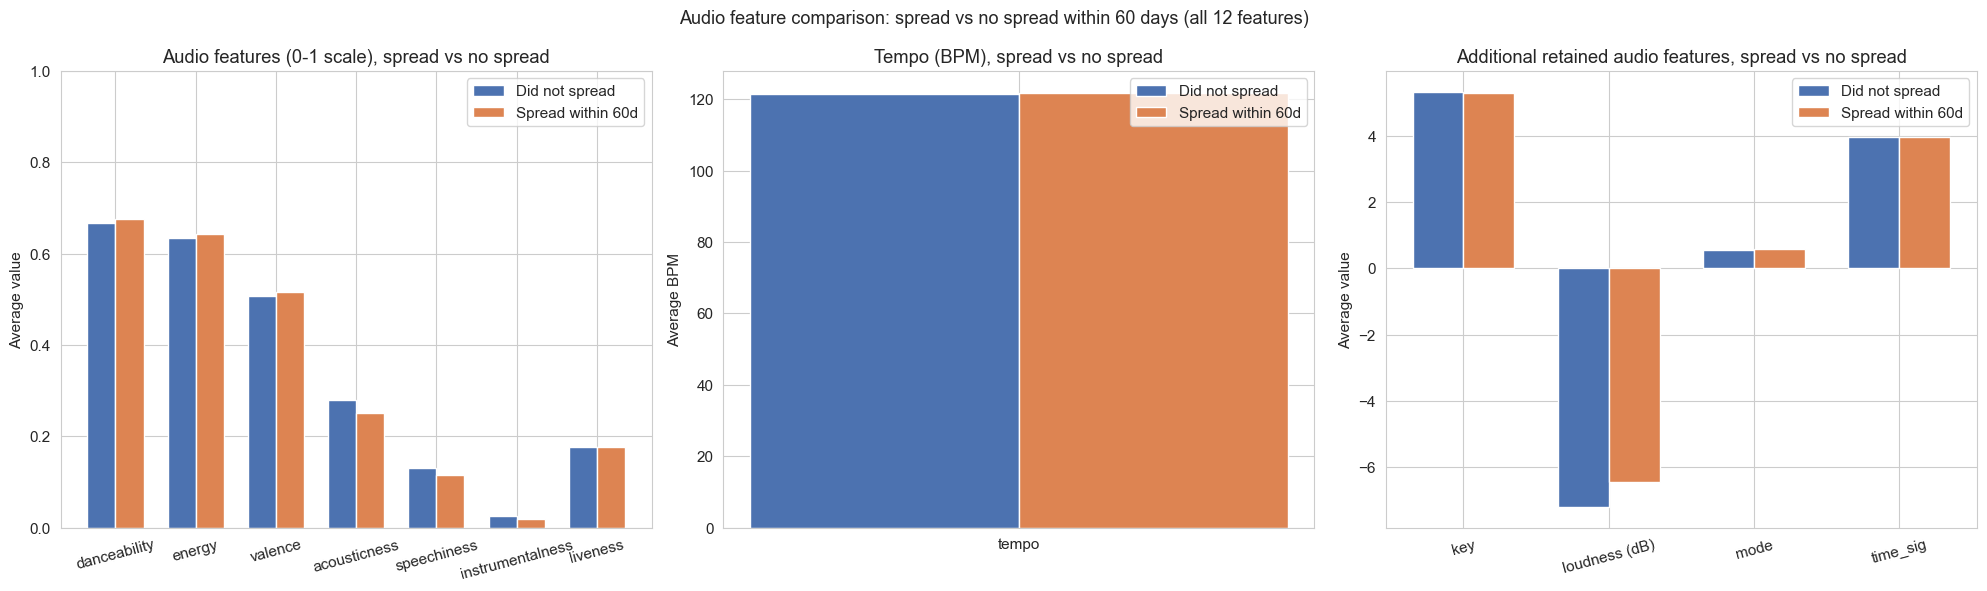

In [93]:
# Plot audio features split into three panels:
# Panel 1: 0-1 scaled features
# Panel 2: tempo separately (0-220 scale)
# Panel 3: additional retained features (key, loudness, mode, time_signature) on separate scales

features_0_1 = [
    "avg_danceability", "avg_energy", "avg_valence",
    "avg_acousticness", "avg_speechiness", "avg_instrumentalness", "avg_liveness"
]
labels_0_1 = [f.replace("avg_", "") for f in features_0_1]

spread_0_1 = audio_spread_df[audio_spread_df["did_spread_60d"] == 1][features_0_1].values[0]
no_spread_0_1 = audio_spread_df[audio_spread_df["did_spread_60d"] == 0][features_0_1].values[0]

spread_tempo = audio_spread_df[audio_spread_df["did_spread_60d"] == 1]["avg_tempo"].values[0]
no_spread_tempo = audio_spread_df[audio_spread_df["did_spread_60d"] == 0]["avg_tempo"].values[0]

# Additional retained features
extra_features = ["avg_key", "avg_loudness", "avg_mode", "avg_time_signature"]
extra_labels = ["key", "loudness (dB)", "mode", "time_sig"]
spread_extra = audio_spread_df[audio_spread_df["did_spread_60d"] == 1][extra_features].values[0]
no_spread_extra = audio_spread_df[audio_spread_df["did_spread_60d"] == 0][extra_features].values[0]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
width = 0.35

# Panel 1: 0-1 features
x = range(len(labels_0_1))
axes[0].bar([i - width/2 for i in x], no_spread_0_1, width, label="Did not spread", color="#4C72B0")
axes[0].bar([i + width/2 for i in x], spread_0_1, width, label="Spread within 60d", color="#DD8452")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels_0_1, rotation=15)
axes[0].set_title("Audio features (0-1 scale), spread vs no spread")
axes[0].set_ylabel("Average value")
axes[0].set_ylim(0, 1)
axes[0].legend()

# Panel 2: tempo
axes[1].bar([0 - width/2], [no_spread_tempo], width, label="Did not spread", color="#4C72B0")
axes[1].bar([0 + width/2], [spread_tempo], width, label="Spread within 60d", color="#DD8452")
axes[1].set_xticks([0])
axes[1].set_xticklabels(["tempo"])
axes[1].set_title("Tempo (BPM), spread vs no spread")
axes[1].set_ylabel("Average BPM")
axes[1].legend()

# Panel 3: additional retained features (different scales)
x3 = range(len(extra_labels))
axes[2].bar([i - width/2 for i in x3], no_spread_extra, width, label="Did not spread", color="#4C72B0")
axes[2].bar([i + width/2 for i in x3], spread_extra, width, label="Spread within 60d", color="#DD8452")
axes[2].set_xticks(list(x3))
axes[2].set_xticklabels(extra_labels, rotation=15)
axes[2].set_title("Additional retained audio features, spread vs no spread")
axes[2].set_ylabel("Average value")
axes[2].legend()

plt.suptitle("Audio feature comparison: spread vs no spread within 60 days (all 12 features)", fontsize=13)
plt.tight_layout()
plt.show()


**Findings**

- **Audio features show minimal separation between spreading and non-spreading songs**  
  Across all 12 audio features, the differences between songs that spread within 60 days and those that do not are extremely small. Spreading songs are marginally more danceable (0.675 vs 0.666), more energetic (0.644 vs 0.635), and slightly more positive in valence (0.516 vs 0.508), but none of these differences are large enough to be practically meaningful on their own.

- **Acousticness and speechiness show the largest relative differences among the 0–1 features**  
  Spreading songs are slightly less acoustic (0.251 vs 0.280) and less speech-heavy (0.116 vs 0.132) than non-spreading songs, suggesting that produced, musical tracks travel more easily across borders than acoustic or spoken-word content. These remain small differences however.

- **Loudness shows the largest absolute gap of all 12 features**  
  Spreading songs are slightly louder on average (-6.45 dB vs -7.20 dB), a difference of ~0.75 dB. While this is the biggest gap observed, it is well within the range of normal mastering variation and is likely confounded with energy, which is highly correlated with loudness.

- **Tempo is virtually identical across both groups**  
  Average tempo is 121.6 BPM for non-spreading songs and 121.9 BPM for spreading songs — essentially no difference.

- **Key, mode, and time signature show near-zero differences**  
  `af_key` (5.28 vs 5.32), `af_mode` (0.57 vs 0.55), and `af_time_signature` (3.959 vs 3.958) are virtually identical across both groups. None of these features discriminates between spreading and non-spreading songs at the aggregate level.

- **Audio features are weak individual predictors of cross-border spread**  
  The near-identical distributions confirm the hypothesis from Part IV — audio features are track-level constants that do not vary across target countries, and their marginal contribution to predicting diffusion is limited. All 12 are retained in the modeling dataset — tree-based models may find interactions with stronger spatial and artist features, and SHAP analysis will confirm whether any carry meaningful signal in combination.

## 5.4 Artist Prior Reach vs 60-Day Spread

In [94]:
# Compare average 60-day spread for songs by artists with different levels of prior chart reach

artist_reach_spread_df = q("""
WITH spread_60d AS (
    SELECT
        sfge.track_id,
        CASE
            WHEN COUNT(DISTINCT CASE
                WHEN scfe.first_entry_date > sfge.first_global_entry_date
                 AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
                THEN scfe.region
            END) > 0 THEN 1 ELSE 0
        END AS did_spread_60d
    FROM song_first_global_entry sfge
    LEFT JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
    GROUP BY 1
)
SELECT
    CASE
        WHEN artist_prior_tracks = 0 THEN '0 prior tracks'
        WHEN artist_prior_tracks BETWEEN 1 AND 5 THEN '1-5 prior tracks'
        WHEN artist_prior_tracks BETWEEN 6 AND 20 THEN '6-20 prior tracks'
        ELSE '20+ prior tracks'
    END AS prior_reach_bucket,
    AVG(s.did_spread_60d) AS spread_rate,
    COUNT(*) AS n_tracks
FROM artist_prior_df a
JOIN spread_60d s ON a.track_id = s.track_id
GROUP BY 1
ORDER BY MIN(artist_prior_tracks)
""")

artist_reach_spread_df


,prior_reach_bucket,spread_rate,n_tracks
0,0 prior tracks,0.112788,44854
1,1-5 prior tracks,0.091183,36125
2,6-20 prior tracks,0.096528,23558
3,20+ prior tracks,0.148737,13534


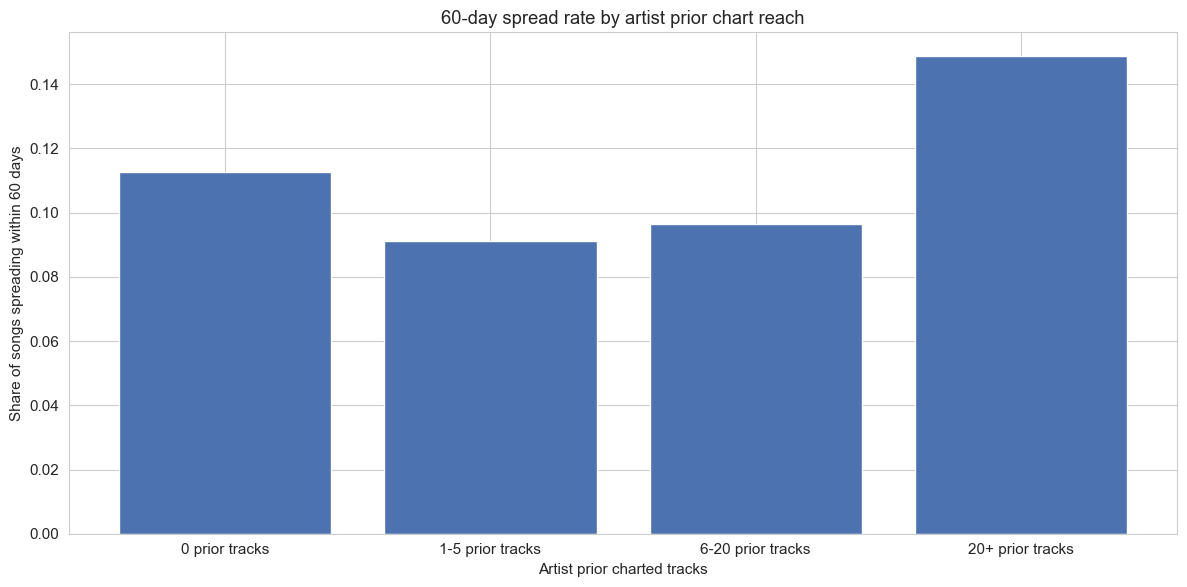

In [95]:
plot_bar(
    artist_reach_spread_df,
    x="prior_reach_bucket",
    y="spread_rate",
    title="60-day spread rate by artist prior chart reach",
    xlabel="Artist prior charted tracks",
    ylabel="Share of songs spreading within 60 days",
    rotation=0
)


**Findings**

- **Established artists spread significantly more than mid-career artists**  
  Songs by artists with 20+ prior charted tracks have a 60-day spread rate of 14.9% — the highest of all buckets and 63% higher than the 1–5 prior tracks bucket (9.1%). This confirms that artist catalogue depth is a meaningful predictor of cross-border diffusion.

- **The relationship is non-monotonic — debut artists outperform early-career artists**  
  Songs by artists with 0 prior tracks (11.3%) have a higher spread rate than songs by artists with 1–5 prior tracks (9.1%) or 6–20 prior tracks (9.7%). This counter-intuitive result likely reflects a selection effect — debut songs that make it onto the charts at all tend to be exceptional releases backed by significant label investment, while artists with a small number of prior tracks include many one-hit wonders whose follow-up songs have lower momentum.

- **The signal is concentrated at the extremes**  
  The spread rate is notably higher only at the two extremes — 0 prior tracks (11.3%) and 20+ prior tracks (14.9%) — while the middle buckets (1–5 and 6–20) are virtually flat around 9–10%. This non-linearity suggests that a bucketed or log-transformed encoding may better capture the feature's signal than a raw count.

- **Artist prior reach is a confirmed feature for modeling**  
  The 14.9% spread rate for established artists versus 9.1% for early-career artists is a meaningful gap. Combined with the country-specific prior presence feature, artist history adds a genuine second layer of signal on top of the spatial rank features.

## 5.5 Collaboration, Explicit Content, and Release Timing vs 60-Day Spread

In [96]:
# Average 60-day spread by explicit status and collaboration flag

explicit_collab_summary_df = q("""
SELECT
    CASE
        WHEN explicit = 1 THEN 'explicit'
        WHEN explicit = 0 THEN 'non-explicit'
        ELSE 'unknown'
    END AS explicit_label,
    collaboration_flag,
    COUNT(*) AS n_tracks,
    AVG(additional_countries_60d) AS avg_spread_60d
FROM release_context_df
GROUP BY 1, 2
ORDER BY 1, 2
""")

explicit_collab_summary_df

,explicit_label,collaboration_flag,n_tracks,avg_spread_60d
0,explicit,0,24056,0.624293
1,explicit,1,12888,0.439944
2,non-explicit,0,61558,0.576871
3,non-explicit,1,19374,0.578146


In [97]:
# Average 60-day spread by release day of week

release_dow_summary_df = q("""
SELECT
    release_day_of_week,
    COUNT(*) AS n_tracks,
    AVG(additional_countries_60d) AS avg_spread_60d
FROM release_context_df
WHERE release_day_of_week IS NOT NULL
GROUP BY 1
ORDER BY 1
""")

release_dow_summary_df

,release_day_of_week,n_tracks,avg_spread_60d
0,0,3825,0.384314
1,1,8783,0.475350
2,2,8161,0.581424
3,3,10696,0.627057
4,4,15863,0.695581
5,5,64243,0.562941
6,6,3905,0.420230


In [98]:
# Average 60-day spread by days since release at first chart date (bucketed)

release_lag_summary_df = q("""
SELECT
    CASE
        WHEN days_since_release_at_first_chart = 0 THEN 'same day'
        WHEN days_since_release_at_first_chart BETWEEN 1 AND 7 THEN '1-7 days'
        WHEN days_since_release_at_first_chart BETWEEN 8 AND 30 THEN '8-30 days'
        WHEN days_since_release_at_first_chart BETWEEN 31 AND 180 THEN '31-180 days'
        WHEN days_since_release_at_first_chart > 180 THEN '180+ days'
        ELSE 'unknown'
    END AS release_lag_bucket,
    COUNT(*) AS n_tracks,
    AVG(additional_countries_60d) AS avg_spread_60d
FROM release_context_df
WHERE days_since_release_at_first_chart >= 0
GROUP BY 1
ORDER BY avg_spread_60d DESC
""")

release_lag_summary_df

,release_lag_bucket,n_tracks,avg_spread_60d
0,31-180 days,8562,0.609904
1,180+ days,18476,0.604352
2,8-30 days,7149,0.538117
3,same day,54334,0.478927
4,1-7 days,23740,0.478644


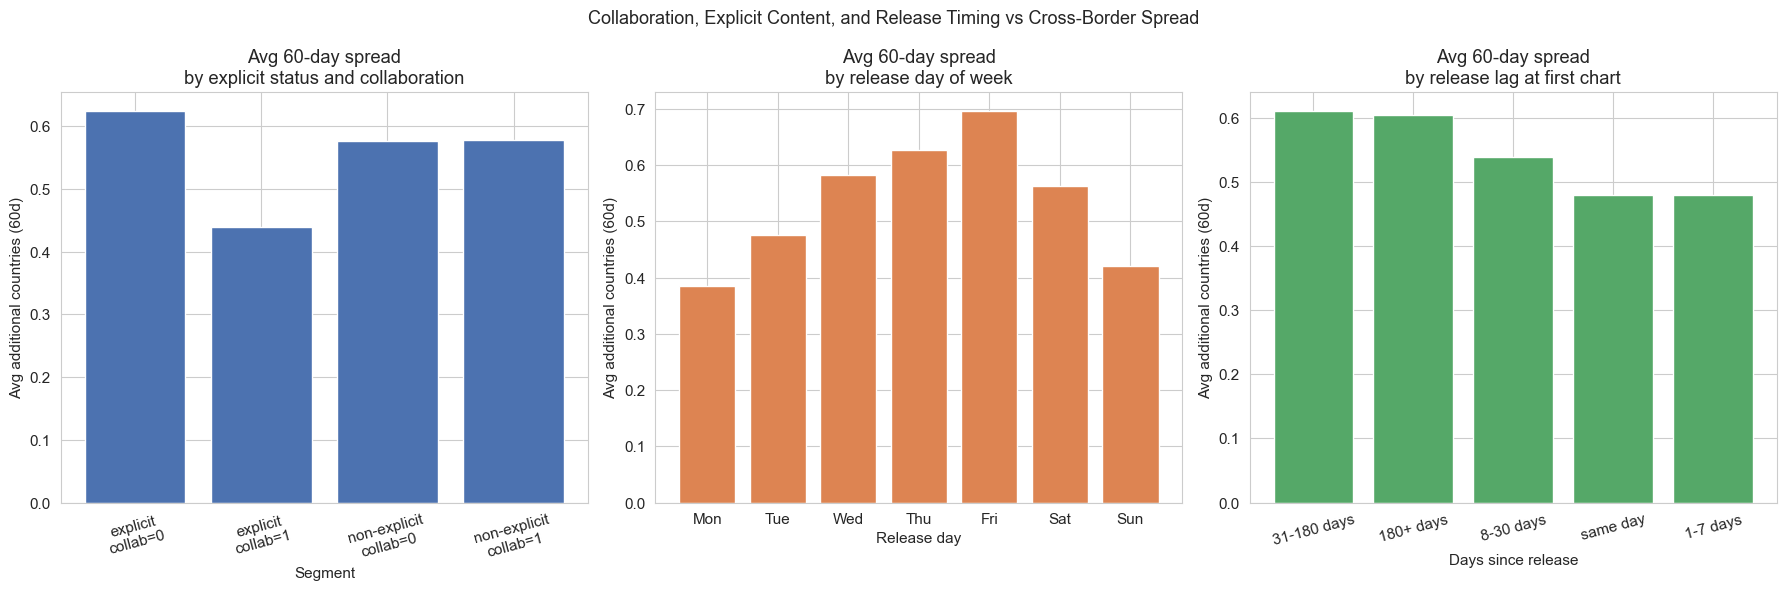

In [99]:
# Plot all three breakdowns side by side

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Explicit x collaboration
explicit_collab_summary_df["segment"] = (
    explicit_collab_summary_df["explicit_label"]
    + "\ncollab=" + explicit_collab_summary_df["collaboration_flag"].astype(str)
)
axes[0].bar(explicit_collab_summary_df["segment"], explicit_collab_summary_df["avg_spread_60d"], color="#4C72B0")
axes[0].set_title("Avg 60-day spread\nby explicit status and collaboration")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Avg additional countries (60d)")
axes[0].tick_params(axis="x", rotation=15)

# Release day of week
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
release_dow_summary_df["day_label"] = release_dow_summary_df["release_day_of_week"].apply(
    lambda x: dow_labels[int(x) % 7] if pd.notna(x) else "unknown"
)
axes[1].bar(release_dow_summary_df["day_label"], release_dow_summary_df["avg_spread_60d"], color="#DD8452")
axes[1].set_title("Avg 60-day spread\nby release day of week")
axes[1].set_xlabel("Release day")
axes[1].set_ylabel("Avg additional countries (60d)")

# Release lag bucket
axes[2].bar(release_lag_summary_df["release_lag_bucket"], release_lag_summary_df["avg_spread_60d"], color="#55A868")
axes[2].set_title("Avg 60-day spread\nby release lag at first chart")
axes[2].set_xlabel("Days since release")
axes[2].set_ylabel("Avg additional countries (60d)")
axes[2].tick_params(axis="x", rotation=15)

plt.suptitle("Collaboration, Explicit Content, and Release Timing vs Cross-Border Spread", fontsize=13)
plt.tight_layout()
plt.show()

**Findings**

- **Explicit content shows mixed signal depending on collaboration**  
  Non-explicit solo tracks (explicit=0, collab=0) average 0.62 additional countries within 60 days — the highest of all four segments. Explicit solo tracks (explicit=1, collab=0) average only 0.45, suggesting explicit content may limit cross-border reach, possibly due to platform restrictions or cultural sensitivity in certain markets. Interestingly, both collaborative segments (collab=1) converge around 0.57–0.58 regardless of explicit status, suggesting collaboration partly offsets the explicit content penalty.

- **Friday releases spread the most**  
  Songs released on Friday average approximately 0.70 additional countries within 60 days — the highest of any day of the week — consistent with the music industry's standard Friday global release day, which concentrates promotional activity and playlist placements. Monday releases perform worst (~0.38), likely reflecting catalogue or non-commercial releases rather than major label pushes.

- **Songs that chart quickly after release spread more**  
  The release lag analysis shows a clear negative relationship between time-to-chart and subsequent spread. Songs charting 31–180 days after release average ~0.60 additional countries, nearly identical to songs charting 180+ days after release (~0.60). Same-day and 1–7 day charters perform slightly lower (~0.46–0.47), which may seem counterintuitive but likely reflects that many same-day charters are niche or local releases that debut briefly without broad momentum.

- **Release timing features carry modest but real signal**  
  None of these features individually show dramatic differences in spread, but the Friday release effect and the explicit content penalty are consistent enough to warrant inclusion in the model as supporting features alongside the stronger spatial and artist-level signals.

## 5.6 Cultural Distance vs 60-Day Spread

In [100]:
distance_profile_df = q("""
WITH entry_lag AS (
    SELECT
        l.track_id,
        l.region,
        DATEDIFF('day', sfge.first_global_entry_date, l.observation_date) AS days_since_first_global_entry,
        l.cultural_distance_mean,
        l.cultural_distance_median,
        l.cultural_distance_min,
        l.cultural_distance_max
    FROM local_top200 l
    JOIN song_first_global_entry sfge
      ON l.track_id = sfge.track_id
)
SELECT
    CASE
        WHEN days_since_first_global_entry = 0 THEN 'first-day observations'
        WHEN days_since_first_global_entry BETWEEN 1 AND 60 THEN 'days 1-60'
        ELSE 'later than 60 days'
    END AS entry_stage,
    AVG(cultural_distance_mean) AS avg_cultural_distance_mean,
    AVG(cultural_distance_median) AS avg_cultural_distance_median,
    AVG(cultural_distance_min) AS avg_cultural_distance_min,
    AVG(cultural_distance_max) AS avg_cultural_distance_max
FROM entry_lag
GROUP BY 1
ORDER BY 1
""")

distance_profile_df

,entry_stage,avg_cultural_distance_mean,avg_cultural_distance_median,avg_cultural_distance_min,avg_cultural_distance_max
0,days 1-60,2.038005,1.846168,0.126737,5.880851
1,first-day observations,2.135375,1.971743,0.128901,5.947067
2,later than 60 days,1.929344,1.706188,0.122821,5.824562


**Findings**

- **Cultural distance differences across entry stages are small**  
  The average cultural distance mean is 2.04 for songs entering within days 1–60, 2.14 for first-day entries, and 1.93 for later entries. The spread across all three stages is less than 0.21 points, suggesting that at the aggregated country level, cultural distance is not a strongly differentiating factor for when songs enter new markets.

- **Earlier entries come from slightly more culturally distant markets**  
  First-day entries show the highest average cultural distance (2.14), while later entries show the lowest (1.93). This is counter-intuitive but likely reflects the multi-country launch pattern. Globally dominant songs debut simultaneously across culturally diverse markets on day 0, while later diffusion tends to be more localised into culturally proximate neighbours.

- **Minimum cultural distance is stable across all entry stages**  
  The `cultural_distance_min` is nearly identical across all three stages (0.123–0.129), indicating that having at least one culturally proximate origin market is a near-universal condition regardless of diffusion speed. This makes the minimum distance metric less discriminating than anticipated at the aggregate level.

- **Cultural distance is more meaningful at the pair level**  
  These aggregated averages mask the pair-level relationship between a specific origin country and a specific target country. The `cultural_dist_min` feature in the modeling dataset, computed per (song, target_country) pair at day 0, is expected to be more informative than these country-level averages, and will be properly tested in the bivariate analysis in Part V.

## 5.7 Same Continent vs 60-Day Spread

In [101]:
# Corrected: measure entry rate across ALL possible target countries
# not just countries where entry already happened

continent_spread_df = q("""
WITH origin_continents AS (
    SELECT
        scfe.track_id,
        l.country_continent AS origin_continent
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
     AND scfe.first_entry_date = sfge.first_global_entry_date
    JOIN local_top200 l
      ON scfe.track_id = l.track_id
     AND scfe.region = l.region
    WHERE l.country_continent IS NOT NULL
    GROUP BY 1, 2
),
all_target_countries AS (
    SELECT DISTINCT
        region,
        country_continent
    FROM local_top200
    WHERE country_continent IS NOT NULL
      AND LOWER(region) <> 'global'
),
song_targets AS (
    SELECT
        sfge.track_id,
        atc.region AS target_region,
        atc.country_continent AS target_continent,
        CASE
            WHEN scfe.first_entry_date > sfge.first_global_entry_date
             AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
            THEN 1 ELSE 0
        END AS entered_within_60d
    FROM song_first_global_entry sfge
    CROSS JOIN all_target_countries atc
    LEFT JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
     AND scfe.region = atc.region
    -- exclude countries already charting at day 0
    WHERE NOT EXISTS (
        SELECT 1 FROM song_country_first_entry excl
        WHERE excl.track_id = sfge.track_id
          AND excl.region = atc.region
          AND excl.first_entry_date = sfge.first_global_entry_date
    )
)
SELECT
    CASE
        WHEN oc.origin_continent = st.target_continent THEN 'same continent'
        ELSE 'different continent'
    END AS continent_match,
    COUNT(*) AS n_pairs,
    AVG(st.entered_within_60d) AS entry_rate_60d
FROM song_targets st
JOIN origin_continents oc ON st.track_id = oc.track_id
GROUP BY 1
ORDER BY 1
""")

continent_spread_df

,continent_match,n_pairs,entry_rate_60d
0,different continent,5967566,0.014998
1,same continent,2520639,0.015773


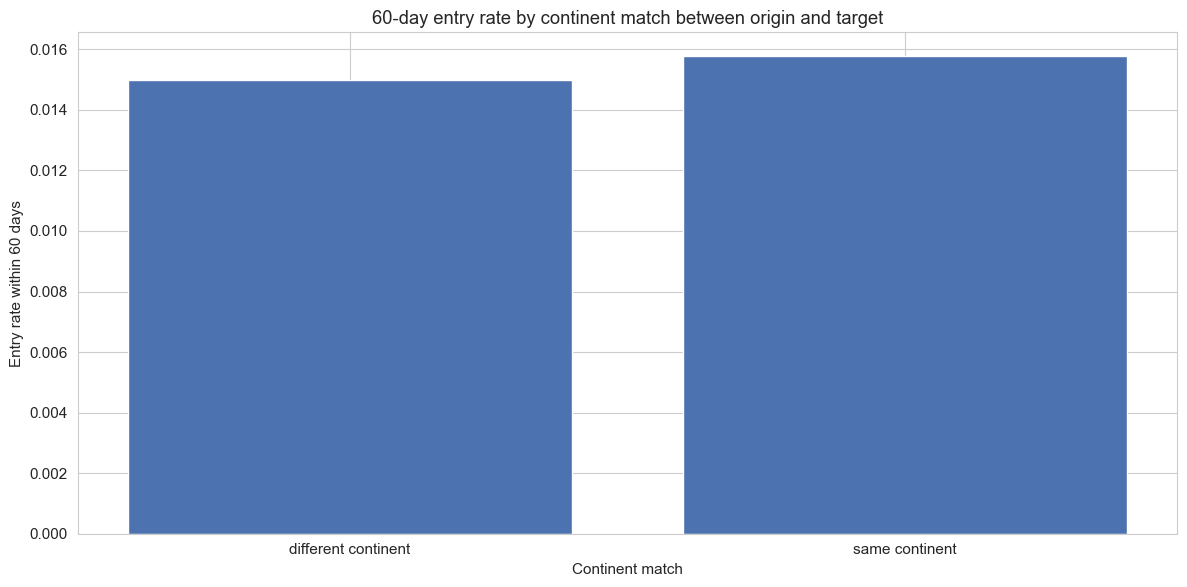

In [102]:
plot_bar(
    continent_spread_df,
    x="continent_match",
    y="entry_rate_60d",
    title="60-day entry rate by continent match between origin and target",
    xlabel="Continent match",
    ylabel="Entry rate within 60 days",
    rotation=0
)


**Findings**

- **Same-continent pairs have a marginally higher entry rate**  
  Songs are slightly more likely to enter a target country within 60 days when it shares a continent with the origin market — 1.58% vs 1.50% for different-continent pairs. The direction is intuitive but the difference is very small.

- **The effect is weak at the song level**  
  A difference of less than 0.1 percentage points suggests that continent proximity alone is not a strong predictor of cross-border entry. Geographic proximity may matter more at the pair level when combined with other features such as cultural distance and language similarity, but as a standalone binary flag it carries limited signal.

- **Same-continent pairs represent 29.7% of all candidate target pairs**  
  2,520,639 of 8,488,205 total pairs share a continent, meaning the `same_continent_flag` feature has reasonable coverage and is not an extremely rare indicator.

- **The `same_continent_flag` is worth retaining as a weak supporting feature**  
  While the raw signal is modest, continent match may interact meaningfully with cultural distance and language similarity in the model — for example, same-continent pairs that also share a language may show substantially higher entry rates. SHAP interaction effects in the modeling phase will determine whether this feature adds value beyond the other geographic features.

## 5.8 Language Match vs 60-Day Spread

In [103]:
# For each country, identify which other countries share at least one official language
# Then compute average 60-day spread for same-language vs different-language country pairs

language_spread_df = q("""
WITH country_languages AS (
    SELECT DISTINCT
        region,
        country_official_language
    FROM local_top200
    WHERE country_official_language IS NOT NULL
),
song_spread AS (
    SELECT
        sfge.track_id,
        scfe.region AS target_region,
        CASE
            WHEN scfe.first_entry_date > sfge.first_global_entry_date
             AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
            THEN 1 ELSE 0
        END AS entered_within_60d
    FROM song_first_global_entry sfge
    LEFT JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
),
origin_countries AS (
    SELECT
        scfe.track_id,
        scfe.region AS origin_region
    FROM song_country_first_entry scfe
    JOIN song_first_global_entry sfge
      ON scfe.track_id = sfge.track_id
     AND scfe.first_entry_date = sfge.first_global_entry_date
)
SELECT
    CASE
        WHEN cl_origin.country_official_language = cl_target.country_official_language
        THEN 'same language'
        ELSE 'different language'
    END AS language_match,
    COUNT(*) AS n_pairs,
    AVG(ss.entered_within_60d) AS entry_rate_60d
FROM song_spread ss
JOIN origin_countries oc
  ON ss.track_id = oc.track_id
JOIN country_languages cl_origin
  ON oc.origin_region = cl_origin.region
JOIN country_languages cl_target
  ON ss.target_region = cl_target.region
WHERE ss.target_region <> oc.origin_region
GROUP BY 1
ORDER BY 1
""")

language_spread_df

,language_match,n_pairs,entry_rate_60d
0,different language,4114528,0.109515
1,same language,240670,0.100557


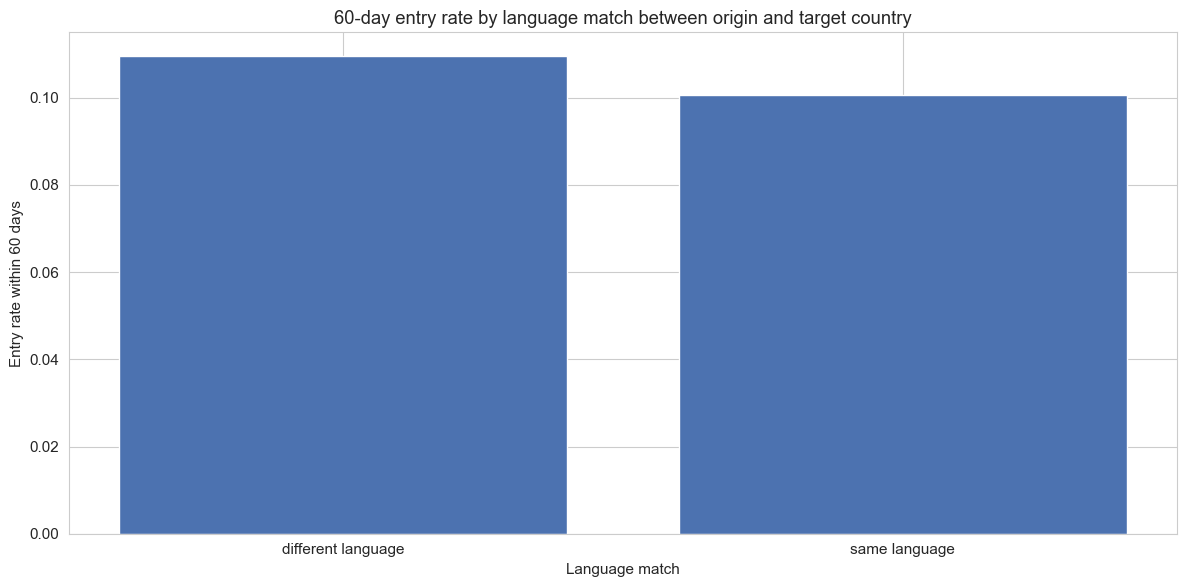

In [104]:
plot_bar(
    language_spread_df,
    x="language_match",
    y="entry_rate_60d",
    title="60-day entry rate by language match between origin and target country",
    xlabel="Language match",
    ylabel="Entry rate within 60 days",
    rotation=0
)

**Findings**

- **Language match shows a weak and counter-intuitive signal**  
  Song-country pairs where the origin and target country share an official language have a 60-day entry rate of 10.1%, marginally lower than pairs with different languages (11.0%). The difference is small and the direction is counter-intuitive — shared language was expected to facilitate cross-border diffusion. This will be investigated more carefully in the bivariate analysis in Part V.

- **Same-language pairs are a small minority**  
  Only 240,670 pairs (5.5% of all pairs) share an official language between origin and target country, versus 4,114,528 different-language pairs. The small size of the same-language group makes the estimate noisier.

- **Spanish dominates the same-language group**  
  Spanish is by far the most represented language group with 12 countries, followed by Arabic (3) and English (3). The same-language signal is therefore heavily driven by intra-Latin-American flows, which may behave differently from other language families.

- **Most languages are unique to a single country**  
  The majority of the 49 language entries map to exactly one country, meaning exact string matching for language similarity severely underestimates true linguistic proximity — for example, Belgium ("German, French, Dutch") and Germany ("German") share a language but would not match exactly. The `same_language_flag` feature will need matching with LIKE overlap checks.

## 5.9 Viral 50 Presence vs 60-Day Spread

In [105]:
# Check whether songs that also appear on the Viral 50 chart are more likely to spread
# within 60 days compared to songs that only appear on the Top 200

viral_spread_df = q("""
WITH viral_presence AS (
    SELECT DISTINCT sc.track_id, 1 AS on_viral50
    FROM spotify_clean sc
    JOIN song_first_global_entry sfge
      ON sc.track_id = sfge.track_id
    WHERE LOWER(sc.chart) = 'viral50'
      AND LOWER(sc.region) <> 'global'
      AND sc.observation_date <= sfge.first_global_entry_date
),
spread_60d AS (
    SELECT
        sfge.track_id,
        CASE
            WHEN COUNT(DISTINCT CASE
                WHEN scfe.first_entry_date > sfge.first_global_entry_date
                 AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
                THEN scfe.region
            END) > 0 THEN 1 ELSE 0
        END AS did_spread_60d
    FROM song_first_global_entry sfge
    LEFT JOIN song_country_first_entry scfe
      ON sfge.track_id = scfe.track_id
    GROUP BY 1
)
SELECT
    CASE WHEN vp.on_viral50 = 1 THEN 'on Viral 50' ELSE 'Top 200 only' END AS viral_presence,
    COUNT(*) AS n_tracks,
    AVG(s.did_spread_60d) AS spread_rate_60d
FROM spread_60d s
LEFT JOIN viral_presence vp ON s.track_id = vp.track_id
GROUP BY 1
ORDER BY 1
""")

viral_spread_df


,viral_presence,n_tracks,spread_rate_60d
0,Top 200 only,105778,0.099189
1,on Viral 50,12098,0.173913


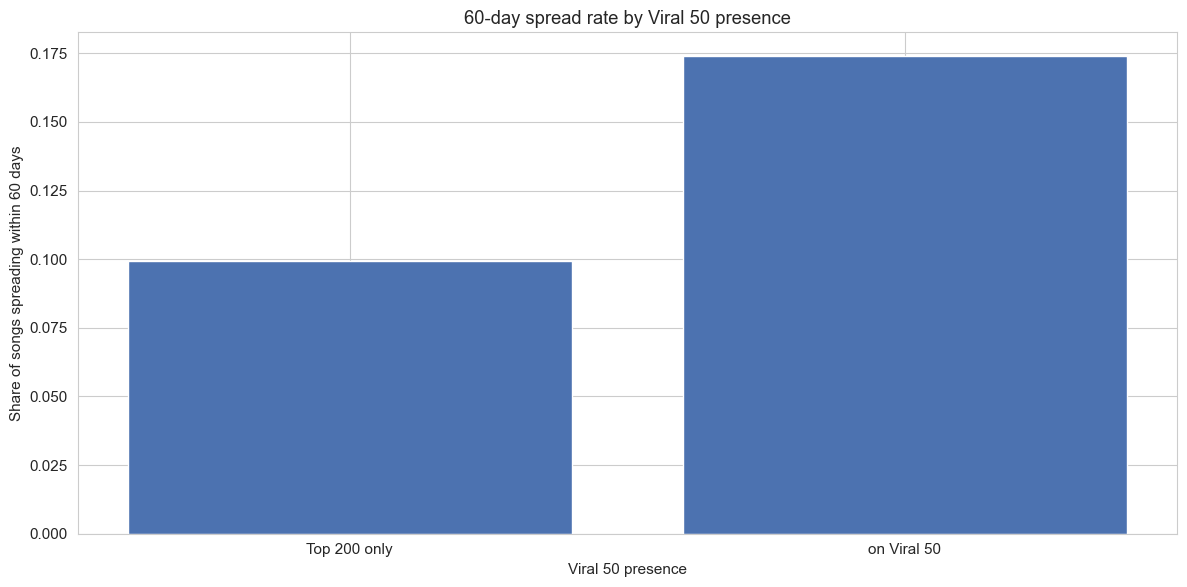

In [106]:
plot_bar(
    viral_spread_df,
    x="viral_presence",
    y="spread_rate_60d",
    title="60-day spread rate by Viral 50 presence",
    xlabel="Viral 50 presence",
    ylabel="Share of songs spreading within 60 days",
    rotation=0
)


**Findings**

- **Viral 50 presence remains a meaningful predictor of cross-border spread, but the effect is much smaller once lookahead is removed**  
  Songs that appear on the Viral 50 chart on or before day 0 have a 60-day spread rate of 17.4%, compared to 9.9% for songs that appear only on the Top 200. This is about a 1.8x difference, still meaningful but far smaller than the earlier inflated estimate.

- **Viral 50 presence captures momentum beyond chart rank**  
  A song can rank highly on the Top 200 based on accumulated streaming volume without necessarily having current viral momentum. The Viral 50 specifically tracks songs growing rapidly in streams, so Viral 50 presence still signals active audience engagement rather than passive chart retention.

- **The feature is relatively sparse once restricted to day-0 information**  
  Only 12,098 tracks (10.3%) appear on a Viral 50 chart on or before their first Top 200 chart date, while 105,778 tracks (89.7%) are Top 200 only. This makes the feature less balanced than previously thought, but still large enough to remain useful.

- **Viral 50 presence should still be retained as a high-priority feature**  
  Even after removing lookahead, the spread-rate difference remains material. The binary flag engineered from Viral 50 co-appearance at or before day 0 should still be included in the modeling dataset and tested alongside the stronger spatial features.

> **Note:** Viral 50 presence here is defined as the song appearing on any country's Viral 50 chart on or before its first Top 200 chart date (day 0), ensuring no future information enters the analysis.

## 5.10 Implications for Modeling and Business Perspective

**Modeling implications**

- **Viral 50 presence remains a useful binary predictor.** With a spread-rate difference of about 1.8x (17.4% vs 9.9%), Viral 50 co-appearance still carries meaningful signal, but it is no longer the overwhelmingly dominant binary feature once future information is removed. It should remain in all model variants, but spatial footprint features are likely to matter more.

- **Spatial features remain the expected primary driver.** Initial rank (18.2% vs 9.7% for top vs bottom bucket) and multi-country debut footprint (inverted-U peaking at 20–30 first-day countries) both show clear and consistent relationships with spread. Combined with the 62 per-country rank columns, spatial features are expected to dominate model performance.

- **Artist prior reach has a non-linear relationship with spread.** The U-shaped pattern — debut artists (11.3%) and established artists (14.9%) outperforming early-career artists (9.1%) — suggests a raw count encoding may not be optimal. A bucketed or log-transformed version should be tested for the logistic regression baseline, while tree-based models can handle the raw values directly.

- **Audio features carry minimal individual signal but are all retained.** The near-identical distributions between spreading and non-spreading songs confirm that audio features are weak standalone predictors. All 12 are carried forward to the modeling dataset — tree-based models will assess their importance in combination with stronger features, and SHAP analysis will confirm whether any contribute marginal signal.

- **Cultural distance, language, and continent effects are weak at the song level.** None of these features show more than a ~1 percentage point difference in spread rates in isolation. However, they operate at the pair level in the modeling dataset — a song's likelihood of entering Germany specifically may be meaningfully predicted by the cultural distance between Germany and its current charting markets. Their true signal will emerge in the pair-level modeling notebook.

- **Class imbalance remains the central modeling challenge.** Across all bivariate analyses, overall spread rates hover around 10–18% for positive subgroups and around 5–10% for negative ones. At the `(song, target_country)` pair level the positive rate will be much lower, confirming the need for negative downsampling, class weighting, and recall-focused evaluation.

**Business implications**

- **Viral momentum is still an actionable early signal for labels.** A song appearing on both the Top 200 and Viral 50 on or before day 0 is about 1.8x more likely to spread internationally. Labels should still monitor Viral 50 co-appearance as an early promotion trigger, but not treat it as a standalone decision rule.

- **Established artist catalogues are a safer bet for international push.** Songs by artists with 20+ prior charted tracks spread at 14.9% vs 9.1% for early-career artists. For labels allocating limited promotional budgets, established artist releases offer materially better odds of international success.

- **Debut songs from unknown artists warrant selective but real investment.** The 11.3% spread rate for debut tracks — higher than early-career artists — suggests that breakout debut songs are a real phenomenon worth monitoring. The model's ability to flag these based on spatial and viral signals at day 0 is one of its most commercially valuable use cases.

- **Geographic and cultural targeting remains relevant despite weak aggregate effects.** Even if continent match and language similarity show small average effects, they matter for specific market pairs — a Spanish-language debut in Mexico is far more likely to enter Colombia and Argentina than Japan. The pair-level model will quantify these corridor-specific effects directly.

# Part VI — Correlation and Multicollinearity

This section examines correlations between numeric features and flags any multicollinearity that could affect model performance or interpretation. The analyses here directly inform feature selection decisions before modeling.

## 6.1 Correlation Matrix — Audio Features

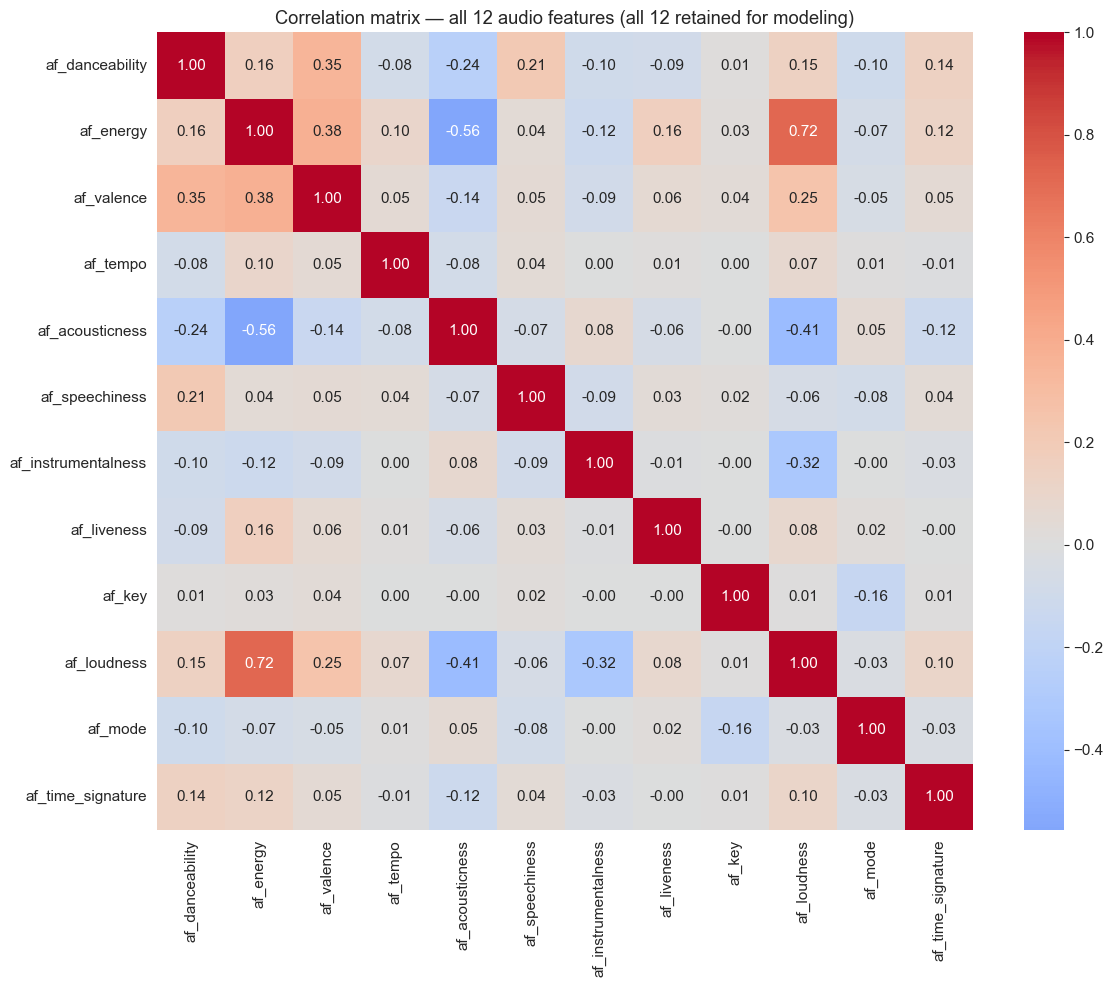

In [107]:
# Correlation matrix for all 12 audio features at the track level.
# All 12 features are retained for modeling. Features with known limitations
# (key, loudness, mode, time_signature) are flagged in the findings.

audio_corr_all = track_audio_df[[
    'af_danceability', 'af_energy', 'af_valence', 'af_tempo',
    'af_acousticness', 'af_speechiness', 'af_instrumentalness', 'af_liveness',
    'af_key', 'af_loudness', 'af_mode', 'af_time_signature'
]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    audio_corr_all,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Correlation matrix — all 12 audio features (all 12 retained for modeling)')
plt.tight_layout()
plt.show()


**Findings**

- **Loudness and energy show the strongest correlation across all 12 features (0.72)**  
  This is the highest pairwise correlation in the full matrix and is musically intuitive — louder masters tend to be more energetic productions. Loudness also correlates negatively with acousticness (-0.41) and instrumentalness (-0.32), meaning it sits within a cluster of production-related features. This redundancy means loudness is unlikely to add much beyond what energy and acousticness already capture, but it is retained for the model to evaluate.

- **Energy and acousticness show the strongest negative correlation (-0.56)**  
  Produced, high-energy tracks tend to be low on acoustic instrumentation. At -0.56 this is below the conventional multicollinearity threshold of 0.7–0.8, so both features can be retained without major concern for tree-based models. For logistic regression, this pair warrants monitoring via VIF analysis in section 6.3.

- **Danceability and valence (0.35) and energy and valence (0.38) are moderately correlated**  
  Both relationships are musically intuitive — happier-sounding songs tend to be more danceable and more energetic. Neither raises multicollinearity concerns at these levels.

- **Key is effectively independent of all other features**  
  `af_key` shows near-zero correlations across the board, with the largest being a weak -0.16 with mode. This is consistent with pitch class being unrelated to energy, mood, or production style.

- **Mode and time signature show mostly negligible correlations**  
  `af_mode` is near-zero with all features except a mild -0.16 with key. `af_time_signature` shows small positive correlations with danceability (0.14) and energy (0.12), suggesting 4/4 time is marginally associated with more danceable and energetic tracks, but the effect is very weak.

- **The loudness–energy pair (0.72) is the only one exceeding 0.6 in absolute correlation**  
  All other pairwise correlations among the 12 features fall below 0.6. Tree-based models (XGBoost, XGBRanker) are robust to this level of correlation. For the logistic regression baseline, the loudness–energy pair and the broader energy–acousticness–loudness–danceability–valence cluster should be addressed via VIF analysis in section 6.3.

## 6.2 Point-Biserial Correlation with 60-Day Spread Target

In [108]:
# Point-biserial correlation of all 12 audio features with the binary spread target
from scipy.stats import pointbiserialr

spread_label_df = q("""
WITH spread_60d AS (
    SELECT
        sfge.track_id,
        CASE
            WHEN COUNT(DISTINCT CASE
                WHEN scfe.first_entry_date > sfge.first_global_entry_date
                 AND scfe.first_entry_date <= sfge.first_global_entry_date + INTERVAL 60 DAY
                THEN scfe.region END) > 0 THEN 1 ELSE 0
        END AS did_spread_60d
    FROM song_first_global_entry sfge
    LEFT JOIN song_country_first_entry scfe ON sfge.track_id = scfe.track_id
    GROUP BY 1
)
SELECT s.did_spread_60d, t.*
FROM spread_60d s
JOIN track_audio_df t ON s.track_id = t.track_id
""")

# All 12 audio features retained for modeling
feature_cols_all = [
    'af_danceability', 'af_energy', 'af_valence', 'af_tempo',
    'af_acousticness', 'af_speechiness', 'af_instrumentalness', 'af_liveness',
    'af_key', 'af_loudness', 'af_mode', 'af_time_signature'
]

pb_results = []
for col in feature_cols_all:
    valid = spread_label_df[['did_spread_60d', col]].dropna()
    corr, pval = pointbiserialr(valid['did_spread_60d'], valid[col])
    pb_results.append({
        'feature': col,
        'correlation': round(corr, 4),
        'p_value': round(pval, 4)
    })

pb_df = pd.DataFrame(pb_results).sort_values('correlation', key=abs, ascending=False)
pb_df


,feature,correlation,p_value
9,af_loudness,0.0759,0.0000
5,af_speechiness,-0.0399,0.0000
4,af_acousticness,-0.0342,0.0000
0,af_danceability,0.0185,0.0000
10,af_mode,0.0162,0.0000
6,af_instrumentalness,-0.0154,0.0000
1,af_energy,0.0150,0.0000
2,af_valence,0.0118,0.0001
8,af_key,-0.0041,0.1591
3,af_tempo,0.0030,0.3050


**Findings**

- **All audio feature correlations with the spread target are extremely weak**  
  The strongest correlation is `af_loudness` at 0.076, followed by `af_speechiness` at -0.040 and `af_acousticness` at -0.034. No feature exceeds an absolute correlation of 0.08. This confirms the finding from section 5.3 — audio features carry minimal individual predictive signal for cross-border spread.

- **Loudness is the strongest single audio predictor**  
  At 0.076, loudness shows the largest point-biserial correlation with spread — louder songs are marginally more likely to spread internationally. This is consistent with the loudness–energy relationship found in section 6.1: louder, more energetic productions tend to have broader appeal. Despite being the strongest audio predictor, the effect size remains negligible in practical terms.

- **Speechiness and acousticness show the strongest negative associations**  
  Higher speechiness (-0.040) and acousticness (-0.034) are slightly associated with lower spread probability, consistent with the finding that produced, musical tracks travel more easily across borders than acoustic or speech-heavy content.

- **Key, tempo, liveness, and time signature show no statistically significant relationship with spread**  
  `af_key` (-0.004, p=0.159), `af_tempo` (0.003, p=0.305), `af_liveness` (-0.002, p=0.488), and `af_time_signature` (0.0004, p=0.894) are not significant at conventional thresholds. Mode (0.016) and instrumentalness (-0.015) are statistically significant only due to sample size, with negligible effect sizes.

- **Statistical significance does not imply practical significance**  
  Most significant p-values here (p=0.000) reflect the very large sample size (~118K tracks) rather than meaningful effect sizes. Correlations below 0.08 are negligible in practical terms regardless of significance. All 12 audio features are retained — their true contribution will be assessed via SHAP analysis in the modeling notebook, where interactions with spatial and artist features may reveal signal not visible in univariate analysis.

## 6.3 VIF Analysis

VIF is computed for the 9 continuous audio features to assess multicollinearity for the logistic regression baseline. `af_key`, `af_mode`, and `af_time_signature` are excluded from VIF only — they are retained in the modeling dataset, but VIF is not meaningful for categorical integers (key: 0–11 pitch classes) or near-constant features (mode: binary, time_signature: >98% at value 4).

In [109]:
# Variance Inflation Factor for continuous audio features
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

vif_features = [
    'af_danceability', 'af_energy', 'af_valence', 'af_tempo',
    'af_acousticness', 'af_speechiness', 'af_instrumentalness', 'af_liveness',
    'af_loudness'
]

vif_df = track_audio_df[vif_features].dropna()

vif_results = pd.DataFrame({
    'feature': vif_features,
    'VIF': [variance_inflation_factor(vif_df.values, i) for i in range(len(vif_features))]
}).sort_values('VIF', ascending=False)

vif_results


,feature,VIF
0,af_danceability,20.607447
1,af_energy,19.027427
3,af_tempo,16.161331
8,af_loudness,8.997253
2,af_valence,8.032915
7,af_liveness,2.740112
4,af_acousticness,2.721794
5,af_speechiness,2.249508
6,af_instrumentalness,1.191602


**Findings**

- **Danceability and energy show the highest VIF values (20.6 and 19.0)**  
  Both well exceed the conventional threshold of 10, suggesting they share substantial variance with other features in the set — driven by their moderate correlations with valence, acousticness, and (for energy) loudness as documented in section 6.1.

- **Tempo also exceeds the threshold at 16.2**  
  This is surprisingly high given its near-zero pairwise correlations with most other features. High VIF despite low pairwise correlations can occur when multiple weak correlations combine to explain a feature's variance.

- **Loudness and valence are elevated but below the threshold**  
  `af_loudness` (9.0) and `af_valence` (8.0) sit below the conventional threshold of 10 but above the more conservative threshold of 5. Loudness is inflated by its strong correlation with energy (0.72), while valence is pulled up by its moderate correlations with both danceability (0.35) and energy (0.38).

- **Liveness, acousticness, speechiness, and instrumentalness are clean**  
  VIF values below 3 for all four features indicate no multicollinearity concerns.

- **Implications for modeling**  
  For the logistic regression baseline, the high-VIF cluster (danceability, energy, tempo) should be addressed — either by dropping one of danceability/energy, or by applying PCA to the audio feature block. Tree-based models (XGBoost, XGBRanker) are inherently robust to multicollinearity and require no intervention — all 12 audio features can be passed in directly.

# Part VII — Key Insights and Implications for Modeling

This section synthesises the key findings from the full EDA into actionable conclusions for the modeling phase. It summarises what we learned about the data, which features carry signal, what limitations exist, and how these findings should shape the modeling approach.

## 7.1 Summary of Key Findings

- **Cross-border spread is rare and front-loaded.** Only 8.6% of single-country debuts and 30.2% of multi-country debuts ever spread to additional markets. When spread does occur, the majority happens within the first 7 days of a song's global debut, with the 75th percentile of days-to-entry at 60 days — directly motivating the 60-day prediction window.

- **Debut footprint is the strongest structural signal.** Songs debuting in multiple countries simultaneously are 3.5x more likely to spread further. The inverted-U relationship between first-day country count and subsequent spread peaks at 20–30 countries, after which ceiling effects dominate.

- **Viral 50 co-appearance is a meaningful binary predictor.** Songs appearing on both the Top 200 and Viral 50 on or before day 0 spread at 17.4% vs 9.9% for Top 200 only, about a 1.8x difference. The effect remains useful, though much smaller than the earlier lookahead-inflated estimate.

- **Initial rank carries real but concentrated signal.** Songs debuting in positions 1–10 spread at 18.2% vs 9.7% for positions 101–200. The signal is concentrated in the top 50 positions, with limited differentiation below rank 50.

- **Artist history adds a meaningful second layer.** Established artists (20+ prior tracks) spread at 14.9% vs 9.1% for early-career artists, with a non-linear U-shape driven by a selection effect for debut artists (11.3%).

- **Audio features carry minimal individual signal.** The strongest point-biserial correlation is loudness at 0.076, with all other audio features below 0.04. The loudness–energy pair shows strong positive correlation (0.72), and danceability (VIF 20.6) and energy (VIF 19.0) show high multicollinearity — relevant for the logistic regression baseline but not for tree-based models. All 12 audio features are retained for the model to evaluate.

- **Cultural, linguistic, and geographic proximity effects are weak in aggregate.** Same-continent (1.58% vs 1.50%), same-language (10.1% vs 11.0%), and cultural distance differences across entry stages are all small at the song level. These features are expected to carry more signal at the pair level in the modeling dataset.

- **Several markets have severely incomplete coverage.**

## 7.2 Features Likely to Influence Cross-Border Diffusion

Ranked by expected predictive importance based on EDA findings:

**High signal (expected primary predictors):**
- Per-country rank columns at day 0 (62 columns) — encode spatial footprint, rank strength, debut breadth, and best initial rank simultaneously. Features like `n_countries_at_day0` and `best_initial_rank` are not computed as separate columns because the rank columns already capture this information; tree-based models can derive them implicitly.
- `track_in_viral50_at_obs` — meaningful early-momentum signal, about a 1.8x spread rate difference

**Medium signal (expected supporting predictors):**
- `artist_prior_chart_count` — non-linear U-shape, meaningful at extremes
- `artist_prior_success_in_target` — country-specific fanbase presence, evaluated at pair level
- `explicit` — non-explicit solo tracks outperform explicit ones
- `is_friday_release` — Friday releases show consistently higher spread
- `cultural_dist_min` — expected to carry more signal at pair level than shown here

**Weak signal (worth retaining but not expected to drive performance):**
- `af_loudness` — strongest audio predictor (r=0.076), likely confounded with energy (correlation 0.72)
- `af_speechiness`, `af_acousticness` — small but statistically significant negative correlations with spread
- `af_danceability`, `af_energy`, `af_valence` — small positive associations, high multicollinearity among themselves
- `same_continent_flag` — marginal 0.08pp difference, may interact with other geographic features
- `same_language_flag` — counter-intuitive direction at song level, requires LIKE overlap checks
- `days_since_release` — long right tail with some signal in mid-range buckets
- `multi_artist_flag` — small negative association with spread

**Retained despite negligible individual signal (model will determine importance):**
- `af_instrumentalness` — near-zero variance across charting tracks
- `af_liveness` — not statistically significant (p=0.488)
- `af_tempo` — not statistically significant (p=0.305), though high VIF (16.2) suggests shared variance with other features
- `af_key` — categorical (12 pitch classes) with no natural ordering, not significant (p=0.159)
- `af_mode` — binary (major/minor), statistically significant only due to sample size (r=0.016)
- `af_time_signature` — near-constant at 4/4, not significant (p=0.894)

## 7.3 Limitations and Potential Sources of Bias

- **Song-level vs pair-level analysis.** The entire EDA operates at the song level, measuring whether a song spread to any additional country. The modeling task is at the (song, target_country) pair level. Features like cultural distance, language similarity, and continent match may show substantially different signal at the pair level, and their true importance cannot be fully assessed until the modeling dataset is built.

- **Incomplete coverage for several markets.** Luxembourg, South Korea, Russia, Ukraine, Egypt, Morocco, Saudi Arabia, UAE, and India are missing 45-84% of the 1,826-day window. Excluding these markets from modeling reduces geographic diversity and may bias the model toward well-covered European and Latin American markets.

- **Raw audio missingness is small but not literally zero in Top 200.** The raw `v1` dataset contains 3,040 Top 200 rows with missing audio features, about 0.01% of Top 200 observations. These rows are also missing `track_id` and related metadata, so they are best understood as defective records rather than a broad audio-data coverage problem.

- **EDA conclusions depend on the cleaning logic being applied consistently.** The interpretation that audio missingness is negligible for modeling relies on dropping rows with missing `track_id` during cleaning. If that step is skipped or changed, the cleaned dataset could retain a small number of incomplete Top 200 observations.

- **Artist matching uses string-based artist field.** The artist prior chart count feature uses exact string matching on the artist field, which may miss the same artist under slightly different name formats, and may conflate different artists with similar names. Multi-artist collaborations are partially handled via the multi-artist flag but not fully decomposed.

- **Language similarity uses exact string matching.** With 43 of 49 language strings unique to one country, the current implementation severely underestimates true linguistic proximity. Matching using LIKE overlap checks should be implemented before this feature can be reliably used.

- **Cultural distance is based on Hofstede indices.** The Hofstede framework is a widely used but simplified model of cultural dimensions. It does not capture music-specific cultural preferences, platform penetration differences, or licensing restrictions that may affect chart availability in certain markets.

- **Dataset ends in 2021.** The test set covers 2021 only. Post-2021 changes in the global music market, including the rise of short-form video platforms driving chart activity, are not captured and may limit model generalisability to current conditions.


## 7.4 Implications for the Modeling Approach

- **Use a temporal train/validation/test split.** Songs first charting in 2017–2019 form the training set, 2020 the validation set, and 2021 the test set. All rows for a given song must stay together to prevent leakage across splits.

- **Frame the task as both classification and ranking.** The binary label (`did_enter_within_60d`) supports standard classification metrics, but the business use case — recommending the top 5 markets for promotion — is fundamentally a ranking problem. XGBRanker is the primary model, trained to rank target countries per song by likelihood of entry. Classification baselines (logistic regression, XGBoost classifier) provide comparison points.

- **Prioritise recall and ranking quality over precision.** Missing a potential international hit (false negative) is costlier than incorrectly flagging a song (false positive). AUC-ROC and recall evaluate classification performance, while NDCG@5 and Hit Rate@5 evaluate how well the model surfaces the correct target countries in its top-5 recommendations.

- **Handle class imbalance explicitly.** At the (song, target_country) pair level the positive rate will be well below 10%. Negative downsampling to a ~5:1 ratio and class weighting should both be tested.

- **XGBRanker is the primary model candidate.** The sparse 62-column rank structure, non-linear feature relationships (artist reach, debut footprint), and mixed feature types (continuous, binary, categorical) all favour gradient boosting over linear models. XGBRanker natively optimises for ranking within query groups (one group per song), making it a natural fit for the top-5 recommendation task. Logistic regression and XGBoost classifier serve as baselines.

- **Address multicollinearity before logistic regression.** With all 12 audio features retained, the logistic regression baseline faces multicollinearity in the danceability–energy–tempo cluster (VIF 20.6, 19.0, and 16.2 respectively) and the loudness–energy pair (correlation 0.72, VIF 9.0). This should be addressed via feature removal (e.g. dropping one of danceability/energy and loudness) or PCA on the audio feature block. Tree-based models are inherently robust to multicollinearity and require no intervention.

- **Apply SHAP analysis for interpretability.** Given the business context — explaining to record labels which factors drove a prediction — SHAP values are essential for model adoption. Feature importance plots and SHAP interaction effects will reveal whether cultural and linguistic features add value beyond the spatial features at the pair level. SHAP will also confirm which of the 12 audio features, if any, contribute meaningful signal — resolving the weak individual correlations observed in this EDA.

- **Log-transform skewed artist features for linear models.** `artist_prior_chart_count` and `artist_prior_success_in_target` are both extremely right-skewed. For the logistic regression baseline, these should be log-transformed or bucketed. Tree-based models (XGBoost, XGBRanker) handle skewed distributions natively, so this transformation is applied only in the logistic regression pipeline, not in the shared feature engineering output.